# Arunachal Pradesh: Growth, Inflation & Fiscal Health
**Financial Programming - Projects 1 & 2**

---

## Step 1 - Load All Packages

In [1]:
suppressPackageStartupMessages({
  library(readxl)
  library(strucchange)
  library(tempdisagg)
  library(sandwich)
  library(lmtest)
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(zoo)
  library(scales)
  library(gridExtra)
})

BASE_DIR <- "c:/Users/user/Downloads/Python Env For Data Analysis/Financial Programming Project"
DATA_DIR <- file.path(BASE_DIR, "Data")
FIG_DIR  <- file.path(BASE_DIR, "figures")
TBL_DIR  <- file.path(BASE_DIR, "tables")
dir.create(FIG_DIR, showWarnings = FALSE, recursive = TRUE)
dir.create(TBL_DIR, showWarnings = FALSE, recursive = TRUE)

options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 150)

RESULTS <- list()

cat(sprintf("R version: %s\n", R.version.string))
cat(sprintf("strucchange: %s\n", packageVersion("strucchange")))
cat(sprintf("tempdisagg: %s\n", packageVersion("tempdisagg")))
cat(sprintf("ggplot2: %s\n", packageVersion("ggplot2")))

R version: R version 4.5.3 (2026-03-11 ucrt)


strucchange: 1.5.4


tempdisagg: 1.2.0


ggplot2: 4.0.2


### Helper Functions

In [2]:
month_to_num <- function(m) {
  if (is.numeric(m) || is.integer(m)) return(as.integer(m))
  mm <- c(January=1,February=2,March=3,April=4,May=5,June=6,
          July=7,August=8,September=9,October=10,November=11,December=12)
  as.integer(mm[trimws(as.character(m))])
}

assign_fy_quarter <- function(year, month) {
  if (is.na(year) || is.na(month)) return(c(NA_integer_, NA_integer_))
  year <- as.integer(year); month <- as.integer(month)
  if (month >= 4) {
    fy <- year
    q <- if (month <= 6) 1L else if (month <= 9) 2L else 3L
  } else {
    fy <- year - 1L; q <- 4L
  }
  c(fy, q)
}

fy_label <- function(fy) paste0(fy, "-", substr(as.character(fy+1), 3, 4))

# Best available value: Account > Revised > Budget
best_value <- function(acct, rev, bud) {
  ifelse(!is.na(acct), acct, ifelse(!is.na(rev), rev, bud))
}

## Step 2 - Load AR GSDP Constant Prices

In [3]:
gsdp_const_raw <- read_excel(file.path(DATA_DIR, "2011-12 Back Series - GSDP (Constant Prices) Arunachal Pradesh.xlsx"), skip=2)
gsdp_const <- gsdp_const_raw[grepl("^\\d{4}-\\d{4}$", gsdp_const_raw[[1]]), ]

cat(sprintf("Rows: %d | Cols: %d\n", nrow(gsdp_const), ncol(gsdp_const)))
cat("Column names:\n"); print(names(gsdp_const)[1:10])
cat(sprintf("First year: %s | Last year: %s\n", gsdp_const[[1]][1], gsdp_const[[1]][nrow(gsdp_const)]))
head(gsdp_const[, 1:5], 3)
tail(gsdp_const[, 1:5], 3)

Rows: 45 | Cols: 44


Column names:


 [1] "Year"                                        
 [2] "Agriculture and Allied Activities(Rs Lakh )" 
 [3] "Mining and Quarrying(Rs Lakh)"               
 [4] "Manufacturing(Rs Lakh)"                      
 [5] "Registered(Rs Lakh)"                         
 [6] "Unregistered(Rs Lakh)"                       
 [7] "Construction(Rs Lakh)"                       
 [8] "Electricity,Gas and Water supply(Rs Lakh)"   
 [9] "Transport Storage and Communication(Rs Lakh)"
[10] "Railways(Rs Lakh)"                           


First year: 1980-1981 | Last year: 2024-2025


Year,Agriculture and Allied Activities(Rs Lakh ),Mining and Quarrying(Rs Lakh),Manufacturing(Rs Lakh),Registered(Rs Lakh)
<chr>,<chr>,<chr>,<chr>,<chr>
1980-1981,108927,722,1700,NA
1981-1982,134477,2095,1832,NA
1982-1983,127751,1228,1976,NA


Year,Agriculture and Allied Activities(Rs Lakh ),Mining and Quarrying(Rs Lakh),Manufacturing(Rs Lakh),Registered(Rs Lakh)
<chr>,<chr>,<chr>,<chr>,<chr>
2022-2023,415752,46730,38797,NA
2023-2024,404177,43962,45351,NA
2024-2025,410258,50301,48666,NA


## Step 3 - Load AR GSDP Current Prices

In [4]:
gsdp_curr_raw <- read_excel(file.path(DATA_DIR, "2011-12 Back Series - GSDP (Current Prices) Arunachal Pradesh.xlsx"), skip=2)
gsdp_curr <- gsdp_curr_raw[grepl("^\\d{4}-\\d{4}$", gsdp_curr_raw[[1]]), ]

cat(sprintf("Rows: %d | Cols: %d\n", nrow(gsdp_curr), ncol(gsdp_curr)))
cat(sprintf("First year: %s | Last year: %s\n", gsdp_curr[[1]][1], gsdp_curr[[1]][nrow(gsdp_curr)]))
cat(sprintf("Both files have same %d years? %s\n", nrow(gsdp_const), nrow(gsdp_const)==nrow(gsdp_curr)))

Rows: 45 | Cols: 44


First year: 1980-1981 | Last year: 2024-2025


Both files have same 45 years? TRUE


## Step 4 - Load All-India GDP

In [5]:
gdp_india_raw <- read_excel(file.path(DATA_DIR, "AllindiaGDP.xlsx"))
# Drop unnamed columns
gdp_india_raw <- gdp_india_raw[, !grepl("^\\.{3}", names(gdp_india_raw))]

cat(sprintf("Rows: %d | Cols: %d\n", nrow(gdp_india_raw), ncol(gdp_india_raw)))
cat("Columns:", paste(names(gdp_india_raw), collapse=", "), "\n")
head(gdp_india_raw, 3)
tail(gdp_india_raw, 3)

Rows: 76 | Cols: 3


Columns: Year, GDP at Current Prices, GDPMP at Constant Prices 


Year,GDP at Current Prices,GDPMP at Constant Prices
<chr>,<dbl>,<dbl>
1950-51,10221.63,496848.1
1951-52,10863.35,511489.4
1952-53,10663.43,524919.5


Year,GDP at Current Prices,GDPMP at Constant Prices
<chr>,<dbl>,<dbl>
2023-24,30122956,17650591
2024-25,33068145,18796955
2025-26,35713886,20189919


## Step 5 - Load Per Capita NSDP (All States, Constant Prices)

In [6]:
# Row 2 = state names, Row 3 = headers, data from row 4
pcnsdp_raw <- read_excel(file.path(DATA_DIR, "2011-12 Back Series - Per Capita NSDP (Constant Prices) Arunachal Pradesh.xlsx"), col_names=FALSE)
state_names <- as.character(pcnsdp_raw[2, ])
state_names[1] <- "Year"

pcnsdp_data <- pcnsdp_raw[-(1:3), ]
names(pcnsdp_data) <- state_names
pcnsdp_data <- pcnsdp_data[grepl("^\\d{4}-", pcnsdp_data$Year), ]

# Standardize year and extract numeric
pcnsdp_data$num_year <- as.integer(substr(pcnsdp_data$Year, 1, 4))

# Find AR column
ar_col <- grep("Arunach", state_names, ignore.case=TRUE, value=TRUE)
cat("AR column name:", ar_col, "\n")
if (length(ar_col) > 0) pcnsdp_data$AR_pcnsdp <- as.numeric(pcnsdp_data[[ar_col[1]]])

cat(sprintf("States found: %d\n", length(state_names)-1))
cat("First 5 state names:", paste(state_names[2:6], collapse=", "), "\n")
cat(sprintf("Rows: %d | Year range: %s to %s\n", nrow(pcnsdp_data), pcnsdp_data$Year[1], pcnsdp_data$Year[nrow(pcnsdp_data)]))
cat("AR first non-NA:", min(pcnsdp_data$num_year[!is.na(pcnsdp_data$AR_pcnsdp)]), "\n")
head(pcnsdp_data[!is.na(pcnsdp_data$AR_pcnsdp), c("Year","AR_pcnsdp")], 3)
tail(pcnsdp_data[!is.na(pcnsdp_data$AR_pcnsdp), c("Year","AR_pcnsdp")], 3)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`


AR column name: ARUNACHAL PRADESH 


States found: 33


First 5 state names: ANDAMAN AND NICOBAR ISLANDS, ANDHRA PRADESH, ARUNACHAL PRADESH, ASSAM, BIHAR 


Rows: 65 | Year range: 1960-1961 to 2024-2025


AR first non-NA: 1970 


Year,AR_pcnsdp
<chr>,<dbl>
1970-1971,13426
1971-1972,13985
1972-1973,13749


Year,AR_pcnsdp
<chr>,<dbl>
2022-2023,106512
2023-2024,110766
2024-2025,120943


## Step 6 - Load State Finances

In [7]:
sf <- read_excel(file.path(DATA_DIR, "State Finances - Arunachal.XLSX"))
sf$Account <- as.numeric(sf$Account)
sf$Revised <- as.numeric(sf$Revised)
sf$Budget  <- as.numeric(sf$Budget)
sf$NumYear <- as.integer(substr(sf$`Fiscal Year`, 1, 4))
sf$BestValue <- best_value(sf$Account, sf$Revised, sf$Budget)

cat(sprintf("Dim: %d x %d\n", nrow(sf), ncol(sf)))
cat("Appendices:", paste(unique(sf$Appendix), collapse=", "), "\n")
cat(sprintf("Year range: %d to %d\n", min(sf$NumYear, na.rm=T), max(sf$NumYear, na.rm=T)))

key_heads <- c("Total: TOTAL REVENUE (I+II)",
  "I.B: Share in Central Taxes (i to ix)",
  "II.D: Grants from the Centre (1 to 7)",
  "Total: TOTAL EXPENDITURE (I+II+III)",
  "II.C.2: Interest Payments (i to iv)")
for (h in key_heads) {
  n <- sum(sf$`Budget Head` == h, na.rm=TRUE)
  cat(sprintf("  %-50s  rows: %d\n", h, n))
}

Dim: 12424 x 9


Appendices: Appendix-1, Appendix-2, Appendix-3, Appendix-4 


Year range: 1990 to 2025


  Total: TOTAL REVENUE (I+II)                         rows: 36
  I.B: Share in Central Taxes (i to ix)               rows: 36
  II.D: Grants from the Centre (1 to 7)               rows: 36
  Total: TOTAL EXPENDITURE (I+II+III)                 rows: 36
  II.C.2: Interest Payments (i to iv)                 rows: 36


## Step 7 - Load All-India CPI

In [8]:
cpi_india <- read_excel(file.path(DATA_DIR, "All India CPI Base Year 2012.xlsx"), sheet="CPI Index")
# Drop unnamed columns (columns 7-10 if they exist)
unnamed_cols <- grepl("^\\.{3}|^Unnamed", names(cpi_india))
if (any(unnamed_cols)) cpi_india <- cpi_india[, !unnamed_cols]

cat(sprintf("Dim: %d x %d\n", nrow(cpi_india), ncol(cpi_india)))
cat("Columns:", paste(names(cpi_india), collapse=", "), "\n")
cat("Unique months:", paste(sort(unique(cpi_india$Month)), collapse=", "), "\n")
cat(sprintf("Unique items: %d\n", length(unique(cpi_india$Item))))
print(unique(cpi_india$Item))

# Sample: January 2011
cat("\nJanuary 2011 sample:\n")
head(cpi_india[cpi_india$Month == 1 & cpi_india$Year == 2011, ], 3)

New names:
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`


Dim: 4920 x 6


Columns: Year, Month, Item, Rural, Urban, Combined 


Unique months: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 


Unique items: 28


 [1] "Cereals and products"                "Meat and fish"                      
 [3] "Egg"                                 "Milk and products"                  
 [5] "Oils and fats"                       "Fruits"                             
 [7] "Vegetables"                          "Pulses and products"                
 [9] "Sugar and confectionery"             "Spices"                             
[11] "Non-alcoholic beverages"             "Prepared meals; snacks; sweets etc."
[13] "Food and beverages"                  "Pan; tobacco; and intoxicants"      
[15] "Clothing"                            "Footwear"                           
[17] "Clothing and footwear"               "Housing"                            
[19] "Fuel and light"                      "Household goods and services"       
[21] "Health"                              "Transport and communication"        
[23] "Recreation and amusement"            "Education"                          
[25] "Personal care and effe


January 2011 sample:


Year,Month,Item,Rural,Urban,Combined
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2011,1,Cereals and products,92.2,93.4,92.6
2011,1,Meat and fish,84.9,85.7,85.2
2011,1,Egg,92.6,99.2,95.2


### Load All-India Core Sheet (for inclusion method)

In [9]:
core_india_raw <- read_excel(file.path(DATA_DIR, "All India CPI Base Year 2012.xlsx"), sheet="Core")
cpi_india_weights <- read_excel(file.path(DATA_DIR, "All India CPI Base Year 2012.xlsx"), sheet="Weights")

cat(sprintf("Core sheet: %d rows\n", nrow(core_india_raw)))
cat("Core items:", paste(unique(core_india_raw$Item), collapse=", "), "\n")
head(core_india_raw, 3)

Core sheet: 540 rows


Core items: Clothing and footwear, Housing, Miscellaneous 


Year,Month,Item,Rural,Urban,Combined
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2011,1,Clothing and footwear,82.9,82.7,82.8
2011,1,Housing,NA,87.8,87.8
2011,1,Miscellaneous,87.9,89.2,88.5


## Step 8 - Load AR CPI

In [10]:
cpi_ar <- read_excel(file.path(DATA_DIR, "Arunachal CPI Base Year 2012.xlsx"), sheet="CPI Index")

cat(sprintf("Dim: %d x %d\n", nrow(cpi_ar), ncol(cpi_ar)))
cat("Columns:", paste(names(cpi_ar), collapse=", "), "\n")
cat("Unique months:", paste(head(unique(cpi_ar$Month),6), collapse=", "), "\n")
cat("Items:", paste(unique(cpi_ar$Description), collapse=", "), "\n")

# Non-null counts per column per item
cat("\nData availability (non-NA counts):\n")
for (item in unique(cpi_ar$Description)) {
  sub <- cpi_ar[cpi_ar$Description == item, ]; n <- nrow(sub)
  cat(sprintf("  %-35s Rural:%3d/%d | Urban:%3d/%d | Combined:%3d/%d\n",
    item, sum(!is.na(sub$Rural)),n, sum(!is.na(sub$Urban)),n, sum(!is.na(sub$Combined)),n))
}

Dim: 1058 x 6


Columns: Year, Month, Description, Rural, Urban, Combined 


Unique months: January, February, March, April, May, June 


Items: Food and beverages, Pan; tobacco; and intoxicants, Clothing and footwear, Fuel and light, Miscellaneous, General Index (All Groups) 



Data availability (non-NA counts):


  Food and beverages                  Rural:175/175 | Urban:  0/175 | Combined:  8/175
  Pan; tobacco; and intoxicants       Rural:175/175 | Urban:  0/175 | Combined:  8/175
  Clothing and footwear               Rural:175/175 | Urban:  0/175 | Combined:  8/175
  Fuel and light                      Rural:175/175 | Urban:  0/175 | Combined:  8/175
  Miscellaneous                       Rural:175/175 | Urban:  0/175 | Combined:  8/175
  General Index (All Groups)          Rural:178/183 | Urban:  0/183 | Combined: 10/183


## Step 9 - Load CPI Weights

In [11]:
cpi_ar_weights <- read_excel(file.path(DATA_DIR, "Arunachal CPI Base Year 2012.xlsx"), sheet="Weights")

india_group_weights <- cpi_india_weights[is.na(cpi_india_weights$SubGroup) & cpi_india_weights$Item != 'General Index (All Groups)', ]
ar_group_weights <- cpi_ar_weights[!is.na(cpi_ar_weights$Group) & cpi_ar_weights$Item != 'General Index (All Groups)', ]

cat("=== All-India CPI Group Weights ===\n")
print(as.data.frame(india_group_weights))
cat(sprintf("India Rural group-weight sum: %.2f | Urban group-weight sum: %.2f\n",
  sum(as.numeric(india_group_weights$Rural), na.rm=T),
  sum(as.numeric(india_group_weights$Urban), na.rm=T)))

cat("\n=== AR CPI Weights ===\n")
print(as.data.frame(ar_group_weights))
cat(sprintf("AR Rural group-weight sum: %.2f | Urban group-weight sum: %.2f\n",
  sum(as.numeric(ar_group_weights$Rural), na.rm=T),
  sum(as.numeric(ar_group_weights$Urban), na.rm=T)))
cat(sprintf("AR Food Rural: %.2f | AR Fuel Rural: %.2f\n",
  as.numeric(cpi_ar_weights$Rural[cpi_ar_weights$Item == "Food and beverages"]),
  as.numeric(cpi_ar_weights$Rural[cpi_ar_weights$Item == "Fuel and light"])))

=== All-India CPI Group Weights ===


      State Group SubGroup                         Item Rural Urban
1 ALL India     1     <NA>           Food and beverages 54.18 36.29
2 ALL India     2     <NA> Pan, tobacco and intoxicants  3.26  1.36
3 ALL India     3     <NA>        Clothing and footwear  7.36  5.57
4 ALL India     4     <NA>                      Housing    NA 21.67
5 ALL India     5     <NA>               Fuel and light  7.94  5.58
6 ALL India     6     <NA>                Miscellaneous 27.26 29.53


India Rural group-weight sum: 100.00 | Urban group-weight sum: 100.00



=== AR CPI Weights ===


  Group                         Item Rural Urban
1     1           Food and beverages 52.94 41.68
2     2 Pan, tobacco and intoxicants  6.14  4.74
3     3        Clothing and footwear  6.44  7.35
4     4                      Housing    NA  6.31
5     5               Fuel and light  9.78  5.64
6     6                Miscellaneous 24.70 34.29


AR Rural group-weight sum: 100.00 | Urban group-weight sum: 100.01


AR Food Rural: 52.94 | AR Fuel Rural: 9.78


## Step 10 - Standardize Year Variables

In [12]:
# AR GSDP: Year format is NNNN-NNNN
sdp_col <- grep("State Domestic Product", names(gsdp_const), value=TRUE)[1]
agr_col <- names(gsdp_const)[names(gsdp_const) == "Agriculture and Allied Activities(Rs Lakh)"][1]
ind_col <- names(gsdp_const)[names(gsdp_const) == "Industry(Rs Lakh)"][1]
srv_col <- names(gsdp_const)[names(gsdp_const) == "Services(Rs Lakh)"][1]
stopifnot(!is.na(sdp_col), !is.na(agr_col), !is.na(ind_col), !is.na(srv_col))

ar_gdp <- data.frame(
  Year = gsdp_const[[1]],
  NumYear = as.integer(substr(gsdp_const[[1]], 1, 4)),
  GSDP_const = as.numeric(gsdp_const[[sdp_col]]),
  Agr = as.numeric(gsdp_const[[agr_col]]),
  Ind = as.numeric(gsdp_const[[ind_col]]),
  Srv = as.numeric(gsdp_const[[srv_col]]))

sdp_col_c <- grep("State Domestic Product", names(gsdp_curr), value=TRUE)[1]
ar_gdp$GSDP_curr <- as.numeric(gsdp_curr[[sdp_col_c]])

# All-India GDP
gdp_india <- data.frame(
  Year = gdp_india_raw[[1]],
  NumYear = as.integer(substr(gdp_india_raw[[1]], 1, 4)),
  GDP_curr  = as.numeric(gdp_india_raw[[2]]),
  GDP_const = as.numeric(gdp_india_raw[[3]]))
gdp_india <- gdp_india[!is.na(gdp_india$NumYear), ]

cat("AR GSDP sample:\n")
print(head(ar_gdp[, c("Year","NumYear","GSDP_const","GSDP_curr")], 3))
cat("\nAll-India GDP sample:\n")
print(head(gdp_india, 3))
cat(sprintf("\nAR: %d years (%d–%d) | India: %d years (%d–%d)\n",
  nrow(ar_gdp), min(ar_gdp$NumYear), max(ar_gdp$NumYear),
  nrow(gdp_india), min(gdp_india$NumYear), max(gdp_india$NumYear)))

AR GSDP sample:


       Year NumYear GSDP_const GSDP_curr
1 1980-1981    1980     122951     13322
2 1981-1982    1981     141310     17777
3 1982-1983    1982     146704     20672



All-India GDP sample:


     Year NumYear GDP_curr GDP_const
1 1950-51    1950 10221.63  496848.1
2 1951-52    1951 10863.35  511489.4
3 1952-53    1952 10663.43  524919.5



AR: 45 years (1980–2024) | India: 76 years (1950–2025)


## Step 11 - Compute AR GSDP Implicit Deflator

In [13]:
ar_gdp$Deflator <- (ar_gdp$GSDP_curr / ar_gdp$GSDP_const) * 100
ar_gdp$log_deflator <- log(ar_gdp$Deflator)
ar_gdp$defl_inflation <- c(NA, diff(ar_gdp$log_deflator) * 100)

cat(sprintf('Base year 2011-12 deflator: %.2f\n', ar_gdp$Deflator[ar_gdp$NumYear == 2011]))
cat('\nDeflator series:\n')
print(ar_gdp[, c('Year','NumYear','Deflator','defl_inflation')])

Base year 2011-12 deflator: 100.00



Deflator series:


        Year NumYear  Deflator defl_inflation
1  1980-1981    1980  10.83521             NA
2  1981-1982    1981  12.58014     14.9318526
3  1982-1983    1982  14.09096     11.3413748
4  1983-1984    1983  14.96424      6.0129742
5  1984-1985    1984  16.04633      6.9816749
6  1985-1986    1985  17.40818      8.1460579
7  1986-1987    1986  18.45261      5.8265153
8  1987-1988    1987  18.61670      0.8853251
9  1988-1989    1988  20.26624      8.4897852
10 1989-1990    1989  20.79738      2.5870216
11 1990-1991    1990  21.93448      5.3232795
12 1991-1992    1991  23.93595      8.7321805
13 1992-1993    1992  27.42743     13.6162021
14 1993-1994    1993  28.86569      5.1110240
15 1994-1995    1994  31.63084      9.1478908
16 1995-1996    1995  33.81641      6.6813534
17 1996-1997    1996  36.40372      7.3724672
18 1997-1998    1997  38.93184      6.7141654
19 1998-1999    1998  42.80592      9.4863878
20 1999-2000    1999  44.24883      3.3152546
21 2000-2001    2000  45.82846    

## Step 12 - Compute All-India GDP Implicit Deflator

In [14]:
gdp_india$Deflator <- (gdp_india$GDP_curr / gdp_india$GDP_const) * 100
gdp_india$log_deflator <- log(gdp_india$Deflator)
gdp_india$defl_inflation <- c(NA, diff(gdp_india$log_deflator) * 100)

cat(sprintf('Base year 2011-12 deflator: %.2f\n', gdp_india$Deflator[gdp_india$NumYear == 2011]))
cat('\nLast 5 rows:\n')
tail(gdp_india[, c('Year','NumYear','Deflator','defl_inflation')], 5)

Base year 2011-12 deflator: 100.00



Last 5 rows:


,Year,NumYear,Deflator,defl_inflation
,<chr>,<int>,<dbl>,<dbl>
72,2021-22,2021,157.0872,8.0241836
73,2022-23,2022,166.3509,5.7298083
74,2023-24,2023,170.6626,2.5589253
75,2024-25,2024,175.9229,3.0357287
76,2025-26,2025,176.8897,0.5480612


## Step 13 - Denton-Cholette Quarterly Interpolation

In [15]:
ar_gsdp_curr_ts  <- ts(ar_gdp$GSDP_curr,  start = min(ar_gdp$NumYear), frequency = 1)
ar_gsdp_const_ts <- ts(ar_gdp$GSDP_const, start = min(ar_gdp$NumYear), frequency = 1)

td_curr  <- td(ar_gsdp_curr_ts ~ 1, to = "quarterly", method = "denton-cholette")
td_const <- td(ar_gsdp_const_ts ~ 1, to = "quarterly", method = "denton-cholette")

q_curr  <- predict(td_curr)
q_const <- predict(td_const)

# Verify: sum of 4 quarters = annual benchmark
cat('Verification: annual benchmark vs sum of quarters\n')
n <- length(ar_gsdp_curr_ts)
for (i in (n-4):n) {
  yr <- min(ar_gdp$NumYear) + i - 1
  ann <- ar_gsdp_curr_ts[i]
  q_sum <- sum(q_curr[((i-1)*4+1):(i*4)])
  cat(sprintf('  %d: Annual=%.0f, Q_sum=%.0f, Match=%s\n', yr, ann, q_sum, abs(ann-q_sum) < 0.01))
}

Verification: annual benchmark vs sum of quarters


  2020: Annual=3052535, Q_sum=3052535, Match=TRUE
  2021: Annual=3270526, Q_sum=3270526, Match=TRUE
  2022: Annual=3571150, Q_sum=3571150, Match=TRUE
  2023: Annual=3856532, Q_sum=3856532, Match=TRUE
  2024: Annual=4422869, Q_sum=4422869, Match=TRUE


## Step 14 - Compute Quarterly AR GSDP Deflator

In [16]:
n_q <- length(q_curr)
qdef_df <- data.frame(
  idx = 1:n_q,
  year = rep(min(ar_gdp$NumYear):max(ar_gdp$NumYear), each=4),
  quarter = rep(1:4, times=length(ar_gsdp_curr_ts)),
  curr = as.numeric(q_curr),
  const = as.numeric(q_const))

qdef_df$deflator <- (qdef_df$curr / qdef_df$const) * 100
# Denton disaggregates each fiscal-year annual observation into FY Q1-Q4.
qdef_df$FY <- qdef_df$year
qdef_df$FQ <- qdef_df$quarter

# YoY quarterly inflation: compare same quarter previous year
qdef_df$deflator_inflation <- NA_real_
for (i in 5:nrow(qdef_df)) {
  qdef_df$deflator_inflation[i] <- (qdef_df$deflator[i] / qdef_df$deflator[i-4] - 1) * 100
}

cat('Sample of quarterly deflator (12 rows from 2015):\n')
print(qdef_df[qdef_df$year >= 2015 & qdef_df$year <= 2017, c('year','quarter','FY','FQ','deflator','deflator_inflation')])

Sample of quarterly deflator (12 rows from 2015):


    year quarter   FY FQ deflator deflator_inflation
141 2015       1 2015  1 128.5215           4.877111
142 2015       2 2015  2 129.7132           4.488059
143 2015       3 2015  3 130.5796           3.952807
144 2015       4 2015  4 131.0952           3.185415
145 2016       1 2016  1 131.2545           2.126509
146 2016       2 2016  2 132.2750           1.975003
147 2016       3 2016  3 134.1213           2.712282
148 2016       4 2016  4 136.7694           4.328263
149 2017       1 2017  1 140.2049           6.819139
150 2017       2 2017  2 143.2082           8.265498
151 2017       3 2017  3 145.7938           8.702936
152 2017       4 2017  4 147.9754           8.193375


## Step 15 - Assign Fiscal Quarters to All-India CPI

In [17]:
cpi_india$Year  <- as.integer(cpi_india$Year)
cpi_india$Month <- as.integer(cpi_india$Month)
cpi_india$Rural    <- as.numeric(cpi_india$Rural)
cpi_india$Urban    <- as.numeric(cpi_india$Urban)
cpi_india$Combined <- as.numeric(cpi_india$Combined)

# Fiscal quarter + year
fyq <- t(mapply(assign_fy_quarter, cpi_india$Year, cpi_india$Month))
cpi_india$FY <- fyq[,1]; cpi_india$FQ <- fyq[,2]

# Spot-checks
cat('Spot-checks: Month -> FY, FQ\n')
cat(sprintf('  Jan 2012 -> FY %d Q%d\n', cpi_india$FY[cpi_india$Month==1 & cpi_india$Year==2012][1], cpi_india$FQ[cpi_india$Month==1 & cpi_india$Year==2012][1]))
cat(sprintf('  Apr 2011 -> FY %d Q%d\n', cpi_india$FY[cpi_india$Month==4 & cpi_india$Year==2011][1], cpi_india$FQ[cpi_india$Month==4 & cpi_india$Year==2011][1]))
cat(sprintf('  Mar 2012 -> FY %d Q%d\n', cpi_india$FY[cpi_india$Month==3 & cpi_india$Year==2012][1], cpi_india$FQ[cpi_india$Month==3 & cpi_india$Year==2012][1]))

# Filter to General Index, compute quarterly averages
gi_india <- cpi_india[cpi_india$Item == 'General Index (All Groups)', ]
q_india <- gi_india %>% group_by(FY, FQ) %>% summarise(CPI_combined = mean(Combined, na.rm=TRUE), .groups='drop') %>% arrange(FY, FQ)

cat('\nFirst 8 quarterly averages (India Combined):\n')
print(head(as.data.frame(q_india), 8))

Spot-checks: Month -> FY, FQ


  Jan 2012 -> FY 2011 Q4


  Apr 2011 -> FY 2011 Q1


  Mar 2012 -> FY 2011 Q4



First 8 quarterly averages (India Combined):


    FY FQ CPI_combined
1 2010  4     88.76667
2 2011  1     89.83333
3 2011  2     92.76667
4 2011  3     94.90000
5 2011  4     95.66667
6 2012  1     98.73333
7 2012  2    102.06667
8 2012  3    104.16667


## Step 16 - Assign Fiscal Quarters to AR CPI

In [18]:
# Map text months to integers
month_map <- c(January=1,February=2,March=3,April=4,May=5,June=6,
               July=7,August=8,September=9,October=10,November=11,December=12)
cpi_ar$MonthNum <- month_map[trimws(as.character(cpi_ar$Month))]
cpi_ar$Year  <- as.integer(cpi_ar$Year)
cpi_ar$Rural <- as.numeric(cpi_ar$Rural)

fyq_ar <- t(mapply(assign_fy_quarter, cpi_ar$Year, cpi_ar$MonthNum))
cpi_ar$FY <- fyq_ar[,1]; cpi_ar$FQ <- fyq_ar[,2]

# Filter to General Index, compute quarterly averages
gi_ar <- cpi_ar[cpi_ar$Description == 'General Index (All Groups)' & !is.na(cpi_ar$Rural), ]
q_ar <- gi_ar %>% group_by(FY, FQ) %>%
  summarise(CPI_rural = mean(Rural, na.rm=TRUE), n_months = n(), .groups='drop') %>%
  arrange(FY, FQ)

cat('Q1 FY 2020-21 months:', q_ar$n_months[q_ar$FY == 2020 & q_ar$FQ == 1], '\n')
cat('\nFirst 8 quarterly averages (AR Rural):\n')
print(head(as.data.frame(q_ar), 8))

Q1 FY 2020-21 months: 1 



First 8 quarterly averages (AR Rural):


    FY FQ CPI_rural n_months
1 2010  4  87.26667        3
2 2011  1  88.23333        3
3 2011  2  91.96667        3
4 2011  3  94.03333        3
5 2011  4  94.53333        3
6 2012  1  97.86667        3
7 2012  2 102.60000        3
8 2012  3 106.13333        3


## Step 17 - Compute Quarterly CPI Inflation (YoY)

In [19]:
q_india <- q_india %>% arrange(FY, FQ) %>%
  mutate(CPI_lag4 = lag(CPI_combined, 4),
         inflation_combined = (CPI_combined / CPI_lag4 - 1) * 100)

q_ar <- q_ar %>% arrange(FY, FQ) %>%
  mutate(CPI_lag4 = lag(CPI_rural, 4),
         inflation_rural = (CPI_rural / CPI_lag4 - 1) * 100)

cat('First year of quarterly inflation (Q1 FY 2012-13):\n')
print(as.data.frame(q_india[q_india$FY == 2012, c('FY','FQ','inflation_combined')]))
print(as.data.frame(q_ar[q_ar$FY == 2012, c('FY','FQ','inflation_rural')]))

cat('\n2020-21 rows (flag Q1):\n')
print(as.data.frame(q_ar[q_ar$FY == 2020, c('FY','FQ','n_months','inflation_rural')]))

First year of quarterly inflation (Q1 FY 2012-13):


    FY FQ inflation_combined
1 2012  1           9.907236
2 2012  2          10.025153
3 2012  3           9.764665
4 2012  4          10.487805


    FY FQ inflation_rural
1 2012  1        10.91802
2 2012  2        11.56216
3 2012  3        12.86778
4 2012  4        13.04654



2020-21 rows (flag Q1):


    FY FQ n_months inflation_rural
1 2020  1        1       0.9322034
2 2020  2        3       2.3211648
3 2020  3        3       3.2838318
4 2020  4        3       2.8163094


## Step 18 - Compute Annual Average CPI for Headline Inflation

In [20]:
# All-India: General, Food, Fuel - Combined column
food_name_i <- intersect(c('Food and beverages','Consumer Food Price Index'), unique(cpi_india$Item))[1]
fuel_name_i <- 'Fuel and light'
gen_name_i  <- 'General Index (All Groups)'

india_annual <- cpi_india %>% filter(!is.na(FY) & !is.na(Combined)) %>%
  filter(Item %in% c(gen_name_i, food_name_i, fuel_name_i)) %>%
  group_by(FY, Item) %>%
  summarise(avg_CPI = mean(Combined, na.rm=TRUE), n_months = n(), .groups='drop') %>%
  pivot_wider(names_from = Item, values_from = c(avg_CPI, n_months))

# AR: General, Food, Fuel - Rural column
food_name_ar <- intersect(c('Food and beverages'), unique(cpi_ar$Description))[1]
fuel_name_ar <- 'Fuel and light'
gen_name_ar  <- 'General Index (All Groups)'

ar_annual <- cpi_ar %>% filter(!is.na(FY) & !is.na(Rural)) %>%
  filter(Description %in% c(gen_name_ar, food_name_ar, fuel_name_ar)) %>%
  group_by(FY, Description) %>%
  summarise(avg_CPI = mean(Rural, na.rm=TRUE), n_months = n(), .groups='drop') %>%
  pivot_wider(names_from = Description, values_from = c(avg_CPI, n_months))

cat('India annual (first 5):\n')
print(head(as.data.frame(india_annual), 5))
cat('\nAR annual (first 5):\n')
print(head(as.data.frame(ar_annual), 5))

India annual (first 5):


    FY avg_CPI_Food and beverages avg_CPI_Fuel and light
1 2010                   90.06667                86.7000
2 2011                   92.92500                93.3750
3 2012                  102.31111               101.2444
4 2013                  117.02000               110.9200
5 2014                  123.14167               114.9000
  avg_CPI_General Index (All Groups) n_months_Food and beverages
1                           88.76667                           3
2                           93.29167                          12
3                          102.66667                           9
4                          112.30000                          10
5                          118.85000                          12
  n_months_Fuel and light n_months_General Index (All Groups)
1                       3                                   3
2                      12                                  12
3                       9                                  12
4                   


AR annual (first 5):


    FY avg_CPI_Food and beverages avg_CPI_Fuel and light
1 2010                   88.20000                85.8000
2 2011                   92.00833                91.8250
3 2012                  103.93333               103.5333
4 2013                  114.15833               116.1167
5 2014                  124.32500               122.3667
  avg_CPI_General Index (All Groups) n_months_Food and beverages
1                           87.26667                           3
2                           92.19167                          12
3                          103.36667                          12
4                          113.27500                          12
5                          122.08333                          12
  n_months_Fuel and light n_months_General Index (All Groups)
1                       3                                   3
2                      12                                  12
3                      12                                  12
4                   

## Step 19 - Compute Annual Headline Inflation

In [21]:
# India headline: General Index Combined
gen_col_i <- grep('General', names(india_annual), value=TRUE)[1]
india_headline <- india_annual %>% arrange(FY) %>%
  mutate(Headline_infl = (get(gen_col_i) / lag(get(gen_col_i)) - 1) * 100)

# AR headline: General Index Rural
gen_col_ar <- grep('General', names(ar_annual), value=TRUE)[1]
ar_headline <- ar_annual %>% arrange(FY) %>%
  mutate(Headline_infl = (get(gen_col_ar) / lag(get(gen_col_ar)) - 1) * 100)

cat('Headline Inflation (FY 2012-13 to 2024-25):\n')
for (i in 1:nrow(ar_headline)) {
  fy <- ar_headline$FY[i]
  if (fy >= 2012 && fy <= 2024) {
    ar_h <- round(ar_headline$Headline_infl[ar_headline$FY==fy], 1)
    i_h  <- round(india_headline$Headline_infl[india_headline$FY==fy], 1)
    cat(sprintf('  %s: AR=%.1f%% India=%.1f%%\n', fy_label(fy), ar_h, i_h))
  }
}

Headline Inflation (FY 2012-13 to 2024-25):


  2012-13: AR=12.1% India=10.0%
  2013-14: AR=9.6% India=9.4%
  2014-15: AR=7.8% India=5.8%
  2015-16: AR=7.8% India=4.9%
  2016-17: AR=5.7% India=4.5%
  2017-18: AR=4.0% India=3.6%
  2018-19: AR=8.9% India=3.4%
  2019-20: AR=0.5% India=4.8%
  2020-21: AR=2.7% India=6.2%
  2021-22: AR=5.3% India=5.5%
  2022-23: AR=6.2% India=6.7%
  2023-24: AR=3.2% India=5.4%
  2024-25: AR=4.8% India=4.6%


## Step 20 - Compute Core CPI Index (Inclusion Method)

**AR Core:** Clothing+footwear (6.44) + Miscellaneous (24.70), denom = 31.14, Rural only.

**India Core:** Rural: Clothing(7.36)+Misc(27.26)/34.62. Urban: Clothing(5.57)+Housing(21.67)+Misc(29.53)/56.77. Combined = weighted mean.

In [22]:
# === AR Core (inclusion method, Rural only) ===
# No Housing index or weight for AR
w_ar_cloth <- 6.44; w_ar_misc <- 24.70

cloth_ar <- cpi_ar[cpi_ar$Description == 'Clothing and footwear', c('Year','Month','MonthNum','Rural','FY','FQ')]
misc_ar  <- cpi_ar[cpi_ar$Description == 'Miscellaneous', c('Year','Month','MonthNum','Rural','FY','FQ')]
names(cloth_ar)[4] <- 'Cloth_R'; names(misc_ar)[4] <- 'Misc_R'

ar_monthly <- merge(cloth_ar[,c('Year','MonthNum','Cloth_R','FY','FQ')],
                    misc_ar[,c('Year','MonthNum','Misc_R')], by=c('Year','MonthNum'))
ar_monthly$Core <- (ar_monthly$Cloth_R * w_ar_cloth + ar_monthly$Misc_R * w_ar_misc) / (w_ar_cloth + w_ar_misc)

# Add General and Food for headline
gi_ar_m <- cpi_ar[cpi_ar$Description == 'General Index (All Groups)' & !is.na(cpi_ar$Rural), c('Year','MonthNum','Rural')]
names(gi_ar_m)[3] <- 'General'
gi_ar_m <- gi_ar_m[!duplicated(gi_ar_m[, c('Year','MonthNum')]), ]
food_ar_m <- cpi_ar[cpi_ar$Description == food_name_ar & !is.na(cpi_ar$Rural), c('Year','MonthNum','Rural')]
names(food_ar_m)[3] <- 'Food'
food_ar_m <- food_ar_m[!duplicated(food_ar_m[, c('Year','MonthNum')]), ]
ar_monthly <- merge(ar_monthly, gi_ar_m, by=c('Year','MonthNum'), all.x=TRUE)
ar_monthly <- merge(ar_monthly, food_ar_m, by=c('Year','MonthNum'), all.x=TRUE)

cat('AR monthly core (5 rows):\n')
print(head(ar_monthly[,c('Year','MonthNum','Cloth_R','Misc_R','Core','General')], 5))

# === All-India Core (inclusion method, weighted Combined) ===
w_r_cloth <- 7.36; w_r_misc <- 27.26
w_u_cloth <- 5.57; w_u_house <- 21.67; w_u_misc <- 29.53
w_r_total <- w_r_cloth + w_r_misc
w_u_total <- w_u_cloth + w_u_house + w_u_misc
pop_r <- 54.62; pop_u <- 45.38
w_r_comb <- (pop_r / 100) * w_r_total
w_u_comb <- (pop_u / 100) * w_u_total

core_india_raw$Year  <- as.integer(core_india_raw$Year)
core_india_raw$Month <- as.integer(core_india_raw$Month)

cloth_i <- core_india_raw[core_india_raw$Item == 'Clothing and footwear', ]
house_i <- core_india_raw[core_india_raw$Item == 'Housing', ]
misc_i  <- core_india_raw[core_india_raw$Item == 'Miscellaneous', ]

india_core_monthly <- data.frame(
  Year = cloth_i$Year, Month = cloth_i$Month,
  Cloth_R = as.numeric(cloth_i$Rural), Cloth_U = as.numeric(cloth_i$Urban),
  House_U = as.numeric(house_i$Urban),
  Misc_R = as.numeric(misc_i$Rural), Misc_U = as.numeric(misc_i$Urban))

india_core_monthly$Core_Rural <- (india_core_monthly$Cloth_R * w_r_cloth + india_core_monthly$Misc_R * w_r_misc) / w_r_total
india_core_monthly$Core_Urban <- (india_core_monthly$Cloth_U * w_u_cloth + india_core_monthly$House_U * w_u_house + india_core_monthly$Misc_U * w_u_misc) / w_u_total
india_core_monthly$Core_Combined <- (india_core_monthly$Core_Rural * w_r_comb + india_core_monthly$Core_Urban * w_u_comb) / (w_r_comb + w_u_comb)

fyq_ic <- t(mapply(assign_fy_quarter, india_core_monthly$Year, india_core_monthly$Month))
india_core_monthly$FY <- fyq_ic[,1]; india_core_monthly$FQ <- fyq_ic[,2]

# Annual core inflation
india_core_annual <- india_core_monthly %>% group_by(FY) %>%
  summarise(Core = mean(Core_Combined, na.rm=TRUE), n_months = n(), .groups='drop') %>%
  filter(n_months == 12, FY <= 2024) %>% arrange(FY) %>%
  mutate(Core_infl = (Core / lag(Core) - 1) * 100)

ar_core_annual <- ar_monthly %>% filter(!is.na(FY)) %>% group_by(FY) %>%
  summarise(n_months = sum(!is.na(Core)), Core = mean(Core, na.rm=TRUE), General = mean(General, na.rm=TRUE), .groups='drop') %>%
  filter(n_months >= 8, FY <= 2024) %>%
  arrange(FY) %>%
  mutate(Core_infl = (Core / lag(Core) - 1) * 100,
         Headline_infl = (General / lag(General) - 1) * 100)

cat('\nIndia Core Inflation (inclusion, weighted combined):\n')
print(as.data.frame(india_core_annual %>% mutate(FY_label=fy_label(FY)) %>% select(FY_label, Core_infl)))
cat('\nAR Core Inflation (inclusion, Rural only):\n')
print(as.data.frame(ar_core_annual %>% mutate(FY_label=fy_label(FY)) %>% select(FY_label, Core_infl, Headline_infl)))

AR monthly core (5 rows):


  Year MonthNum Cloth_R Misc_R     Core General
1 2011        1    85.9   87.6 87.24843    87.2
2 2011       10    92.2   94.6 94.10366    94.2
3 2011       11    93.2   95.3 94.86570    94.1
4 2011       12    93.6   95.8 95.34502    93.8
5 2011        2    87.2   88.4 88.15183    87.4



India Core Inflation (inclusion, weighted combined):


   FY_label Core_infl
1   2011-12        NA
2   2012-13  8.962047
3   2013-14  7.025050
4   2014-15  5.264231
5   2015-16  4.341026
6   2016-17  4.717677
7   2017-18  4.540651
8   2018-19  5.783505
9   2019-20  4.021941
10  2020-21  5.312143
11  2021-22  6.087465
12  2022-23  6.303128
13  2023-24  4.382658
14  2024-25  3.600170



AR Core Inflation (inclusion, Rural only):


   FY_label Core_infl Headline_infl
1   2011-12        NA            NA
2   2012-13 9.9453252    12.1214860
3   2013-14 8.6627072     9.5856175
4   2014-15 5.7595821     7.7760612
5   2015-16 7.8610451     7.8020478
6   2016-17 6.3677046     5.6670677
7   2017-18 4.7753553     3.9908917
8   2018-19 8.0866168     8.9086090
9   2019-20 4.0059530     0.5425685
10  2020-21 0.1112625     3.2256444
11  2021-22 5.3414426     4.7895797
12  2022-23 5.4194024     6.2417903
13  2023-24 4.1296208     3.2237384
14  2024-25 3.8759927     4.7600035


## Step 21 - Compute Inflation Premium

In [23]:
# Merge AR and India annual data
premium <- merge(
  ar_core_annual %>% select(FY, AR_Headline=Headline_infl, AR_Core=Core_infl),
  india_core_annual %>% select(FY, India_Core=Core_infl),
  by='FY')

# India headline from Step 19
premium <- merge(premium, india_headline %>% select(FY, India_Headline=Headline_infl), by='FY')

# Compute premiums
premium$P_Headline <- premium$AR_Headline - premium$India_Headline
premium$P_Core <- premium$AR_Core - premium$India_Core

cat('Inflation Premium Time Series:\n')
print(as.data.frame(premium %>% mutate(FY_label=fy_label(FY))))

# t-tests
cat('\n=== t-test: Headline Premium (H0: mean=0) ===\n')
print(t.test(premium$P_Headline))
cat('\n=== t-test: Core Premium (H0: mean=0) ===\n')
print(t.test(premium$P_Core))

Inflation Premium Time Series:


     FY AR_Headline   AR_Core India_Core India_Headline P_Headline      P_Core
1  2011          NA        NA         NA       5.097634         NA          NA
2  2012  12.1214860 9.9453252   8.962047      10.049129  2.0723570  0.98327780
3  2013   9.5856175 8.6627072   7.025050       9.383117  0.2025007  1.63765719
4  2014   7.7760612 5.7595821   5.264231       5.832591  1.9434699  0.49535149
5  2015   7.8020478 7.8610451   4.341026       4.908148  2.8939003  3.52001873
6  2016   5.6670677 6.3677046   4.717677       4.524796  1.1422715  1.65002739
7  2017   3.9908917 4.7753553   4.540651       3.587186  0.4037058  0.23470472
8  2018   8.9086090 8.0866168   5.783505       3.413580  5.4950287  2.30311233
9  2019   0.5425685 4.0059530   4.021941       4.769295 -4.2267265 -0.01598817
10 2020   3.2256444 0.1112625   5.312143       6.164540 -2.9388952 -5.20088032
11 2021   4.7895797 5.3414426   6.087465       5.506064 -0.7164845 -0.74602238
12 2022   6.2417903 5.4194024   6.303128       6.653


=== t-test: Headline Premium (H0: mean=0) ===



	One Sample t-test

data:  premium$P_Headline
t = 0.41751, df = 12, p-value = 0.6837
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -1.251603  1.844972
sample estimates:
mean of x 
0.2966845 




=== t-test: Core Premium (H0: mean=0) ===



	One Sample t-test

data:  premium$P_Core
t = 0.53472, df = 12, p-value = 0.6026
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -0.9461354  1.5615689
sample estimates:
mean of x 
0.3077168 



## Step 22 - Prepare Log GSDP for Structural Break Analysis

In [24]:
ar_gdp$log_GSDP <- log(ar_gdp$GSDP_const)
ar_gdp$trend <- 1:nrow(ar_gdp)

gdp_india$log_GDP <- log(gdp_india$GDP_const)
gdp_india$trend <- 1:nrow(gdp_india)

cat('AR (first & last 3):\n')
print(head(ar_gdp[, c('Year','NumYear','GSDP_const','log_GSDP','trend')], 3))
print(tail(ar_gdp[, c('Year','NumYear','GSDP_const','log_GSDP','trend')], 3))
cat('\nIndia (first & last 3):\n')
print(head(gdp_india[, c('Year','NumYear','GDP_const','log_GDP','trend')], 3))
print(tail(gdp_india[, c('Year','NumYear','GDP_const','log_GDP','trend')], 3))

AR (first & last 3):


       Year NumYear GSDP_const log_GSDP trend
1 1980-1981    1980     122951 11.71954     1
2 1981-1982    1981     141310 11.85871     2
3 1982-1983    1982     146704 11.89617     3


        Year NumYear GSDP_const log_GSDP trend
43 2022-2023    2022    1930052 14.47306    43
44 2023-2024    2023    2044856 14.53084    44
45 2024-2025    2024    2242331 14.62303    45



India (first & last 3):


     Year NumYear GDP_const  log_GDP trend
1 1950-51    1950  496848.1 13.11604     1
2 1951-52    1951  511489.4 13.14508     2
3 1952-53    1952  524919.5 13.17100     3


      Year NumYear GDP_const  log_GDP trend
74 2023-24    2023  17650591 16.68628    74
75 2024-25    2024  18796955 16.74921    75
76 2025-26    2025  20189919 16.82069    76


## Step 23 - Bai-Perron Break Detection: All-India GDP

In [25]:
india_ts <- ts(gdp_india$log_GDP, start = min(gdp_india$NumYear), frequency = 1)
bp_india <- breakpoints(india_ts ~ time(india_ts), h = 0.10, breaks = 5)

cat('BIC table:\n')
print(summary(bp_india))

n_breaks_india <- length(bp_india$breakpoints)
break_years_india <- min(gdp_india$NumYear) + bp_india$breakpoints - 1
ci_india <- confint(bp_india)

cat(sprintf('\nAll-India: %d breaks detected by BIC\n', n_breaks_india))
cat('Break years:', paste(break_years_india, collapse=', '), '\n')
cat('\n95% Confidence Intervals:\n')
for (i in 1:n_breaks_india) {
  lo <- min(gdp_india$NumYear) + ci_india$confint[i,1] - 1
  mid <- min(gdp_india$NumYear) + ci_india$confint[i,2] - 1
  hi <- min(gdp_india$NumYear) + ci_india$confint[i,3] - 1
  cat(sprintf('  Break %d: %d [%d, %d]\n', i, mid, lo, hi))
}

BIC table:



	 Optimal (m+1)-segment partition: 

Call:
breakpoints.formula(formula = india_ts ~ time(india_ts), h = 0.1, 
    breaks = 5)

Breakpoints at observation number:
                      
m = 1         36      
m = 2      29    55   
m = 3      29    54 69
m = 4   22 29    54 69
m = 5   22 29 41 51 69

Corresponding to breakdates:
                                
m = 1             1985          
m = 2        1978      2004     
m = 3        1978      2003 2018
m = 4   1971 1978      2003 2018
m = 5   1971 1978 1990 2000 2018

Fit:
                                                                     
m   0          1          2          3          4          5         
RSS    1.34318    0.06963    0.05019    0.03651    0.02980    0.02562
BIC  -78.04172 -289.97466 -301.86364 -313.06909 -315.49981 -314.00322



All-India: 4 breaks detected by BIC


Break years: 1971, 1978, 2003, 2018 



95% Confidence Intervals:


  Break 1: 1971 [1969, 1972]
  Break 2: 1978 [1976, 1979]
  Break 3: 2003 [2002, 2004]
  Break 4: 2018 [2016, 2019]


## Step 24 - Bai-Perron Break Detection: AR GSDP

In [26]:
# Use the same Bai-Perron trimming parameter as the stated methodology.
ar_ts <- ts(ar_gdp$log_GSDP, start = min(ar_gdp$NumYear), frequency = 1)
bp_ar <- breakpoints(ar_ts ~ time(ar_ts), h = 0.10, breaks = 5)

cat('BIC table:\n')
print(summary(bp_ar))

n_breaks_ar <- length(bp_ar$breakpoints)
break_years_ar <- min(ar_gdp$NumYear) + bp_ar$breakpoints - 1
ci_ar <- confint(bp_ar)

cat(sprintf('\nAR: %d breaks detected by BIC\n', n_breaks_ar))
cat('Break years:', paste(break_years_ar, collapse=', '), '\n')

cat('\n95% Confidence Intervals:\n')
for (i in 1:n_breaks_ar) {
  lo <- min(ar_gdp$NumYear) + ci_ar$confint[i,1] - 1
  mid <- min(ar_gdp$NumYear) + ci_ar$confint[i,2] - 1
  hi <- min(ar_gdp$NumYear) + ci_ar$confint[i,3] - 1
  cat(sprintf('  Break %d: %d [%d, %d]\n', i, mid, lo, hi))
}

cat(sprintf('\nWas 1987-88 detected? %s\n', ifelse(1987 %in% break_years_ar, 'YES', 'NO')))

BIC table:



	 Optimal (m+1)-segment partition: 

Call:
breakpoints.formula(formula = ar_ts ~ time(ar_ts), h = 0.1, breaks = 5)

Breakpoints at observation number:
                      
m = 1      16         
m = 2      16    34   
m = 3      16 24    40
m = 4   10 16 24    40
m = 5   10 16 24 36 40

Corresponding to breakdates:
                                
m = 1        1995               
m = 2        1995      2013     
m = 3        1995 2003      2019
m = 4   1989 1995 2003      2019
m = 5   1989 1995 2003 2015 2019

Fit:
                                                                     
m   0          1          2          3          4          5         
RSS    0.22800    0.11260    0.05638    0.04388    0.03984    0.03588
BIC  -98.70320 -119.03066 -138.74306 -138.59523 -131.52820 -124.81984



AR: 2 breaks detected by BIC


Break years: 1995, 2013 



95% Confidence Intervals:


  Break 1: 1995 [1994, 1996]
  Break 2: 2013 [2012, 2014]



Was 1987-88 detected? NO


## Step 25 - COVID Intercept Shift Test

In [27]:
# COVID is modeled as a one-year 2020-21 shock, not a permanent post-2020 dummy.
ar_gdp$D_covid <- ifelse(ar_gdp$NumYear == 2020, 1, 0)
gdp_india$D_covid <- ifelse(gdp_india$NumYear == 2020, 1, 0)

covid_ar    <- lm(log_GSDP ~ trend + D_covid, data = ar_gdp)
covid_india <- lm(log_GDP  ~ trend + D_covid, data = gdp_india)

robust_ar    <- coeftest(covid_ar,    vcov = vcovHC(covid_ar,    type='HC1'))
robust_india <- coeftest(covid_india, vcov = vcovHC(covid_india, type='HC1'))

cat('=== AR COVID Shift (Robust SE) ===\n'); print(robust_ar)
cat('\n=== India COVID Shift (Robust SE) ===\n'); print(robust_india)

Warning message in meatHC(x, type = type, omega = omega):
"HC1 covariances become (close to) singular if hat values are (close to) 1 as for observation(s) 41"


Warning message in meatHC(x, type = type, omega = omega):
"HC1 covariances become (close to) singular if hat values are (close to) 1 as for observation(s) 71"


=== AR COVID Shift (Robust SE) ===



t test of coefficients:

              Estimate Std. Error  t value Pr(>|t|)    
(Intercept) 11.7935042  0.0260608 452.5374   <2e-16 ***
trend        0.0650743  0.0010053  64.7305   <2e-16 ***
D_covid     -0.0344013  0.0209108  -1.6451   0.1074    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1




=== India COVID Shift (Robust SE) ===



t test of coefficients:

              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.2850e+01 3.3961e-02 378.372  < 2e-16 ***
trend       4.9379e-02 7.9238e-04  62.317  < 2e-16 ***
D_covid     7.6843e-02 3.0529e-02   2.517  0.01403 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



## Step 26 - Baseline A: Boyce Continuous Kinked Growth Models


In [28]:
# Build kinked model: separate slope for each regime with continuity
# India
gdp_india$seg <- 0
for (b in break_years_india) gdp_india$seg <- gdp_india$seg + ifelse(gdp_india$NumYear > b, 1, 0)

# Create dummy variables for slope changes
for (j in 1:n_breaks_india) {
  D_name <- paste0('D', j)
  gdp_india[[D_name]] <- pmax(0, gdp_india$trend - bp_india$breakpoints[j])
}

fml_india <- as.formula(paste('log_GDP ~ trend +', paste(paste0('D', 1:n_breaks_india), collapse=' + ')))
kinked_india <- lm(fml_india, data = gdp_india)

cat('=== India Kinked Model (HC1) ===\n')
print(coeftest(kinked_india, vcov = vcovHC(kinked_india, type='HC1')))
cat(sprintf('R² = %.4f\n', summary(kinked_india)$r.squared))

# Growth rates by regime
growth_india <- numeric(n_breaks_india + 1)
growth_india[1] <- coef(kinked_india)['trend']
for (j in 1:n_breaks_india) growth_india[j+1] <- growth_india[j] + coef(kinked_india)[paste0('D',j)]

cat('\nIndia CAGR by regime:\n')
for (i in 1:(n_breaks_india+1)) cat(sprintf('  Regime %d: CAGR = %.2f%%\n', i, (exp(growth_india[i])-1)*100))

# AR
for (j in 1:n_breaks_ar) {
  D_name <- paste0('D', j)
  ar_gdp[[D_name]] <- pmax(0, ar_gdp$trend - bp_ar$breakpoints[j])
}

fml_ar <- as.formula(paste('log_GSDP ~ trend +', paste(paste0('D', 1:n_breaks_ar), collapse=' + ')))
kinked_ar <- lm(fml_ar, data = ar_gdp)

cat('\n=== AR Kinked Model (HC1) ===\n')
print(coeftest(kinked_ar, vcov = vcovHC(kinked_ar, type='HC1')))
cat(sprintf('R² = %.4f\n', summary(kinked_ar)$r.squared))

growth_ar <- numeric(n_breaks_ar + 1)
growth_ar[1] <- coef(kinked_ar)['trend']
for (j in 1:n_breaks_ar) growth_ar[j+1] <- growth_ar[j] + coef(kinked_ar)[paste0('D',j)]

cat('\nAR CAGR by regime:\n')
for (i in 1:(n_breaks_ar+1)) cat(sprintf('  Regime %d: CAGR = %.2f%%\n', i, (exp(growth_ar[i])-1)*100))

=== India Kinked Model (HC1) ===



t test of coefficients:

               Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) 13.07960418  0.00620678 2107.3086 < 2.2e-16 ***
trend        0.03801942  0.00058223   65.2997 < 2.2e-16 ***
D1          -0.01325474  0.00286505   -4.6264 1.659e-05 ***
D2           0.02901634  0.00315752    9.1896 1.189e-13 ***
D3           0.01316316  0.00173466    7.5883 1.045e-10 ***
D4          -0.01886539  0.00419812   -4.4938 2.699e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



R² = 0.9993



India CAGR by regime:


  Regime 1: CAGR = 3.88%
  Regime 2: CAGR = 2.51%
  Regime 3: CAGR = 5.53%
  Regime 4: CAGR = 6.92%
  Regime 5: CAGR = 4.93%



=== AR Kinked Model (HC1) ===



t test of coefficients:

              Estimate Std. Error  t value Pr(>|t|)    
(Intercept) 11.7050532  0.0207749 563.4231  < 2e-16 ***
trend        0.0735178  0.0026378  27.8707  < 2e-16 ***
D1          -0.0094888  0.0044260  -2.1439  0.03802 *  
D2          -0.0100826  0.0040480  -2.4908  0.01689 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



R² = 0.9955



AR CAGR by regime:


  Regime 1: CAGR = 7.63%
  Regime 2: CAGR = 6.61%
  Regime 3: CAGR = 5.54%


## Step 27 - Sectoral Decomposition

In [29]:
ar_gdp$Agr_share <- ar_gdp$Agr / ar_gdp$GSDP_const * 100
ar_gdp$Ind_share <- ar_gdp$Ind / ar_gdp$GSDP_const * 100
ar_gdp$Srv_share <- ar_gdp$Srv / ar_gdp$GSDP_const * 100

check_yrs <- c(1980, 1995, 2013, 2024)
cat('Sectoral shares at key years:\n')
print(ar_gdp[ar_gdp$NumYear %in% check_yrs, c('Year','Agr_share','Ind_share','Srv_share')])

Sectoral shares at key years:


        Year Agr_share Ind_share Srv_share
1  1980-1981  88.59383  11.61845  27.13357
16 1995-1996  75.75464  14.92601  26.74948
34 2013-2014  39.82942  19.83983  38.22416
45 2024-2025  18.29605  24.56801  48.62654


## Step 28 - Convergence Analysis

In [30]:
# Sigma-convergence: SD of log per capita NSDP across states
# Use all columns except Year and num_year
state_cols <- setdiff(names(pcnsdp_data), c('Year','num_year','AR_pcnsdp'))

# Convert all state columns to numeric
for (col in state_cols) pcnsdp_data[[col]] <- as.numeric(pcnsdp_data[[col]])

sigma_df <- data.frame(Year = pcnsdp_data$num_year, SD_log = NA_real_)
for (i in 1:nrow(pcnsdp_data)) {
  vals <- as.numeric(pcnsdp_data[i, state_cols])
  vals <- vals[!is.na(vals) & vals > 0]
  if (length(vals) >= 5) sigma_df$SD_log[i] <- sd(log(vals))
}

sigma_df <- sigma_df[!is.na(sigma_df$SD_log), ]
cat('Sigma-convergence (every 5 years):\n')
print(sigma_df[sigma_df$Year %% 5 == 0 | sigma_df$Year == max(sigma_df$Year), ])

# Beta-convergence: growth from first to last on initial level
first_yr <- min(sigma_df$Year)
last_yr  <- max(sigma_df$Year)
T_span <- last_yr - first_yr

first_vals <- as.numeric(pcnsdp_data[pcnsdp_data$num_year == first_yr, state_cols])
last_vals  <- as.numeric(pcnsdp_data[pcnsdp_data$num_year == last_yr,  state_cols])

valid <- !is.na(first_vals) & !is.na(last_vals) & first_vals > 0 & last_vals > 0
conv_df <- data.frame(
  growth = (1/T_span) * log(last_vals[valid] / first_vals[valid]),
  log_y0 = log(first_vals[valid]))

conv_reg <- lm(growth ~ log_y0, data = conv_df)
cat('\nBeta-convergence regression:\n')
print(summary(conv_reg))

Sigma-convergence (every 5 years):


   Year    SD_log
1  1960 0.4082338
6  1965 0.3881868
11 1970 0.3962405
16 1975 0.4169081
21 1980 0.4219215
26 1985 0.4233469
31 1990 0.4258794
36 1995 0.4250104
41 2000 0.4474418
46 2005 0.4762944
51 2010 0.4971873
56 2015 0.5510340
61 2020 0.5533336
65 2024 0.4821561



Beta-convergence regression:



Call:
lm(formula = growth ~ log_y0, data = conv_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012429 -0.005346  0.002782  0.005456  0.010484 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept)  0.057885   0.045616   1.269    0.229
log_y0      -0.002677   0.004739  -0.565    0.583

Residual standard error: 0.007463 on 12 degrees of freedom
Multiple R-squared:  0.0259,	Adjusted R-squared:  -0.05527 
F-statistic: 0.3191 on 1 and 12 DF,  p-value: 0.5826



## Step 28A ? Project 1 Comparative State Module

In [31]:

# Project 1 novelty module: all-state growth, COVID shock, convergence, and CPI pressure.
backseries_file <- file.path(DATA_DIR, "GSDP_NSDP_India_1960_2025_BackSeries.xlsx")
all_state_cpi_file <- file.path(DATA_DIR, "CPIndex_Jan11-To-Dec25_statewise_allgroup_merged.csv")
cpi_state_weights_file <- file.path(DATA_DIR, "CPI_State_Weights_India.csv")

required_project1_files <- c(backseries_file, all_state_cpi_file, cpi_state_weights_file)
missing_project1_files <- required_project1_files[!file.exists(required_project1_files)]
if (length(missing_project1_files) > 0) {
  stop("Missing Project 1 comparator data files: ", paste(basename(missing_project1_files), collapse=", "))
}

project1_states <- c("Arunachal Pradesh", "Assam", "Sikkim", "Himachal Pradesh", "Tripura", "Meghalaya")
audit_states <- c(project1_states, "Mizoram", "Nagaland", "Manipur", "Uttarakhand")
cpi_analysis_states <- c("ALL India", project1_states)
cpi_audit_states <- c("ALL India", audit_states)
state_roles <- c(
  "Arunachal Pradesh" = "Assigned frontier state",
  "Assam" = "Northeast regional baseline",
  "Sikkim" = "Small Himalayan benchmark",
  "Himachal Pradesh" = "Hill-state counterfactual",
  "Tripura" = "Northeast robustness comparator",
  "Meghalaya" = "Northeast robustness comparator",
  "Mizoram" = "Data-audit NE comparator",
  "Nagaland" = "Data-audit NE comparator",
  "Manipur" = "Data-audit NE comparator",
  "Uttarakhand" = "Hill-state robustness comparator",
  "All India" = "National benchmark",
  "ALL India" = "National benchmark")

read_wide_state_sheet <- function(sheet_name, value_name) {
  df <- read_excel(backseries_file, sheet = sheet_name)
  names(df)[1] <- "Year"
  df <- df[grepl("^\\d{4}-", as.character(df$Year)), ]
  df$NumYear <- as.integer(substr(as.character(df$Year), 1, 4))
  long <- df %>% pivot_longer(cols = -c(Year, NumYear), names_to = "State", values_to = "value")
  names(long)[names(long) == "value"] <- value_name
  long$State <- trimws(as.character(long$State))
  long[[value_name]] <- as.numeric(long[[value_name]])
  long
}

value_at <- function(df, state, year, value_col) {
  vals <- df[df$State == state & df$NumYear == year, value_col]
  vals <- vals[!is.na(vals)]
  if (length(vals) == 0) return(NA_real_)
  as.numeric(vals[1])
}

latest_year_for_state <- function(df, state, value_col, max_year = Inf) {
  sub <- df[df$State == state & !is.na(df[[value_col]]) & df$NumYear <= max_year, ]
  if (nrow(sub) == 0) return(NA_integer_)
  max(sub$NumYear, na.rm = TRUE)
}

first_year_for_state <- function(df, state, value_col, min_year = -Inf) {
  sub <- df[df$State == state & !is.na(df[[value_col]]) & df$NumYear >= min_year, ]
  if (nrow(sub) == 0) return(NA_integer_)
  min(sub$NumYear, na.rm = TRUE)
}

cagr_between <- function(df, state, start_year, end_year, value_col) {
  v0 <- value_at(df, state, start_year, value_col)
  v1 <- value_at(df, state, end_year, value_col)
  if (is.na(v0) || is.na(v1) || v0 <= 0 || v1 <= 0 || end_year <= start_year) return(NA_real_)
  (exp(log(v1 / v0) / (end_year - start_year)) - 1) * 100
}

gsdp_const_all <- read_wide_state_sheet("GSDP Const (Rs Lakh)", "GSDP_Const")
gsdp_curr_all  <- read_wide_state_sheet("GSDP Curr (Rs Lakh)", "GSDP_Curr")
nsdp_pc_all    <- read_wide_state_sheet("NSDP Const Per Capita", "NSDP_PC_Const")
pop_all        <- read_wide_state_sheet("Population (000s)", "Population_000s")

all_growth_panel <- Reduce(function(x, y) merge(x, y, by = c("Year", "NumYear", "State"), all = TRUE),
                           list(gsdp_const_all, gsdp_curr_all, nsdp_pc_all, pop_all))
all_growth_panel <- all_growth_panel[order(all_growth_panel$State, all_growth_panel$NumYear), ]

coverage_row <- function(state) {
  g_sub <- gsdp_const_all[gsdp_const_all$State == state & !is.na(gsdp_const_all$GSDP_Const), ]
  pc_sub <- nsdp_pc_all[nsdp_pc_all$State == state & !is.na(nsdp_pc_all$NSDP_PC_Const), ]
  gsdp_years_1991_2024 <- gsdp_const_all$NumYear[gsdp_const_all$State == state & gsdp_const_all$NumYear >= 1991 & gsdp_const_all$NumYear <= 2024 & !is.na(gsdp_const_all$GSDP_Const)]
  pc_years_1991_2024 <- nsdp_pc_all$NumYear[nsdp_pc_all$State == state & nsdp_pc_all$NumYear >= 1991 & nsdp_pc_all$NumYear <= 2024 & !is.na(nsdp_pc_all$NSDP_PC_Const)]
  data.frame(
    State = state,
    Role = ifelse(state %in% names(state_roles), state_roles[[state]], "Comparator"),
    GSDP_Const_First = ifelse(nrow(g_sub) > 0, min(g_sub$NumYear), NA_integer_),
    GSDP_Const_Last = ifelse(nrow(g_sub) > 0, max(g_sub$NumYear), NA_integer_),
    GSDP_Const_Missing_1991_2024 = length(setdiff(1991:2024, gsdp_years_1991_2024)),
    NSDP_PC_Const_First = ifelse(nrow(pc_sub) > 0, min(pc_sub$NumYear), NA_integer_),
    NSDP_PC_Const_Last = ifelse(nrow(pc_sub) > 0, max(pc_sub$NumYear), NA_integer_),
    NSDP_PC_Const_Missing_1991_2024 = length(setdiff(1991:2024, pc_years_1991_2024)),
    stringsAsFactors = FALSE)
}

table13 <- do.call(rbind, lapply(audit_states, coverage_row))

all_cpi_state <- read.csv(all_state_cpi_file, check.names = FALSE)
all_cpi_state$MonthNum <- month_to_num(all_cpi_state$Month)
all_cpi_state$Year <- as.integer(all_cpi_state$Year)
all_cpi_state$Rural <- as.numeric(all_cpi_state$Rural)
all_cpi_state$Urban <- as.numeric(all_cpi_state$Urban)
all_cpi_state$Combined <- as.numeric(all_cpi_state$Combined)
fyq_all_cpi <- t(mapply(assign_fy_quarter, all_cpi_state$Year, all_cpi_state$MonthNum))
all_cpi_state$FY <- fyq_all_cpi[,1]
all_cpi_state$FQ <- fyq_all_cpi[,2]
all_cpi_state$SectorUsed <- ifelse(all_cpi_state$State == "Arunachal Pradesh", "Rural", "Combined")
all_cpi_state$IndexUsed <- ifelse(all_cpi_state$SectorUsed == "Rural", all_cpi_state$Rural, all_cpi_state$Combined)
all_cpi_state$DisplayState <- ifelse(all_cpi_state$State == "ALL India", "All India", all_cpi_state$State)

expected_month_keys <- paste(rep(2011:2025, each = 12), rep(1:12, times = length(2011:2025)), sep = "-")
cpi_missing_months <- sapply(cpi_audit_states, function(st) {
  gi <- all_cpi_state[all_cpi_state$State == st & all_cpi_state$Description == "General Index (All Groups)", ]
  got <- unique(paste(gi$Year, gi$MonthNum, sep = "-"))
  length(setdiff(expected_month_keys, got))
})

state_cpi_audit <- data.frame(
  State = ifelse(names(cpi_missing_months) == "ALL India", "All India", names(cpi_missing_months)),
  CPI_Headline_Missing_Months_2011_2025 = as.integer(cpi_missing_months),
  CPI_Sector_Used = ifelse(names(cpi_missing_months) == "Arunachal Pradesh", "Rural", "Combined"),
  CPI_Core_Caveat = "Cross-state exact core not computed: uploaded weights combine Food+Beverages+Tobacco and do not provide combined-sector weights.",
  stringsAsFactors = FALSE)

table13 <- merge(table13, state_cpi_audit[state_cpi_audit$State != "All India", ], by = "State", all.x = TRUE)
write.csv(table13, file.path(TBL_DIR, "table13_data_coverage_audit.csv"), row.names = FALSE)

# Growth inputs and sample boundaries.
table14 <- do.call(rbind, lapply(project1_states, function(st) {
  latest_gsdp <- latest_year_for_state(gsdp_const_all, st, "GSDP_Const", 2024)
  first_gsdp <- first_year_for_state(gsdp_const_all, st, "GSDP_Const")
  first_pc <- first_year_for_state(nsdp_pc_all, st, "NSDP_PC_Const")
  latest_pc <- latest_year_for_state(nsdp_pc_all, st, "NSDP_PC_Const", 2024)
  data.frame(
    State = st,
    Role = state_roles[[st]],
    GSDP_Const_First = first_gsdp,
    GSDP_Const_Last = latest_gsdp,
    GSDP_Const_Start_Value = value_at(gsdp_const_all, st, first_gsdp, "GSDP_Const"),
    GSDP_Const_Latest_Value = value_at(gsdp_const_all, st, latest_gsdp, "GSDP_Const"),
    NSDP_PC_Const_First = first_pc,
    NSDP_PC_Const_Last = latest_pc,
    NSDP_PC_Const_Start_Value = value_at(nsdp_pc_all, st, first_pc, "NSDP_PC_Const"),
    NSDP_PC_Const_Latest_Value = value_at(nsdp_pc_all, st, latest_pc, "NSDP_PC_Const"),
    Sample_Note = ifelse(st == "Sikkim", "GSDP constant sample begins 1993-94 and latest value is 2023-24.", "Complete 1991-92 to 2024-25 GSDP constant coverage."),
    stringsAsFactors = FALSE)
}))
write.csv(table14, file.path(TBL_DIR, "table14_comparator_growth_inputs.csv"), row.names = FALSE)

# Period growth and endogenous break comparison.
growth_periods <- data.frame(
  Period = c("Pre-liberalisation baseline", "Liberalisation to high-growth transition", "High-growth/post-2003 phase", "Recent/post-2013 phase"),
  Start = c(1980, 1991, 2003, 2013),
  End = c(1991, 2003, 2013, NA),
  stringsAsFactors = FALSE)

detect_state_breaks <- function(st) {
  sub <- gsdp_const_all[gsdp_const_all$State == st & !is.na(gsdp_const_all$GSDP_Const), ]
  sub <- sub[order(sub$NumYear), ]
  if (nrow(sub) < 20) return(NA_character_)
  out <- tryCatch({
    y <- ts(log(sub$GSDP_Const), start = min(sub$NumYear), frequency = 1)
    bp <- breakpoints(y ~ time(y), h = 0.10, breaks = 5)
    if (all(is.na(bp$breakpoints))) return(NA_character_)
    paste(min(sub$NumYear) + bp$breakpoints - 1, collapse = ", ")
  }, error = function(e) NA_character_)
  out
}

break_lookup <- setNames(sapply(project1_states, detect_state_breaks), project1_states)

table15 <- do.call(rbind, lapply(project1_states, function(st) {
  latest <- latest_year_for_state(gsdp_const_all, st, "GSDP_Const", 2024)
  first <- first_year_for_state(gsdp_const_all, st, "GSDP_Const")
  do.call(rbind, lapply(seq_len(nrow(growth_periods)), function(i) {
    start_target <- growth_periods$Start[i]
    end_target <- growth_periods$End[i]
    if (is.na(value_at(gsdp_const_all, st, start_target, "GSDP_Const"))) {
      start_candidate <- first_year_for_state(gsdp_const_all, st, "GSDP_Const", start_target)
    } else {
      start_candidate <- start_target
    }
    end_candidate <- if (is.na(end_target)) latest else end_target
    if (is.na(start_candidate) || is.na(end_candidate) || end_candidate <= start_candidate) {
      start_used <- NA_integer_; end_used <- NA_integer_
      cagr <- NA_real_; v0 <- NA_real_; v1 <- NA_real_; n_years <- NA_integer_
    } else {
      start_used <- start_candidate; end_used <- end_candidate
      cagr <- cagr_between(gsdp_const_all, st, start_used, end_used, "GSDP_Const")
      v0 <- value_at(gsdp_const_all, st, start_used, "GSDP_Const")
      v1 <- value_at(gsdp_const_all, st, end_used, "GSDP_Const")
      n_years <- end_used - start_used
    }
    data.frame(State = st,
               Role = state_roles[[st]],
               Period = growth_periods$Period[i],
               Start_Year_Target = start_target,
               Start_Year_Used = start_used,
               End_Year_Used = end_used,
               N_Years = n_years,
               CAGR_pct = round(cagr, 2),
               GSDP_Const_Start = v0,
               GSDP_Const_End = v1,
               Detected_Break_Years = break_lookup[[st]],
               stringsAsFactors = FALSE)
  }))
}))
write.csv(table15, file.path(TBL_DIR, "table15_comparator_growth_accelerations.csv"), row.names = FALSE)

# COVID shock, recovery, and scarring using constant-price GSDP.
table16 <- do.call(rbind, lapply(project1_states, function(st) {
  y2019 <- value_at(gsdp_const_all, st, 2019, "GSDP_Const")
  y2020 <- value_at(gsdp_const_all, st, 2020, "GSDP_Const")
  latest <- latest_year_for_state(gsdp_const_all, st, "GSDP_Const", 2024)
  pre_covid_trend <- cagr_between(gsdp_const_all, st, 2014, 2019, "GSDP_Const")
  actual_2020 <- ifelse(!is.na(y2019) && !is.na(y2020) && y2019 > 0, (y2020 / y2019 - 1) * 100, NA_real_)
  recovery <- cagr_between(gsdp_const_all, st, 2020, latest, "GSDP_Const")
  latest_vs_2019 <- ifelse(!is.na(y2019) && !is.na(latest) && y2019 > 0, (value_at(gsdp_const_all, st, latest, "GSDP_Const") / y2019 - 1) * 100, NA_real_)
  data.frame(State = st,
             Role = state_roles[[st]],
             Pre_Covid_Trend_CAGR_2014_2019 = round(pre_covid_trend, 2),
             Actual_Covid_Growth_2019_2020 = round(actual_2020, 2),
             Shock_vs_PreTrend_pp = round(actual_2020 - pre_covid_trend, 2),
             Recovery_CAGR_2020_to_Latest = round(recovery, 2),
             Latest_Year = latest,
             Latest_Level_vs_2019_pct = round(latest_vs_2019, 2),
             stringsAsFactors = FALSE)
}))
write.csv(table16, file.path(TBL_DIR, "table16_covid_growth_shock_comparison.csv"), row.names = FALSE)

# Cross-state CPI pressure: headline, food, and fuel only.
cpi_focus <- c("General Index (All Groups)", "Food and beverages", "Fuel and light")
cpi_fy_panel <- all_cpi_state %>%
  filter(State %in% cpi_analysis_states, Description %in% cpi_focus, !is.na(FY), FY <= 2024) %>%
  group_by(DisplayState, State, FY, Description, SectorUsed) %>%
  summarise(Annual_Index = mean(IndexUsed, na.rm = TRUE), n_months = sum(!is.na(IndexUsed)), .groups = "drop") %>%
  arrange(DisplayState, Description, FY) %>%
  group_by(DisplayState, Description) %>%
  mutate(Inflation = (Annual_Index / lag(Annual_Index) - 1) * 100) %>%
  ungroup()

summarise_cpi_desc <- function(desc, prefix) {
  cpi_fy_panel %>% filter(Description == desc, FY >= 2012, FY <= 2024) %>%
    group_by(DisplayState, SectorUsed) %>%
    summarise(
      Mean = mean(Inflation, na.rm = TRUE),
      SD = sd(Inflation, na.rm = TRUE),
      Covid_2020 = Inflation[FY == 2020][1],
      PostCovid_Mean_2021_2024 = mean(Inflation[FY >= 2021 & FY <= 2024], na.rm = TRUE),
      Min = min(Inflation, na.rm = TRUE),
      Max = max(Inflation, na.rm = TRUE),
      N_FY = sum(!is.na(Inflation)),
      .groups = "drop") %>%
    rename(State = DisplayState, CPI_Sector_Used = SectorUsed) %>%
    rename_with(~ paste0(prefix, "_", .x), c(Mean, SD, Covid_2020, PostCovid_Mean_2021_2024, Min, Max, N_FY))
}

headline_sum <- summarise_cpi_desc("General Index (All Groups)", "Headline")
food_sum <- summarise_cpi_desc("Food and beverages", "Food")
fuel_sum <- summarise_cpi_desc("Fuel and light", "Fuel")
table17 <- Reduce(function(x, y) merge(x, y, by = c("State", "CPI_Sector_Used"), all = TRUE), list(headline_sum, food_sum, fuel_sum))
table17$Role <- ifelse(table17$State %in% names(state_roles), unname(state_roles[table17$State]), "Comparator")
table17$Core_CPI_Note <- "State-level exact core CPI is not reported here; use headline, food, and fuel for cross-state comparison."
num_cols_17 <- names(table17)[sapply(table17, is.numeric)]
table17[num_cols_17] <- lapply(table17[num_cols_17], function(x) round(x, 2))
table17 <- table17[, c("State", "Role", "CPI_Sector_Used", setdiff(names(table17), c("State", "Role", "CPI_Sector_Used")))]
write.csv(table17, file.path(TBL_DIR, "table17_comparator_cpi_inflation.csv"), row.names = FALSE)

# Figure 12: indexed real GSDP paths.
growth_plot <- gsdp_const_all %>% filter(State %in% project1_states, !is.na(GSDP_Const), NumYear >= 1991, NumYear <= 2024)
growth_plot <- growth_plot %>% group_by(State) %>%
  arrange(NumYear) %>%
  mutate(Base_Year = first(NumYear), GSDP_Index = GSDP_Const / first(GSDP_Const) * 100) %>%
  ungroup()

p12 <- ggplot(growth_plot, aes(x = NumYear, y = GSDP_Index, color = State)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(1991, 2003, 2013, 2020), linetype = "dashed", color = "grey55", linewidth = 0.4) +
  labs(title = "Comparator Real GSDP Paths", subtitle = "Index = 100 in each state's first available year after 1991; Sikkim begins in 1993-94", x = "Fiscal year start", y = "Real GSDP index", color = "State") +
  theme_bw() + theme(legend.position = "bottom")
ggsave(file.path(FIG_DIR, "fig12_comparator_real_growth_paths.png"), p12, width = 11, height = 6.5, dpi = 300)

# Figure 13: liberalisation-era and later growth regimes.
p13 <- ggplot(table15[!is.na(table15$CAGR_pct), ], aes(x = State, y = CAGR_pct, fill = Period)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.68) +
  coord_flip() +
  labs(title = "Growth Accelerations Across Comparator States", subtitle = "Constant-price GSDP CAGR by policy-relevant periods", x = NULL, y = "CAGR (%)", fill = "Period") +
  theme_bw() + theme(legend.position = "bottom")
ggsave(file.path(FIG_DIR, "fig13_liberalisation_growth_comparison.png"), p13, width = 11, height = 6.5, dpi = 300)

# Figure 14: COVID shock and recovery.
covid_long <- table16 %>%
  select(State, Pre_Covid_Trend_CAGR_2014_2019, Actual_Covid_Growth_2019_2020, Shock_vs_PreTrend_pp, Recovery_CAGR_2020_to_Latest) %>%
  pivot_longer(cols = -State, names_to = "Measure", values_to = "Value")
covid_long$Measure <- factor(covid_long$Measure,
  levels = c("Pre_Covid_Trend_CAGR_2014_2019", "Actual_Covid_Growth_2019_2020", "Shock_vs_PreTrend_pp", "Recovery_CAGR_2020_to_Latest"),
  labels = c("2014-19 trend", "2019-20 shock", "Shock vs trend", "2020-latest recovery"))
p14 <- ggplot(covid_long, aes(x = State, y = Value, fill = Measure)) +
  geom_hline(yintercept = 0, color = "grey45", linewidth = 0.35) +
  geom_col(position = position_dodge(width = 0.75), width = 0.68) +
  coord_flip() +
  labs(title = "COVID Shock and Recovery Across Comparator States", subtitle = "Real GSDP growth, percentage points where noted", x = NULL, y = "Percent / percentage points", fill = "Measure") +
  theme_bw() + theme(legend.position = "bottom")
ggsave(file.path(FIG_DIR, "fig14_covid_shock_and_recovery.png"), p14, width = 11, height = 6.5, dpi = 300)

# Figure 15: cross-state CPI pressure.
headline_panel <- cpi_fy_panel %>% filter(Description == "General Index (All Groups)", FY >= 2012, FY <= 2024, !is.na(Inflation))
p15 <- ggplot(headline_panel, aes(x = FY, y = Inflation, color = DisplayState)) +
  geom_hline(yintercept = 0, color = "grey50", linewidth = 0.3) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 1.4) +
  labs(title = "Cross-State Headline CPI Inflation Pressure", subtitle = "Combined CPI except Arunachal Pradesh, where only rural CPI is available", x = "Fiscal year start", y = "Annual inflation (%)", color = "State") +
  theme_bw() + theme(legend.position = "bottom")
ggsave(file.path(FIG_DIR, "fig15_cross_state_cpi_pressure.png"), p15, width = 11, height = 6.5, dpi = 300)

cat("Project 1 comparator module complete.\n")
cat("Tables saved: table13 through table17.\n")
cat("Figures saved: fig12 through fig15.\n")
cat("Break years by comparator state:\n")
print(data.frame(State = names(break_lookup), Detected_Break_Years = unname(break_lookup), row.names = NULL))
cat("\nCOVID shock sanity check:\n")
print(table16[, c("State", "Pre_Covid_Trend_CAGR_2014_2019", "Actual_Covid_Growth_2019_2020", "Shock_vs_PreTrend_pp", "Recovery_CAGR_2020_to_Latest", "Latest_Year")])


Project 1 comparator module complete.


Tables saved: table13 through table17.


Figures saved: fig12 through fig15.


Break years by comparator state:


              State         Detected_Break_Years
1 Arunachal Pradesh                   1995, 2013
2             Assam 1985, 1993, 2000, 2014, 2020
3            Sikkim 1998, 2005, 2008, 2016, 2019
4  Himachal Pradesh 1983, 1990, 2001, 2010, 2019
5           Tripura       1986, 1993, 2004, 2019
6         Meghalaya 1987, 1991, 2007, 2013, 2019



COVID shock sanity check:


              State Pre_Covid_Trend_CAGR_2014_2019
1 Arunachal Pradesh                           5.88
2             Assam                           7.82
3            Sikkim                           8.32
4  Himachal Pradesh                           6.36
5           Tripura                           7.14
6         Meghalaya                           4.35
  Actual_Covid_Growth_2019_2020 Shock_vs_PreTrend_pp
1                         -3.69                -9.57
2                          2.95                -4.86
3                          0.33                -7.99
4                         -4.40               -10.76
5                         -4.36               -11.50
6                         -7.85               -12.20
  Recovery_CAGR_2020_to_Latest Latest_Year
1                         5.02        2024
2                         9.00        2024
3                         8.39        2023
4                         5.80        2024
5                         8.40        2024
6             

## Step 29 - Fiscal Dependence Ratio (Long Run)

In [32]:
# Extract central transfers and total revenue
extract_sf <- function(head, app=NULL) {
  sub <- sf[sf$`Budget Head` == head, ]
  if (!is.null(app)) sub <- sub[sub$Appendix == app, ]
  data.frame(NumYear = sub$NumYear, Value = sub$BestValue)
}

rev_tot   <- extract_sf('Total: TOTAL REVENUE (I+II)', 'Appendix-1')
ct_share  <- extract_sf('I.B: Share in Central Taxes (i to ix)', 'Appendix-1')
ct_grants <- extract_sf('II.D: Grants from the Centre (1 to 7)', 'Appendix-1')

fisc_dep <- merge(rev_tot, ct_share, by='NumYear', suffixes=c('_total','_share'))
fisc_dep <- merge(fisc_dep, ct_grants, by='NumYear')
names(fisc_dep) <- c('NumYear', 'TotalRev', 'CentralTaxes', 'Grants')
fisc_dep$CentralTransfers <- fisc_dep$CentralTaxes + fisc_dep$Grants
fisc_dep$DepRatio <- fisc_dep$CentralTransfers / fisc_dep$TotalRev * 100

cat('Fiscal Dependence Ratio:\n')
print(as.data.frame(fisc_dep[order(fisc_dep$NumYear),]))
cat(sprintf('\nMean dependence ratio: %.1f%%\n', mean(fisc_dep$DepRatio, na.rm=TRUE)))

Fiscal Dependence Ratio:


   NumYear  TotalRev CentralTaxes   Grants CentralTransfers DepRatio
1     1990   358.220       82.080  232.650          314.730 87.85942
2     1991   445.720       97.420  295.000          392.420 88.04182
3     1992   503.180      115.920  328.970          444.890 88.41568
4     1993   546.420      117.900  339.720          457.620 83.74876
5     1994   605.460      131.850  387.470          519.320 85.77280
6     1995   753.770      124.540  540.480          665.020 88.22585
7     1996   808.970      179.050  556.410          735.460 90.91314
8     1997   837.190      243.850  528.780          772.630 92.28849
9     1998   923.570      268.860  578.880          847.740 91.78947
10    1999  1019.990      340.770  598.340          939.110 92.07051
11    2000   960.390      115.670  760.330          876.000 91.21294
12    2001  1057.840       60.180  892.570          952.750 90.06561
13    2002  1108.290      122.400  873.050          995.450 89.81855
14    2003  1576.360      161.210 


Mean dependence ratio: 87.4%


## Step 30 - Fiscal Health Indicators

## Step 30A - Project 2 Official Source Manifest
One-time manifest of the official budget packet used to extend RBI fiscal data through 2026-27 and reconcile deficit definitions.


In [33]:
official_doc_dir <- file.path(getwd(), 'Data', 'Project2_Budget_Documents')
manifest_csv <- file.path(official_doc_dir, 'project2_budget_document_manifest.csv')
p2_doc_manifest <- read.csv(manifest_csv, stringsAsFactors = FALSE)
p2_doc_manifest$exists <- file.exists(file.path(official_doc_dir, p2_doc_manifest$file_name))
p2_doc_manifest$abs_path <- file.path(official_doc_dir, p2_doc_manifest$file_name)

cat('Project 2 source manifest:
')
print(p2_doc_manifest)
cat('Manifest head:
')
print(head(p2_doc_manifest))
cat('Manifest dimensions:
')
print(dim(p2_doc_manifest))
cat('Manifest structure:
')
str(p2_doc_manifest)

write.csv(p2_doc_manifest, file.path(TBL_DIR, 'table18_project2_source_manifest.csv'), row.names = FALSE)


Project 2 source manifest:


                         doc_id
1         budget_glance_2026_27
2                   afs_2026_27
3        frbm_statement_2026_27
4    demands_for_grants_2026_27
5 supplementary_demands_2025_26
6         budget_speech_2026_27
7   prs_budget_analysis_2026_27
8           prs_16th_fc_summary
                                         file_name
1         Arunachal_Budget_at_a_Glance_2026_27.pdf
2 Arunachal_Annual_Financial_Statement_2026_27.pdf
3             Arunachal_FRBM_Statement_2026_27.pdf
4         Arunachal_Demands_for_Grants_2026_27.pdf
5      Arunachal_Supplementary_Demands_2025_26.pdf
6              Arunachal_Budget_Speech_2026_27.pdf
7       PRS_Arunachal_Budget_Analysis_2026_27.html
8 PRS_16th_Finance_Commission_Summary_2026_31.html
                                           source_type
1                       Official state budget document
2                       Official state budget document
3                       Official state budget document
4                       Official 

Manifest head:


                         doc_id
1         budget_glance_2026_27
2                   afs_2026_27
3        frbm_statement_2026_27
4    demands_for_grants_2026_27
5 supplementary_demands_2025_26
6         budget_speech_2026_27
                                         file_name
1         Arunachal_Budget_at_a_Glance_2026_27.pdf
2 Arunachal_Annual_Financial_Statement_2026_27.pdf
3             Arunachal_FRBM_Statement_2026_27.pdf
4         Arunachal_Demands_for_Grants_2026_27.pdf
5      Arunachal_Supplementary_Demands_2025_26.pdf
6              Arunachal_Budget_Speech_2026_27.pdf
                     source_type                                coverage
1 Official state budget document               2025-26 RE and 2026-27 BE
2 Official state budget document            2024-25 Actual to 2026-27 BE
3 Official state budget document Macro-fiscal context and FRBM framework
4 Official state budget document                              2026-27 BE
5 Official state budget document                      

Manifest dimensions:


[1] 8 7


Manifest structure:


'data.frame':	8 obs. of  7 variables:
 $ doc_id     : chr  "budget_glance_2026_27" "afs_2026_27" "frbm_statement_2026_27" "demands_for_grants_2026_27" ...
 $ file_name  : chr  "Arunachal_Budget_at_a_Glance_2026_27.pdf" "Arunachal_Annual_Financial_Statement_2026_27.pdf" "Arunachal_FRBM_Statement_2026_27.pdf" "Arunachal_Demands_for_Grants_2026_27.pdf" ...
 $ source_type: chr  "Official state budget document" "Official state budget document" "Official state budget document" "Official state budget document" ...
 $ coverage   : chr  "2025-26 RE and 2026-27 BE" "2024-25 Actual to 2026-27 BE" "Macro-fiscal context and FRBM framework" "2026-27 BE" ...
 $ role       : chr  "Top-line GSDP and official fiscal-deficit presentation" "Main accounting source for receipts expenditure loans and interest" "Institutional and policy interpretation" "Sector-priority and allocation context" ...
 $ exists     : logi  TRUE TRUE TRUE TRUE TRUE TRUE ...
 $ abs_path   : chr  "C:/Users/user/Downloads/Python Env F

## Step 30B - Budget-Document Top-Up and Fiscal-Deficit Reconciliation
Official 2024-25 actual, 2025-26 revised, and 2026-27 budget values used to replace projections and reconcile the official state-budget deficit with the broader PRS-style deficit.


In [34]:
official_doc_dir <- file.path(getwd(), 'Data', 'Project2_Budget_Documents')
topup_csv <- file.path(official_doc_dir, 'project2_budget_reference_values.csv')
p2_official_topup <- read.csv(topup_csv, stringsAsFactors = FALSE)

p2_official_topup$BroadFiscalBalanceCr <- -p2_official_topup$BroadFiscalDeficitCr
p2_official_topup$BroadPrimaryBalanceCr <- p2_official_topup$BroadFiscalBalanceCr + p2_official_topup$InterestPaymentsCr
p2_official_topup$RevenueBalance_GSDP <- p2_official_topup$RevenueBalanceCr / p2_official_topup$OfficialBudgetGSDPCr * 100
p2_official_topup$OfficialFiscalDeficit_GSDP <- p2_official_topup$OfficialFiscalDeficitCr / p2_official_topup$OfficialBudgetGSDPCr * 100
p2_official_topup$OfficialFiscalBalance_GSDP <- p2_official_topup$OfficialFiscalBalanceCr / p2_official_topup$OfficialBudgetGSDPCr * 100
p2_official_topup$OfficialPrimaryBalance_GSDP <- p2_official_topup$OfficialPrimaryBalanceCr / p2_official_topup$OfficialBudgetGSDPCr * 100
p2_official_topup$BroadFiscalDeficit_GSDP <- p2_official_topup$BroadFiscalDeficitCr / p2_official_topup$OfficialBudgetGSDPCr * 100
p2_official_topup$BroadFiscalBalance_GSDP <- p2_official_topup$BroadFiscalBalanceCr / p2_official_topup$OfficialBudgetGSDPCr * 100
p2_official_topup$BroadPrimaryBalance_GSDP <- p2_official_topup$BroadPrimaryBalanceCr / p2_official_topup$OfficialBudgetGSDPCr * 100

cat('Official Project 2 top-up values:
')
print(p2_official_topup)
cat('Top-up head:
')
print(head(p2_official_topup))
cat('Top-up dimensions:
')
print(dim(p2_official_topup))
cat('Top-up structure:
')
str(p2_official_topup)

write.csv(p2_official_topup, file.path(TBL_DIR, 'table19_project2_budget_topup.csv'), row.names = FALSE)

p2_reconciliation <- p2_official_topup[, c(
  'FY_label', 'FigureType', 'SourceDoc', 'OfficialBudgetGSDPCr',
  'CentralCapexLoansCr', 'BroadFiscalDeficitCr', 'BroadFiscalDeficit_GSDP',
  'OfficialFiscalDeficitCr', 'OfficialFiscalDeficit_GSDP',
  'BroadFiscalBalanceCr', 'OfficialFiscalBalanceCr'
)]
cat('Project 2 deficit reconciliation table:
')
print(p2_reconciliation)
write.csv(p2_reconciliation, file.path(TBL_DIR, 'table20_project2_deficit_reconciliation.csv'), row.names = FALSE)

p2_committed_snapshot <- data.frame(
  FY_label = c('2024-25', '2026-27'),
  SourceDoc = c('PRS Arunachal Pradesh Budget Analysis 2026-27', 'PRS Arunachal Pradesh Budget Analysis 2026-27'),
  CommittedExp_RevReceipt = c(34, 60),
  Salary_RevReceipt = c(NA, 46),
  Pension_RevReceipt = c(NA, 10),
  Interest_RevReceipt = c(NA, 3),
  stringsAsFactors = FALSE
)
cat('Committed expenditure snapshot:
')
print(p2_committed_snapshot)
write.csv(p2_committed_snapshot, file.path(TBL_DIR, 'table21_project2_committed_expenditure_snapshot.csv'), row.names = FALSE)


Official Project 2 top-up values:


  NumYear FY_label       FigureType
1    2024  2024-25           Actual
2    2025  2025-26 Revised Estimate
3    2026  2026-27  Budget Estimate
                                                                              SourceDoc
1 Annual Financial Statement 2026-27 plus PRS Arunachal Pradesh Budget Analysis 2026-27
2                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
3                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
  RevenueReceiptsCr LoanRecoveriesCr RevenueExpenditureCr
1          30306.85           3.0865             21710.08
2          34124.88          10.0000             27133.49
3          30733.46          10.0000             27061.66
  NetCapitalExpenditureCr CentralCapexLoansCr InterestPaymentsCr
1               10095.511            2470.956           900.9787
2               11352.049            3703.870           989.5780
3                8230.899            3850.000          1017.4734
  OfficialBu

Top-up head:


  NumYear FY_label       FigureType
1    2024  2024-25           Actual
2    2025  2025-26 Revised Estimate
3    2026  2026-27  Budget Estimate
                                                                              SourceDoc
1 Annual Financial Statement 2026-27 plus PRS Arunachal Pradesh Budget Analysis 2026-27
2                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
3                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
  RevenueReceiptsCr LoanRecoveriesCr RevenueExpenditureCr
1          30306.85           3.0865             21710.08
2          34124.88          10.0000             27133.49
3          30733.46          10.0000             27061.66
  NetCapitalExpenditureCr CentralCapexLoansCr InterestPaymentsCr
1               10095.511            2470.956           900.9787
2               11352.049            3703.870           989.5780
3                8230.899            3850.000          1017.4734
  OfficialBu

Top-up dimensions:


...

'data.frame':	3 obs. of  26 variables:
 $ NumYear                    : int  2024 2025 2026
 $ FY_label                   : chr  "2024-25" "2025-26" "2026-27"
 $ FigureType                 : chr  "Actual" "Revised Estimate" "Budget Estimate"
 $ SourceDoc                  : chr  "Annual Financial Statement 2026-27 plus PRS Arunachal Pradesh Budget Analysis 2026-27" "Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27" "Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27"
 $ RevenueReceiptsCr          : num  30307 34125 30733
 $ LoanRecoveriesCr           : num  3.09 10 10
 $ RevenueExpenditureCr       : num  21710 27133 27062
 $ NetCapitalExpenditureCr    : num  10096 11352 8231
 $ CentralCapexLoansCr        : num  2471 3704 3850
 $ InterestPaymentsCr         : num  901 990 1017
 $ OfficialBudgetGSDPCr       : num  47823 41314 41314
 $ BroadFiscalDeficitCr       : num  1496 4351 4549
 $ OfficialFiscalDeficitCr    : num  -975 647 699
 $ RevenueBalanceCr      

Project 2 deficit reconciliation table:


  FY_label       FigureType
1  2024-25           Actual
2  2025-26 Revised Estimate
3  2026-27  Budget Estimate
                                                                              SourceDoc
1 Annual Financial Statement 2026-27 plus PRS Arunachal Pradesh Budget Analysis 2026-27
2                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
3                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
  OfficialBudgetGSDPCr CentralCapexLoansCr BroadFiscalDeficitCr
1                47823            2470.956             1495.657
2                41314            3703.870             4350.658
3                41314            3850.000             4549.098
  BroadFiscalDeficit_GSDP OfficialFiscalDeficitCr OfficialFiscalDeficit_GSDP
1                3.127484               -975.2994                  -2.039394
2               10.530711                646.7880                   1.565542
3               11.011033                699.0982

Committed expenditure snapshot:


  FY_label                                     SourceDoc
1  2024-25 PRS Arunachal Pradesh Budget Analysis 2026-27
2  2026-27 PRS Arunachal Pradesh Budget Analysis 2026-27
  CommittedExp_RevReceipt Salary_RevReceipt Pension_RevReceipt
1                      34                NA                 NA
2                      60                46                 10
  Interest_RevReceipt
1                  NA
2                   3


In [35]:
extract_exact <- function(head, appendix = NULL, years = NULL) {
  sub <- sf[sf[['Budget Head']] == head, ]
  if (!is.null(appendix)) sub <- sub[sub$Appendix == appendix, ]
  if (!is.null(years)) sub <- sub[sub$NumYear %in% years, ]
  sub <- sub[order(sub$NumYear), ]
  figure_type <- if ('Account' %in% names(sub) && 'Revised' %in% names(sub) && 'Budget' %in% names(sub)) {
    ifelse(!is.na(sub$Account), 'Account', ifelse(!is.na(sub$Revised), 'Revised', ifelse(!is.na(sub$Budget), 'Budget', NA_character_)))
  } else {
    rep(NA_character_, nrow(sub))
  }
  data.frame(NumYear = sub$NumYear, Value = sub$BestValue, FigureType = figure_type, stringsAsFactors = FALSE)
}

p2_years <- c(2022, 2023, 2024, 2025, 2026)
rbi_years <- c(2022, 2023)

rbi_rev_receipts <- extract_exact('Total: TOTAL REVENUE (I+II)', 'Appendix-1', rbi_years)
rbi_rev_exp <- extract_exact('Total: TOTAL EXPENDITURE (I+II+III)', 'Appendix-2', rbi_years)
rbi_cap_net <- extract_exact('Total$: TOTAL CAPITAL DISBURSEMENTS (Excluding Public Accounts)', 'Appendix-4', rbi_years)
rbi_recovery <- extract_exact('III: Recovery of Loans and Advances (1 to 12)', 'Appendix-3', rbi_years)
rbi_centre_loans <- extract_exact('II: Loans and Advances from the Centre (1 to 8)', 'Appendix-3', rbi_years)
rbi_interest <- extract_exact('II.C.2: Interest Payments (i to iv)', 'Appendix-2', rbi_years)

rbi_gsdp <- data.frame(
  NumYear = rbi_years,
  GSDP_Cr = ar_gdp$GSDP_curr[match(rbi_years, ar_gdp$NumYear)] / 100,
  GSDP_Source = 'Published current-price GSDP workbook already in workspace',
  stringsAsFactors = FALSE
)

p2_rbi <- data.frame(
  NumYear = rbi_years,
  FY_label = fy_label(rbi_years),
  FigureType = 'Account',
  SourceDoc = 'RBI State Finances database',
  SourceNote = 'Historical account figures from RBI State Finances - Arunachal',
  stringsAsFactors = FALSE
) %>%
  left_join(rbi_rev_receipts %>% select(NumYear, RevReceiptsCr = Value), by = 'NumYear') %>%
  left_join(rbi_rev_exp %>% select(NumYear, RevExpenditureCr = Value), by = 'NumYear') %>%
  left_join(rbi_cap_net %>% select(NumYear, NetCapitalExpenditureCr = Value), by = 'NumYear') %>%
  left_join(rbi_recovery %>% select(NumYear, LoanRecoveriesCr = Value), by = 'NumYear') %>%
  left_join(rbi_centre_loans %>% select(NumYear, CentralCapexLoansCr = Value), by = 'NumYear') %>%
  left_join(rbi_interest %>% select(NumYear, InterestPaymentsCr = Value), by = 'NumYear') %>%
  left_join(rbi_gsdp, by = 'NumYear')

p2_rbi$RevenueBalanceCr <- p2_rbi$RevReceiptsCr - p2_rbi$RevExpenditureCr
p2_rbi$NetReceiptsCr <- p2_rbi$RevReceiptsCr + p2_rbi$LoanRecoveriesCr
p2_rbi$NetExpenditureCr <- p2_rbi$RevExpenditureCr + p2_rbi$NetCapitalExpenditureCr
p2_rbi$BroadFiscalDeficitCr <- p2_rbi$NetExpenditureCr - p2_rbi$NetReceiptsCr
p2_rbi$BroadFiscalBalanceCr <- -p2_rbi$BroadFiscalDeficitCr
p2_rbi$OfficialFiscalDeficitCr <- p2_rbi$BroadFiscalDeficitCr - p2_rbi$CentralCapexLoansCr
p2_rbi$OfficialFiscalBalanceCr <- -p2_rbi$OfficialFiscalDeficitCr
p2_rbi$BroadPrimaryBalanceCr <- p2_rbi$BroadFiscalBalanceCr + p2_rbi$InterestPaymentsCr
p2_rbi$OfficialPrimaryBalanceCr <- p2_rbi$OfficialFiscalBalanceCr + p2_rbi$InterestPaymentsCr

p2_official_topup_use <- p2_official_topup %>%
  transmute(
    NumYear,
    FY_label,
    FigureType,
    SourceDoc,
    SourceNote = Notes,
    RevReceiptsCr = RevenueReceiptsCr,
    RevExpenditureCr = RevenueExpenditureCr,
    NetCapitalExpenditureCr,
    LoanRecoveriesCr,
    CentralCapexLoansCr,
    InterestPaymentsCr,
    RevenueBalanceCr,
    NetReceiptsCr = RevenueReceiptsCr + LoanRecoveriesCr,
    NetExpenditureCr = RevenueExpenditureCr + NetCapitalExpenditureCr,
    BroadFiscalDeficitCr,
    BroadFiscalBalanceCr,
    OfficialFiscalDeficitCr,
    OfficialFiscalBalanceCr,
    BroadPrimaryBalanceCr,
    OfficialPrimaryBalanceCr,
    GSDP_Cr = OfficialBudgetGSDPCr,
    GSDP_Source = 'Official budget-document denominator used for fiscal targets'
  )

proj2 <- bind_rows(p2_rbi, p2_official_topup_use) %>% arrange(NumYear)

proj2$RevBalance_GSDP <- proj2$RevenueBalanceCr / proj2$GSDP_Cr * 100
proj2$OfficialFiscalBalance_GSDP <- proj2$OfficialFiscalBalanceCr / proj2$GSDP_Cr * 100
proj2$OfficialFiscalDeficit_GSDP <- proj2$OfficialFiscalDeficitCr / proj2$GSDP_Cr * 100
proj2$OfficialPrimaryBalance_GSDP <- proj2$OfficialPrimaryBalanceCr / proj2$GSDP_Cr * 100
proj2$BroadFiscalBalance_GSDP <- proj2$BroadFiscalBalanceCr / proj2$GSDP_Cr * 100
proj2$BroadFiscalDeficit_GSDP <- proj2$BroadFiscalDeficitCr / proj2$GSDP_Cr * 100
proj2$BroadPrimaryBalance_GSDP <- proj2$BroadPrimaryBalanceCr / proj2$GSDP_Cr * 100
proj2$Interest_RevExp <- proj2$InterestPaymentsCr / proj2$RevExpenditureCr * 100

project2_table <- proj2 %>%
  select(
    FY_label, FigureType, SourceDoc, GSDP_Cr, GSDP_Source,
    RevenueBalanceCr, RevBalance_GSDP,
    OfficialFiscalBalanceCr, OfficialFiscalBalance_GSDP,
    OfficialPrimaryBalanceCr, OfficialPrimaryBalance_GSDP,
    InterestPaymentsCr, RevExpenditureCr, Interest_RevExp,
    BroadFiscalBalanceCr, BroadFiscalBalance_GSDP,
    CentralCapexLoansCr
  )

cat('Project 2 fiscal indicators (official baseline with RBI backbone):
')
print(project2_table)
cat('Project 2 table head:
')
print(head(project2_table))
cat('Project 2 table dimensions:
')
print(dim(project2_table))
cat('Project 2 table structure:
')
str(project2_table)

write.csv(project2_table, file.path(TBL_DIR, 'table11_project2_fiscal_indicators.csv'), row.names = FALSE)

fisc_dep_2026 <- data.frame(
  NumYear = 2026,
  TotalRev = 30733.46,
  CentralTaxes = 20665.00,
  Grants = 4859.60,
  CentralTransfers = 25524.60,
  DepRatio = 25524.60 / 30733.46 * 100,
  stringsAsFactors = FALSE
)
fisc_dep <- bind_rows(fisc_dep %>% select(NumYear, TotalRev, CentralTaxes, Grants, CentralTransfers, DepRatio), fisc_dep_2026) %>%
  distinct(NumYear, .keep_all = TRUE) %>% arrange(NumYear)


Project 2 fiscal indicators (official baseline with RBI backbone):


  FY_label       FigureType
1  2022-23          Account
2  2023-24          Account
3  2024-25           Actual
4  2025-26 Revised Estimate
5  2026-27  Budget Estimate
                                                                              SourceDoc
1                                                           RBI State Finances database
2                                                           RBI State Finances database
3 Annual Financial Statement 2026-27 plus PRS Arunachal Pradesh Budget Analysis 2026-27
4                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
5                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
   GSDP_Cr                                                  GSDP_Source
1 35711.50   Published current-price GSDP workbook already in workspace
2 38565.32   Published current-price GSDP workbook already in workspace
3 47823.00 Official budget-document denominator used for fiscal targets
4 41314.00 Offic

Project 2 table head:


  FY_label       FigureType
1  2022-23          Account
2  2023-24          Account
3  2024-25           Actual
4  2025-26 Revised Estimate
5  2026-27  Budget Estimate
                                                                              SourceDoc
1                                                           RBI State Finances database
2                                                           RBI State Finances database
3 Annual Financial Statement 2026-27 plus PRS Arunachal Pradesh Budget Analysis 2026-27
4                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
5                    Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27
   GSDP_Cr                                                  GSDP_Source
1 35711.50   Published current-price GSDP workbook already in workspace
2 38565.32   Published current-price GSDP workbook already in workspace
3 47823.00 Official budget-document denominator used for fiscal targets
4 41314.00 Offic

Project 2 table dimensions:


[1]  5 17


Project 2 table structure:


'data.frame':	5 obs. of  17 variables:
 $ FY_label                   : chr  "2022-23" "2023-24" "2024-25" "2025-26" ...
 $ FigureType                 : chr  "Account" "Account" "Actual" "Revised Estimate" ...
 $ SourceDoc                  : chr  "RBI State Finances database" "RBI State Finances database" "Annual Financial Statement 2026-27 plus PRS Arunachal Pradesh Budget Analysis 2026-27" "Budget at a Glance 2026-27 plus Annual Financial Statement 2026-27" ...
 $ GSDP_Cr                    : num  35712 38565 47823 41314 41314
 $ GSDP_Source                : chr  "Published current-price GSDP workbook already in workspace" "Published current-price GSDP workbook already in workspace" "Official budget-document denominator used for fiscal targets" "Official budget-document denominator used for fiscal targets" ...
 $ RevenueBalanceCr           : num  6370 6877 8597 6991 3672
 $ RevBalance_GSDP            : num  17.84 17.83 17.98 16.92 8.89
 $ OfficialFiscalBalanceCr    : num  -725 209 975

## Step 31 - Extended Fiscal Analysis

In [36]:
# Own Revenue = Own Tax + Own Non-Tax
own_tax_head <- grep('Own Tax Revenue', unique(sf[['Budget Head']]), value = TRUE)[1]
own_nontax_head <- grep('Non-Tax Revenue', unique(sf[['Budget Head']]), value = TRUE)[1]
cap_head <- 'I: Total Capital Outlay (1 + 2)'
cap_net_head <- 'Total$: TOTAL CAPITAL DISBURSEMENTS (Excluding Public Accounts)'

cat('Matching heads:
')
cat('  Own Tax:', own_tax_head, '
')
cat('  Own Non-Tax:', own_nontax_head, '
')
cat('  Capital Outlay:', cap_head, '
')
cat('  Capital Net:', cap_net_head, '
')

own_tax <- extract_exact(own_tax_head, 'Appendix-1') %>% select(NumYear, OwnTax = Value)
own_nontax <- extract_exact(own_nontax_head, 'Appendix-1') %>% select(NumYear, NonTax = Value)
rev_exp_all <- extract_exact('Total: TOTAL EXPENDITURE (I+II+III)', 'Appendix-2') %>% select(NumYear, RevExp = Value)
cap_outlay_all <- extract_exact(cap_head, 'Appendix-4') %>% select(NumYear, CapOutlay = Value)
cap_net_all <- extract_exact(cap_net_head, 'Appendix-4') %>% select(NumYear, TotalNetCapitalExp = Value)
interest_all <- extract_exact('II.C.2: Interest Payments (i to iv)', 'Appendix-2') %>% select(NumYear, Interest = Value)

ext_fiscal <- fisc_dep %>%
  left_join(own_tax, by = 'NumYear') %>%
  left_join(own_nontax, by = 'NumYear') %>%
  left_join(rev_exp_all, by = 'NumYear') %>%
  left_join(cap_outlay_all, by = 'NumYear') %>%
  left_join(cap_net_all, by = 'NumYear') %>%
  left_join(interest_all, by = 'NumYear')

ext_fiscal$OwnRev <- ext_fiscal$OwnTax + ext_fiscal$NonTax
ext_fiscal$TotalExpenditureNet <- ext_fiscal$RevExp + ext_fiscal$TotalNetCapitalExp
ext_fiscal$OwnRev_RevExp <- ext_fiscal$OwnRev / ext_fiscal$RevExp * 100
ext_fiscal$OwnTax_OwnRev <- ext_fiscal$OwnTax / ext_fiscal$OwnRev * 100
ext_fiscal$CapOutlay_TotalExp <- ext_fiscal$CapOutlay / ext_fiscal$TotalExpenditureNet * 100
ext_fiscal$CapOutlay_RevExp <- ext_fiscal$CapOutlay / ext_fiscal$RevExp * 100
ext_fiscal$Interest_RevExp <- ext_fiscal$Interest / ext_fiscal$RevExp * 100
ext_fiscal$CommittedExp_RevReceipt <- NA_real_
ext_fiscal$Salary_RevReceipt <- NA_real_
ext_fiscal$Pension_RevReceipt <- NA_real_
ext_fiscal$Interest_RevReceipt <- NA_real_

if (2024 %in% ext_fiscal$NumYear) ext_fiscal$CommittedExp_RevReceipt[ext_fiscal$NumYear == 2024] <- 34
if (2026 %in% ext_fiscal$NumYear) {
  ext_fiscal$OwnTax[ext_fiscal$NumYear == 2026] <- 3634.0
  ext_fiscal$NonTax[ext_fiscal$NumYear == 2026] <- 1574.0
  ext_fiscal$OwnRev[ext_fiscal$NumYear == 2026] <- 5208.0
  ext_fiscal$RevExp[ext_fiscal$NumYear == 2026] <- 27061.6596
  ext_fiscal$CapOutlay[ext_fiscal$NumYear == 2026] <- 8230.8986
  ext_fiscal$TotalNetCapitalExp[ext_fiscal$NumYear == 2026] <- 8230.8986
  ext_fiscal$TotalExpenditureNet[ext_fiscal$NumYear == 2026] <- 35292.5582
  ext_fiscal$Interest[ext_fiscal$NumYear == 2026] <- 1017.4734
  ext_fiscal$OwnRev_RevExp[ext_fiscal$NumYear == 2026] <- 5208.0 / 27061.6596 * 100
  ext_fiscal$OwnTax_OwnRev[ext_fiscal$NumYear == 2026] <- 3634.0 / 5208.0 * 100
  ext_fiscal$CapOutlay_TotalExp[ext_fiscal$NumYear == 2026] <- 8230.8986 / 35292.5582 * 100
  ext_fiscal$CapOutlay_RevExp[ext_fiscal$NumYear == 2026] <- 8230.8986 / 27061.6596 * 100
  ext_fiscal$Interest_RevExp[ext_fiscal$NumYear == 2026] <- 1017.4734 / 27061.6596 * 100
  ext_fiscal$CommittedExp_RevReceipt[ext_fiscal$NumYear == 2026] <- 60
  ext_fiscal$Salary_RevReceipt[ext_fiscal$NumYear == 2026] <- 46
  ext_fiscal$Pension_RevReceipt[ext_fiscal$NumYear == 2026] <- 10
  ext_fiscal$Interest_RevReceipt[ext_fiscal$NumYear == 2026] <- 3
}

ext_fiscal <- ext_fiscal[order(ext_fiscal$NumYear), ]

cat('Extended fiscal table head:
')
print(head(ext_fiscal))
cat('Extended fiscal dimensions:
')
print(dim(ext_fiscal))
cat('Extended fiscal structure:
')
str(ext_fiscal)
cat('Extended fiscal selected years:
')
print(ext_fiscal[ext_fiscal$NumYear %in% c(1990, 2000, 2010, 2020, 2022, 2023, 2024, 2025, 2026), ])

write.csv(ext_fiscal, file.path(TBL_DIR, 'table12_extended_fiscal_indicators.csv'), row.names = FALSE)

transfer_snapshot <- ext_fiscal[ext_fiscal$NumYear %in% 2022:2026, c('NumYear', 'TotalRev', 'CentralTaxes', 'Grants', 'CentralTransfers', 'OwnRev', 'OwnRev_RevExp', 'OwnTax_OwnRev', 'DepRatio')]
cat('Project 2 transfer snapshot:
')
print(transfer_snapshot)
write.csv(transfer_snapshot, file.path(TBL_DIR, 'table22_project2_transfer_snapshot.csv'), row.names = FALSE)


Matching heads:


  Own Tax: I.A: State's Own Tax Revenue (1 to 3) 


  Own Non-Tax: II.C: State's Own Non-Tax Revenue (1 to 6) 


  Capital Outlay: I: Total Capital Outlay (1 + 2) 


  Capital Net: Total$: TOTAL CAPITAL DISBURSEMENTS (Excluding Public Accounts) 


...

'data.frame':	37 obs. of  23 variables:
 $ NumYear                : num  1990 1991 1992 1993 1994 ...
 $ TotalRev               : num  358 446 503 546 605 ...
 $ CentralTaxes           : num  82.1 97.4 115.9 117.9 131.8 ...
 $ Grants                 : num  233 295 329 340 387 ...
 $ CentralTransfers       : num  315 392 445 458 519 ...
 $ DepRatio               : num  87.9 88 88.4 83.7 85.8 ...
 $ OwnTax                 : num  2.65 4.09 4.45 3.63 5.6 ...
 $ NonTax                 : num  40.8 49.2 53.8 85.2 80.5 ...
 $ RevExp                 : num  258 288 340 399 439 ...
 $ CapOutlay              : num  125 137 152 163 240 ...
 $ TotalNetCapitalExp     : num  140 156 163 176 252 ...
 $ Interest               : num  15.6 21.4 21.8 27.5 34.5 ...
 $ OwnRev                 : num  43.5 53.3 58.3 88.8 86.1 ...
 $ TotalExpenditureNet    : num  398 443 503 575 690 ...
 $ OwnRev_RevExp          : num  16.8 18.5 17.1 22.3 19.6 ...
 $ OwnTax_OwnRev          : num  6.09 7.67 7.63 4.09 6.5 ...
 $ C

Extended fiscal selected years:


   NumYear TotalRev CentralTaxes   Grants CentralTransfers DepRatio   OwnTax
1     1990   358.22        82.08  232.650           314.73 87.85942    2.650
11    2000   960.39       115.67  760.330           876.00 91.21294   20.690
21    2010  5422.08       720.20 3956.770          4676.97 86.25786  214.970
31    2020 17123.51     10466.47 4383.294         14849.76 86.72152 1437.209
33    2022 23788.13     16689.17 3843.745         20532.92 86.31578 2237.351
34    2023 27441.00     19845.22 3897.245         23742.47 86.52187 2797.613
35    2024 33546.26     22610.55 6929.000         29539.55 88.05616 2952.731
36    2025 34544.07     24992.35 4944.000         29936.35 86.66134 3395.647
37    2026 30733.46     20665.00 4859.600         25524.60 83.05150 3634.000
      NonTax   RevExp CapOutlay TotalNetCapitalExp  Interest   OwnRev
1    40.8400   258.14   124.510            139.640   15.5600   43.490
11   63.7000   908.45   260.870              0.000  120.6800   84.390
21  530.1400  3744.2

Project 2 transfer snapshot:


   NumYear TotalRev CentralTaxes   Grants CentralTransfers   OwnRev
33    2022 23788.13     16689.17 3843.745         20532.92 3255.220
34    2023 27441.00     19845.22 3897.245         23742.47 3698.533
35    2024 33546.26     22610.55 6929.000         29539.55 4006.710
36    2025 34544.07     24992.35 4944.000         29936.35 4607.716
37    2026 30733.46     20665.00 4859.600         25524.60 5208.000
   OwnRev_RevExp OwnTax_OwnRev DepRatio
33      18.68918      68.73119 86.31578
34      17.98517      75.64117 86.52187
35      15.21348      73.69464 88.05616
36      15.37785      73.69480 86.66134
37      19.24494      69.77727 83.05150


## Step 32 - Transfer-Growth Nexus Regression

In [37]:
fisc_dep <- fisc_dep[order(fisc_dep$NumYear), ]
fisc_dep$transfer_growth <- c(NA, diff(log(fisc_dep$CentralTransfers)) * 100)

# Merge with GSDP growth (t+1)
ar_gdp$gsdp_growth <- c(NA, diff(log(ar_gdp$GSDP_const)) * 100)
nexus <- merge(fisc_dep[,c('NumYear','transfer_growth')],
               ar_gdp[,c('NumYear','gsdp_growth')], by='NumYear')

# Lead GSDP growth by 1: growth(t+1) ~ transfer_growth(t)
nexus <- nexus[order(nexus$NumYear), ]
nexus$gsdp_growth_lead <- c(nexus$gsdp_growth[-1], NA)
nexus_clean <- nexus[!is.na(nexus$transfer_growth) & !is.na(nexus$gsdp_growth_lead), ]

nexus_reg <- lm(gsdp_growth_lead ~ transfer_growth, data = nexus_clean)
cat('Transfer-Growth Nexus Regression (HC1):\n')
print(coeftest(nexus_reg, vcov = vcovHC(nexus_reg, type='HC1')))
cat(sprintf('R² = %.4f, N = %d\n', summary(nexus_reg)$r.squared, nrow(nexus_clean)))

Transfer-Growth Nexus Regression (HC1):



t test of coefficients:

                 Estimate Std. Error t value Pr(>|t|)   
(Intercept)     5.7817481  1.6297007  3.5477 0.001261 **
transfer_growth 0.0031763  0.0967402  0.0328 0.974018   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



R² = 0.0001, N = 33


---
# Tables Output Section
All tables are printed and saved to the tables/ directory.

### Table 1 - Structural Break Years

In [38]:
build_break_table <- function(name, bp, ci, min_year) {
  n <- length(bp$breakpoints)
  rows <- list()
  for (i in 1:n) {
    lo <- min_year + ci$confint[i,1] - 1
    mid <- min_year + ci$confint[i,2] - 1
    hi <- min_year + ci$confint[i,3] - 1
    rows[[i]] <- data.frame(Series=name, Break_Num=i, Break_Year=mid, CI_Lower=lo, CI_Upper=hi)
  }
  do.call(rbind, rows)
}

table1 <- rbind(
  build_break_table('All-India GDP', bp_india, ci_india, min(gdp_india$NumYear)),
  build_break_table('AR GSDP', bp_ar, ci_ar, min(ar_gdp$NumYear))
)

print(as.data.frame(table1))
write.csv(table1, file.path(TBL_DIR, 'table1_structural_breaks.csv'), row.names=FALSE)

         Series Break_Num Break_Year CI_Lower CI_Upper
1 All-India GDP         1       1971     1969     1972
2 All-India GDP         2       1978     1976     1979
3 All-India GDP         3       2003     2002     2004
4 All-India GDP         4       2018     2016     2019
5       AR GSDP         1       1995     1994     1996
6       AR GSDP         2       2013     2012     2014


### Table 2 - Kinked Exponential Regime Growth Rates

In [39]:
build_regime_table <- function(name, n_br, break_yrs, growth_rates, min_yr, max_yr, df, model) {
  starts <- c(min_yr, break_yrs + 1)
  ends <- c(break_yrs, max_yr)
  coef_names <- names(coef(model))
  V <- vcovHC(model, type = 'HC1')
  rows <- list()

  for (i in 1:(n_br + 1)) {
    L <- rep(0, length(coef_names))
    names(L) <- coef_names
    L['trend'] <- 1
    if (i > 1) {
      for (j in 1:(i - 1)) L[paste0('D', j)] <- 1
    }

    se <- as.numeric(sqrt(t(L) %*% V %*% L))
    t_stat <- growth_rates[i] / se
    p_val <- 2 * pt(abs(t_stat), df = df.residual(model), lower.tail = FALSE)
    n_regime <- nrow(df[df$NumYear >= starts[i] & df$NumYear <= ends[i], ])

    rows[[i]] <- data.frame(
      Series = name,
      Regime = i,
      Period = paste0(starts[i], '-', ends[i]),
      N = n_regime,
      Beta = round(growth_rates[i], 5),
      CAGR_pct = round((exp(growth_rates[i]) - 1) * 100, 2),
      Robust_SE = round(se, 5),
      t_stat = round(t_stat, 2),
      p_value = round(p_val, 4),
      stringsAsFactors = FALSE
    )
  }
  do.call(rbind, rows)
}

table2 <- rbind(
  build_regime_table('All-India', n_breaks_india, break_years_india, growth_india, min(gdp_india$NumYear), max(gdp_india$NumYear), gdp_india, kinked_india),
  build_regime_table('AR', n_breaks_ar, break_years_ar, growth_ar, min(ar_gdp$NumYear), max(ar_gdp$NumYear), ar_gdp, kinked_ar)
)

print(as.data.frame(table2))
write.csv(table2, file.path(TBL_DIR, 'table2_regime_growth.csv'), row.names=FALSE)


     Series Regime    Period  N    Beta CAGR_pct Robust_SE t_stat p_value
1 All-India      1 1950-1971 22 0.03802     3.88   0.00058  65.30       0
2 All-India      2 1972-1978  7 0.02476     2.51   0.00249   9.93       0
3 All-India      3 1979-2003 25 0.05378     5.53   0.00078  69.17       0
4 All-India      4 2004-2018 15 0.06694     6.92   0.00117  57.30       0
5 All-India      5 2019-2025  7 0.04808     4.93   0.00360  13.35       0
6        AR      1 1980-1995 16 0.07352     7.63   0.00264  27.87       0
7        AR      2 1996-2013 18 0.06403     6.61   0.00200  32.09       0
8        AR      3 2014-2024 11 0.05395     5.54   0.00265  20.38       0


### Step 26B - Baseline B: Segment-wise OLS Growth Regimes

Baseline B estimates a separate log-linear OLS trend inside each Bai-Perron regime. Unlike the Boyce continuous kinked model, it allows both the intercept and slope to differ by regime, so fitted levels can jump at break dates and each regime has its own HC1 robust standard error. This is reported as a sensitivity/pure structural-change specification, not as the Boyce continuity-restricted model.


In [40]:
# Baseline B: segment-wise OLS with discontinuous level shifts allowed.
# This is a pure structural-change sensitivity model, not the Boyce continuity restriction.

segmentwise_growth <- function(series_name, df, year_col, log_col, break_yrs) {
  df <- df[order(df[[year_col]]), ]
  break_yrs <- break_yrs[!is.na(break_yrs)]
  min_yr <- min(df[[year_col]], na.rm = TRUE)
  max_yr <- max(df[[year_col]], na.rm = TRUE)
  starts <- c(min_yr, break_yrs + 1)
  ends <- c(break_yrs, max_yr)

  rows <- list()
  fit_rows <- list()
  fits <- list()

  for (i in seq_along(starts)) {
    sub <- df[df[[year_col]] >= starts[i] & df[[year_col]] <= ends[i], ]
    form <- as.formula(paste(log_col, '~ trend'))
    m <- lm(form, data = sub)
    ct <- coeftest(m, vcov = vcovHC(m, type = 'HC1'))

    level_shift_log <- NA_real_
    level_shift_pct <- NA_real_
    if (i > 1) {
      boundary <- data.frame(trend = sub$trend[1])
      prev_pred <- as.numeric(predict(fits[[i-1]], newdata = boundary))
      curr_pred <- as.numeric(predict(m, newdata = boundary))
      level_shift_log <- curr_pred - prev_pred
      level_shift_pct <- 100 * (exp(level_shift_log) - 1)
    }

    beta <- unname(coef(m)['trend'])
    se <- unname(ct['trend', 'Std. Error'])
    t_stat <- unname(ct['trend', 't value'])
    p_val <- unname(ct['trend', 'Pr(>|t|)'])

    rows[[i]] <- data.frame(
      Series = series_name,
      Regime = i,
      Period = paste0(starts[i], '-', ends[i]),
      Start_Year = starts[i],
      End_Year = ends[i],
      N = nrow(sub),
      Intercept = round(unname(coef(m)['(Intercept)']), 5),
      Beta = round(beta, 5),
      CAGR_pct = round((exp(beta) - 1) * 100, 2),
      Robust_SE = round(se, 5),
      t_stat = round(t_stat, 2),
      p_value = round(p_val, 4),
      R2 = round(summary(m)$r.squared, 4),
      Level_Shift_Log = round(level_shift_log, 5),
      Level_Shift_pct = round(level_shift_pct, 2),
      stringsAsFactors = FALSE
    )

    fit_rows[[i]] <- data.frame(
      Series = series_name,
      Year = sub[[year_col]],
      Actual_Log = sub[[log_col]],
      Regime = i,
      Baseline_B_Fitted = as.numeric(fitted(m)),
      stringsAsFactors = FALSE
    )
    fits[[i]] <- m
  }

  list(table = do.call(rbind, rows), fit_data = do.call(rbind, fit_rows), fits = fits)
}

segment_india <- segmentwise_growth('All-India', gdp_india, 'NumYear', 'log_GDP', break_years_india)
segment_ar <- segmentwise_growth('AR', ar_gdp, 'NumYear', 'log_GSDP', break_years_ar)

table2b <- rbind(segment_india$table, segment_ar$table)
print(as.data.frame(table2b))
write.csv(table2b, file.path(TBL_DIR, 'table2b_segmentwise_growth.csv'), row.names = FALSE)

baseline_a_cmp <- table2[, c('Series', 'Regime', 'Period', 'Beta', 'CAGR_pct', 'Robust_SE', 't_stat', 'p_value')]
names(baseline_a_cmp) <- c('Series', 'Regime', 'Period_Baseline_A', 'Beta_Baseline_A', 'CAGR_pct_Baseline_A', 'Robust_SE_Baseline_A', 't_stat_Baseline_A', 'p_value_Baseline_A')
baseline_b_cmp <- table2b[, c('Series', 'Regime', 'Period', 'Beta', 'CAGR_pct', 'Robust_SE', 't_stat', 'p_value', 'Level_Shift_pct')]
names(baseline_b_cmp) <- c('Series', 'Regime', 'Period_Baseline_B', 'Beta_Baseline_B', 'CAGR_pct_Baseline_B', 'Robust_SE_Baseline_B', 't_stat_Baseline_B', 'p_value_Baseline_B', 'Level_Shift_pct_Baseline_B')

table2c <- merge(baseline_a_cmp, baseline_b_cmp, by = c('Series', 'Regime'), all = TRUE)
table2c$CAGR_Diff_BminusA_pp <- round(table2c$CAGR_pct_Baseline_B - table2c$CAGR_pct_Baseline_A, 2)
print(as.data.frame(table2c))
write.csv(table2c, file.path(TBL_DIR, 'table2c_kinked_vs_segmentwise_growth.csv'), row.names = FALSE)

plot_segment_comparison <- function(series_name, seg_fit, continuous_fit, break_yrs, title, subtitle, output_name) {
  plot_df <- merge(seg_fit, continuous_fit, by = 'Year')
  p <- ggplot(plot_df, aes(x = Year)) +
    geom_point(aes(y = Actual_Log), color = 'grey35', size = 1.4) +
    geom_line(aes(y = Baseline_A_Fitted), color = 'firebrick', linewidth = 1.05) +
    geom_line(aes(y = Baseline_B_Fitted, group = Regime), color = 'steelblue', linewidth = 1.05, linetype = 'dashed') +
    geom_vline(xintercept = break_yrs, linetype = 'dotted', color = 'grey30', alpha = 0.8) +
    labs(title = title, subtitle = subtitle, x = 'Year', y = 'Log real output') +
    theme_bw()
  ggsave(file.path(FIG_DIR, output_name), p, width = 10, height = 6, dpi = 300)
  cat('Saved', output_name, ':', file.exists(file.path(FIG_DIR, output_name)), '\n')
  p
}

india_cont_fit <- data.frame(Year = gdp_india$NumYear, Baseline_A_Fitted = as.numeric(fitted(kinked_india)))
ar_cont_fit <- data.frame(Year = ar_gdp$NumYear, Baseline_A_Fitted = as.numeric(fitted(kinked_ar)))

p_india_segment <- plot_segment_comparison(
  'All-India', segment_india$fit_data, india_cont_fit, break_years_india,
  'All-India Real GDP: Continuous Kinked vs Segment-wise OLS',
  'Solid red = Baseline A Boyce continuity restriction; dashed blue = Baseline B discontinuous segment-wise fit',
  'fig1b_india_segmentwise_vs_kinked_fit.png'
)

p_ar_segment <- plot_segment_comparison(
  'AR', segment_ar$fit_data, ar_cont_fit, break_years_ar,
  'AR Real GSDP: Continuous Kinked vs Segment-wise OLS',
  'Solid red = Baseline A Boyce continuity restriction; dashed blue = Baseline B discontinuous segment-wise fit',
  'fig4b_ar_segmentwise_vs_kinked_fit.png'
)


     Series Regime    Period Start_Year End_Year  N Intercept    Beta CAGR_pct
1 All-India      1 1950-1971       1950     1971 22  13.07664 0.03841     3.92
2 All-India      2 1972-1978       1972     1978  7  12.82833 0.04633     4.74
3 All-India      3 1979-2003       1979     2003 25  12.50416 0.05411     5.56
4 All-India      4 2004-2018       2004     2018 15  11.90646 0.06579     6.80
5 All-India      5 2019-2025       2019     2025  7  11.97271 0.06359     6.57
6        AR      1 1980-1995       1980     1995 16  11.65159 0.08295     8.65
7        AR      2 1996-2013       1996     2013 18  11.68634 0.06941     7.19
8        AR      3 2014-2024       2014     2024 11  12.58880 0.04461     4.56
  Robust_SE t_stat p_value     R2 Level_Shift_Log Level_Shift_pct
1   0.00058  66.75  0.0000 0.9934              NA              NA
2   0.00326  14.22  0.0000 0.9684        -0.06600           -6.39
3   0.00041 133.24  0.0000 0.9979        -0.09083           -8.68
4   0.00068  96.33  0.000

     Series Regime Period_Baseline_A Beta_Baseline_A CAGR_pct_Baseline_A
1 All-India      1         1950-1971         0.03802                3.88
2 All-India      2         1972-1978         0.02476                2.51
3 All-India      3         1979-2003         0.05378                5.53
4 All-India      4         2004-2018         0.06694                6.92
5 All-India      5         2019-2025         0.04808                4.93
6        AR      1         1980-1995         0.07352                7.63
7        AR      2         1996-2013         0.06403                6.61
8        AR      3         2014-2024         0.05395                5.54
  Robust_SE_Baseline_A t_stat_Baseline_A p_value_Baseline_A Period_Baseline_B
1              0.00058             65.30                  0         1950-1971
2              0.00249              9.93                  0         1972-1978
3              0.00078             69.17                  0         1979-2003
4              0.00117         

Saved fig1b_india_segmentwise_vs_kinked_fit.png : TRUE 


Saved fig4b_ar_segmentwise_vs_kinked_fit.png : TRUE 


### Table 3 - COVID-19 Intercept Shift

In [41]:
table3 <- data.frame(
  Series = c('AR', 'All-India'),
  COVID_Coeff = c(robust_ar['D_covid',1], robust_india['D_covid',1]),
  Robust_SE = c(robust_ar['D_covid',2], robust_india['D_covid',2]),
  t_stat = c(robust_ar['D_covid',3], robust_india['D_covid',3]),
  p_value = c(robust_ar['D_covid',4], robust_india['D_covid',4]),
  Significant = c(robust_ar['D_covid',4] < 0.05, robust_india['D_covid',4] < 0.05)
)

print(as.data.frame(table3))
write.csv(table3, file.path(TBL_DIR, 'table3_covid_shift.csv'), row.names=FALSE)

     Series COVID_Coeff  Robust_SE    t_stat    p_value Significant
1        AR -0.03440134 0.02091082 -1.645145 0.10740472       FALSE
2 All-India  0.07684335 0.03052920  2.517044 0.01403014        TRUE


### Table 4 - Annual Headline and Core Inflation

In [42]:
# Build table4 directly without merge suffixes
t4_ar <- ar_core_annual %>% filter(FY >= 2011, FY <= 2024) %>%
  select(FY, AR_Headline = Headline_infl, AR_Core = Core_infl)

t4_india_core <- india_core_annual %>% filter(FY >= 2011, FY <= 2024) %>%
  select(FY, India_Core = Core_infl)

t4_india_head <- india_headline %>% filter(FY >= 2011, FY <= 2024) %>%
  select(FY, India_Headline = Headline_infl)

table4 <- merge(t4_ar, t4_india_core, by='FY', all=TRUE)
table4 <- merge(table4, t4_india_head, by='FY', all=TRUE)
table4$FY_label <- fy_label(table4$FY)
table4 <- table4[, c('FY_label', 'AR_Headline', 'AR_Core', 'India_Headline', 'India_Core')]
table4[, -1] <- round(table4[, -1], 2)

print(as.data.frame(table4))
write.csv(table4, file.path(TBL_DIR, 'table4_annual_inflation.csv'), row.names=FALSE)

   FY_label AR_Headline AR_Core India_Headline India_Core
1   2011-12          NA      NA           5.10         NA
2   2012-13       12.12    9.95          10.05       8.96
3   2013-14        9.59    8.66           9.38       7.03
4   2014-15        7.78    5.76           5.83       5.26
5   2015-16        7.80    7.86           4.91       4.34
6   2016-17        5.67    6.37           4.52       4.72
7   2017-18        3.99    4.78           3.59       4.54
8   2018-19        8.91    8.09           3.41       5.78
9   2019-20        0.54    4.01           4.77       4.02
10  2020-21        3.23    0.11           6.16       5.31
11  2021-22        4.79    5.34           5.51       6.09
12  2022-23        6.24    5.42           6.65       6.30
13  2023-24        3.22    4.13           5.36       4.38
14  2024-25        4.76    3.88           4.63       3.60


### Table 5 - Quarterly Inflation Summary Statistics

In [43]:
q_merged <- merge(
  q_ar[!is.na(q_ar$inflation_rural), c('FY','FQ','inflation_rural')],
  q_india[!is.na(q_india$inflation_combined), c('FY','FQ','inflation_combined')],
  by=c('FY','FQ'))

table5 <- data.frame(
  Measure = c('Mean', 'Median', 'Std Dev', 'Min', 'Max', 'N Quarters'),
  AR_Rural_CPI = c(mean(q_merged$inflation_rural), median(q_merged$inflation_rural),
                   sd(q_merged$inflation_rural), min(q_merged$inflation_rural),
                   max(q_merged$inflation_rural), nrow(q_merged)),
  India_Combined_CPI = c(mean(q_merged$inflation_combined), median(q_merged$inflation_combined),
                         sd(q_merged$inflation_combined), min(q_merged$inflation_combined),
                         max(q_merged$inflation_combined), nrow(q_merged)),
  AR_Deflator = c(mean(qdef_df$deflator_inflation, na.rm=T), median(qdef_df$deflator_inflation, na.rm=T),
                  sd(qdef_df$deflator_inflation, na.rm=T), min(qdef_df$deflator_inflation, na.rm=T),
                  max(qdef_df$deflator_inflation, na.rm=T), sum(!is.na(qdef_df$deflator_inflation))))
table5[,2:4] <- round(table5[,2:4], 2)

print(as.data.frame(table5))
write.csv(table5, file.path(TBL_DIR, 'table5_quarterly_inflation_stats.csv'), row.names=FALSE)

     Measure AR_Rural_CPI India_Combined_CPI AR_Deflator
1       Mean         5.90               5.58        6.91
2     Median         6.01               5.27        5.95
3    Std Dev         3.34               2.28        4.34
4        Min        -2.15               0.76       -0.56
5        Max        13.05              10.59       21.24
6 N Quarters        56.00              56.00      176.00


### Table 6 - Extended Regime Statistics

In [44]:
ext_regime <- function(name, df, yr_col, gdp_col, growth_rates, break_yrs, n_br) {
  bounds <- c(min(df[[yr_col]]), break_yrs, max(df[[yr_col]]))
  rows <- list()
  for (i in 1:(n_br+1)) {
    r_s <- if(i==1) bounds[1] else bounds[i]+1
    r_e <- bounds[i+1]
    sub <- df[df[[yr_col]] >= r_s & df[[yr_col]] <= r_e, ]
    g_vals <- diff(log(sub[[gdp_col]])) * 100
    cumul <- (sub[[gdp_col]][nrow(sub)] / sub[[gdp_col]][1] - 1) * 100
    rows[[i]] <- data.frame(Series=name, Regime=i, Period=paste0(r_s,'-',r_e), N_Years=nrow(sub),
                            Beta=round(growth_rates[i],5), CAGR=round((exp(growth_rates[i])-1)*100,2),
                            Mean_Annual_Growth=round(mean(g_vals,na.rm=T),2), SD_Growth=round(sd(g_vals,na.rm=T),2),
                            Cumulative_Growth=round(cumul,1))
  }
  do.call(rbind, rows)
}

table6 <- rbind(
  ext_regime('All-India', gdp_india, 'NumYear', 'GDP_const', growth_india, break_years_india, n_breaks_india),
  ext_regime('AR', ar_gdp, 'NumYear', 'GSDP_const', growth_ar, break_years_ar, n_breaks_ar))

print(as.data.frame(table6))
write.csv(table6, file.path(TBL_DIR, 'table6_extended_regime_stats.csv'), row.names=FALSE)

     Series Regime    Period N_Years    Beta CAGR Mean_Annual_Growth SD_Growth
1 All-India      1 1950-1971      22 0.03802 3.88               3.82      2.68
2 All-India      2 1972-1978       7 0.02476 2.51               4.56      3.04
3 All-India      3 1979-2003      25 0.05378 5.53               5.45      1.85
4 All-India      4 2004-2018      15 0.06694 6.92               6.70      1.42
5 All-India      5 2019-2025       7 0.04808 4.93               5.48      5.70
6        AR      1 1980-1995      16 0.07352 7.63               8.42      4.83
7        AR      2 1996-2013      18 0.06403 6.61               6.43      4.92
8        AR      3 2014-2024      11 0.05395 5.54               4.44      5.02
  Cumulative_Growth
1             122.8
2              31.5
3             270.1
4             155.3
5              38.9
6             253.5
7             198.6
8              55.9


### Table 7 - Sub-period Inflation Comparison

In [45]:
q_merged$period <- ifelse(q_merged$FY < 2020, 'Pre-Covid (2012-2019)', 'Covid & Post (2020+)')

table7 <- q_merged %>% group_by(period) %>%
  summarise(
    AR_Mean = round(mean(inflation_rural),2), AR_SD = round(sd(inflation_rural),2),
    India_Mean = round(mean(inflation_combined),2), India_SD = round(sd(inflation_combined),2),
    Premium_Mean = round(mean(inflation_rural - inflation_combined),2),
    N = n(), .groups='drop')

print(as.data.frame(table7))
write.csv(table7, file.path(TBL_DIR, 'table7_subperiod_inflation.csv'), row.names=FALSE)

                 period AR_Mean AR_SD India_Mean India_SD Premium_Mean  N
1  Covid & Post (2020+)    4.18  1.82       5.15     1.66        -0.97 23
2 Pre-Covid (2012-2019)    7.10  3.65       5.87     2.61         1.22 33


### Table 8 - Headline–Core Inflation Decomposition

In [46]:
q_core_ar <- ar_monthly %>% filter(!is.na(FY)) %>%
  group_by(FY, FQ) %>%
  summarise(Headline=mean(General,na.rm=T), Core=mean(Core,na.rm=T), Food=mean(Food,na.rm=T), .groups='drop') %>%
  arrange(FY, FQ) %>%
  mutate(H_lag4=lag(Headline,4), C_lag4=lag(Core,4), F_lag4=lag(Food,4),
         H_infl=(Headline/H_lag4-1)*100, C_infl=(Core/C_lag4-1)*100, F_infl=(Food/F_lag4-1)*100,
         HC_gap = H_infl - C_infl)

top_q <- q_core_ar %>% filter(!is.na(HC_gap)) %>%
  arrange(desc(abs(HC_gap))) %>% head(12) %>% arrange(FY, FQ)

table8 <- top_q %>% select(FY, FQ, H_infl, C_infl, F_infl, HC_gap) %>%
  mutate(across(where(is.numeric), ~round(., 2)),
         Driver = ifelse(HC_gap > 0, 'Supply-driven (food/fuel)', 'Demand-driven'))

print(as.data.frame(table8))
write.csv(table8, file.path(TBL_DIR, 'table8_headline_core_decomp.csv'), row.names=FALSE)

     FY FQ H_infl C_infl F_infl HC_gap                    Driver
1  2012  3  12.87   9.55  14.99   3.32 Supply-driven (food/fuel)
2  2012  4  13.05   9.42  15.08   3.62 Supply-driven (food/fuel)
3  2014  4   8.19   5.76   9.27   2.42 Supply-driven (food/fuel)
4  2016  4   3.67   6.29   0.85  -2.62             Demand-driven
5  2017  1   2.69   5.75  -0.41  -3.05             Demand-driven
6  2018  2  10.60   6.59  12.63   4.01 Supply-driven (food/fuel)
7  2018  4   7.39  11.32   3.58  -3.92             Demand-driven
8  2019  1   4.33   9.26  -0.53  -4.93             Demand-driven
9  2019  2   0.30   6.41  -4.93  -6.11             Demand-driven
10 2019  3  -2.15   1.20  -4.97  -3.35             Demand-driven
11 2020  2   3.19  -0.38   6.43   3.57 Supply-driven (food/fuel)
12 2020  3   4.20  -0.52   8.43   4.72 Supply-driven (food/fuel)


### Table 9 - Trimming Sensitivity Analysis

In [47]:
trimming_vals <- c(0.10, 0.12, 0.15, 0.18, 0.20)
sensitivity_rows <- list()

for (h in trimming_vals) {
  bp_i <- breakpoints(india_ts ~ time(india_ts), h=h, breaks=5)
  bp_a <- breakpoints(ar_ts ~ time(ar_ts), h=h, breaks=5)

  india_bk <- if(length(bp_i$breakpoints) > 0) paste(min(gdp_india$NumYear) + bp_i$breakpoints - 1, collapse=", ") else "None"
  ar_bk    <- if(length(bp_a$breakpoints) > 0) paste(min(ar_gdp$NumYear) + bp_a$breakpoints - 1, collapse=", ") else "None"

  sensitivity_rows[[length(sensitivity_rows)+1]] <- data.frame(
    Trimming=h, India_N_Breaks=length(bp_i$breakpoints), India_Break_Years=india_bk,
    AR_N_Breaks=length(bp_a$breakpoints), AR_Break_Years=ar_bk)
}

table9 <- do.call(rbind, sensitivity_rows)
print(as.data.frame(table9))
write.csv(table9, file.path(TBL_DIR, 'table9_trimming_sensitivity.csv'), row.names=FALSE)

Warning message in breakpoints.formula(india_ts ~ time(india_ts), h = h, breaks = 5):
"requested number of breaks = 5 too large, changed to 4"


Warning message in breakpoints.formula(ar_ts ~ time(ar_ts), h = h, breaks = 5):
"requested number of breaks = 5 too large, changed to 4"


Warning message in breakpoints.formula(india_ts ~ time(india_ts), h = h, breaks = 5):
"requested number of breaks = 5 too large, changed to 4"


Warning message in breakpoints.formula(ar_ts ~ time(ar_ts), h = h, breaks = 5):
"requested number of breaks = 5 too large, changed to 3"


  Trimming India_N_Breaks      India_Break_Years AR_N_Breaks AR_Break_Years
1     0.10              4 1971, 1978, 2003, 2018           2     1995, 2013
2     0.12              2             1978, 2004           2     1995, 2013
3     0.15              2             1978, 2004           2     1995, 2013
4     0.18              2             1978, 2004           2     1995, 2013
5     0.20              2             1978, 2004           2     1995, 2013


### Table 10 - Bootstrap Confidence Intervals

In [48]:
set.seed(42)
B <- 1000

boot_growth <- function(df, fml, n_br, n_obs) {
  betas <- matrix(NA, B, n_br+1)
  for (b in 1:B) {
    idx <- sample(1:n_obs, n_obs, replace=TRUE)
    boot_df <- df[idx, ]
    boot_df <- boot_df[order(boot_df$trend), ]
    m <- tryCatch(lm(fml, data=boot_df), error=function(e) NULL)
    if (!is.null(m)) {
      cc <- coef(m)
      betas[b,1] <- cc['trend']
      for (j in 1:n_br) betas[b,j+1] <- betas[b,j] + cc[paste0('D',j)]
    }
  }
  betas
}

boot_india <- boot_growth(gdp_india, fml_india, n_breaks_india, nrow(gdp_india))
boot_ar    <- boot_growth(ar_gdp, fml_ar, n_breaks_ar, nrow(ar_gdp))

boot_rows <- list()
for (i in 1:(n_breaks_india+1)) {
  ci <- quantile(boot_india[,i], c(0.025, 0.975), na.rm=T)
  boot_rows[[length(boot_rows)+1]] <- data.frame(Series='India', Regime=i,
    Beta_Est=round(growth_india[i],5), CAGR=round((exp(growth_india[i])-1)*100,2),
    CI_Lower=round((exp(ci[1])-1)*100,2), CI_Upper=round((exp(ci[2])-1)*100,2))
}
for (i in 1:(n_breaks_ar+1)) {
  ci <- quantile(boot_ar[,i], c(0.025, 0.975), na.rm=T)
  boot_rows[[length(boot_rows)+1]] <- data.frame(Series='AR', Regime=i,
    Beta_Est=round(growth_ar[i],5), CAGR=round((exp(growth_ar[i])-1)*100,2),
    CI_Lower=round((exp(ci[1])-1)*100,2), CI_Upper=round((exp(ci[2])-1)*100,2))
}

table10 <- do.call(rbind, boot_rows)
print(as.data.frame(table10))
write.csv(table10, file.path(TBL_DIR, 'table10_bootstrap_ci.csv'), row.names=FALSE)

      Series Regime Beta_Est CAGR CI_Lower CI_Upper
2.5%   India      1  0.03802 3.88     3.74     4.00
2.5%1  India      2  0.02476 2.51     2.02     3.01
2.5%2  India      3  0.05378 5.53     5.36     5.68
2.5%3  India      4  0.06694 6.92     6.65     7.17
2.5%4  India      5  0.04808 4.93     2.91     5.55
2.5%5     AR      1  0.07352 7.63     6.98     8.15
2.5%6     AR      2  0.06403 6.61     6.19     7.06
2.5%7     AR      3  0.05395 5.54     5.04     6.33


---
# Step 33 - Generate All Figures

### Figure 1 - Log GSDP: AR and All-India with Structural Breaks

Warning message:
"Removed 31 rows containing missing values or values outside the scale range
(`geom_line()`)."


Figure 1 saved: TRUE 


Warning message:
"Removed 31 rows containing missing values or values outside the scale range
(`geom_line()`)."


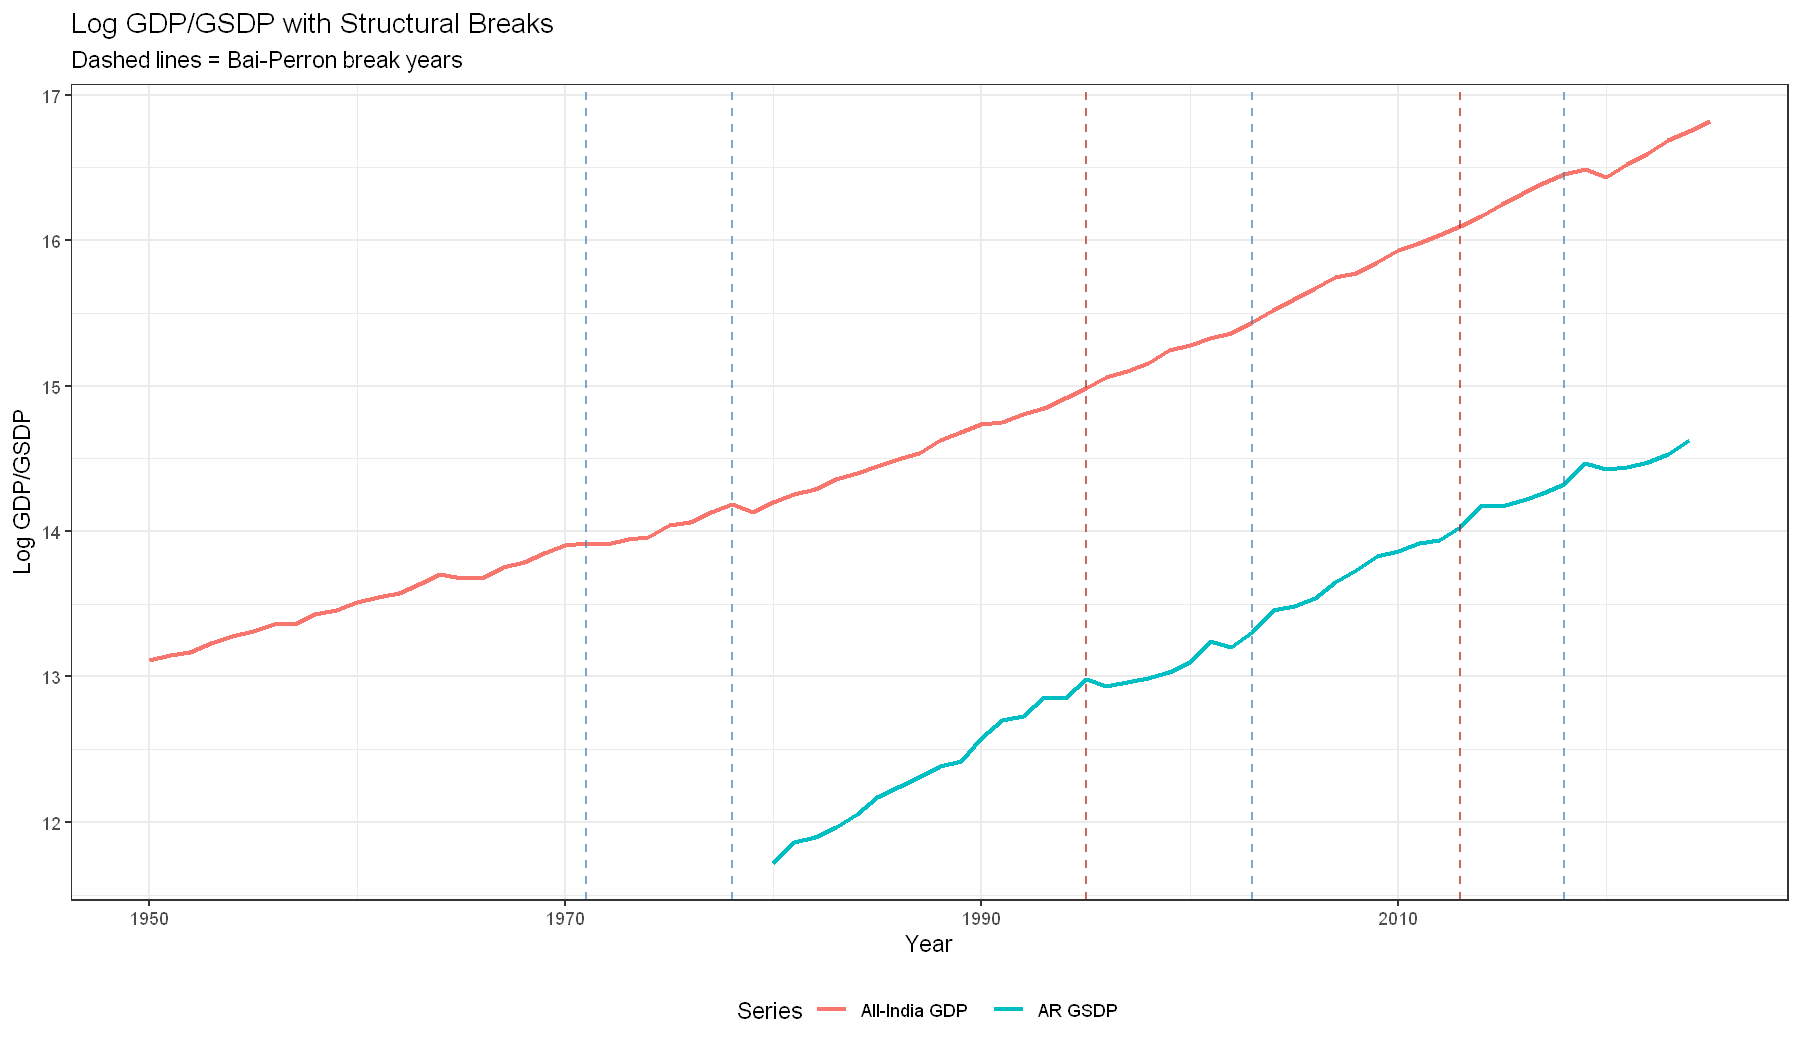

In [49]:
# Merge India and AR log GDP
dual <- merge(gdp_india[,c('NumYear','log_GDP')], ar_gdp[,c('NumYear','log_GSDP')], by='NumYear', all=TRUE)

p1 <- ggplot(dual, aes(x=NumYear)) +
  geom_line(aes(y=log_GDP, color='All-India GDP'), linewidth=1) +
  geom_line(aes(y=log_GSDP, color='AR GSDP'), linewidth=1) +
  geom_vline(xintercept=break_years_india, linetype='dashed', color='steelblue', alpha=0.7) +
  geom_vline(xintercept=break_years_ar, linetype='dashed', color='firebrick', alpha=0.7) +
  labs(title='Log GDP/GSDP with Structural Breaks', x='Year', y='Log GDP/GSDP',
       subtitle='Dashed lines = Bai-Perron break years', color='Series') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig1_log_gdp_breaks.png'), p1, width=10, height=6, dpi=300)
cat('Figure 1 saved:', file.exists(file.path(FIG_DIR, 'fig1_log_gdp_breaks.png')), '\n')
p1

### Figure 2 - AR Real GSDP with Structural Breaks

Figure 2 saved: TRUE 


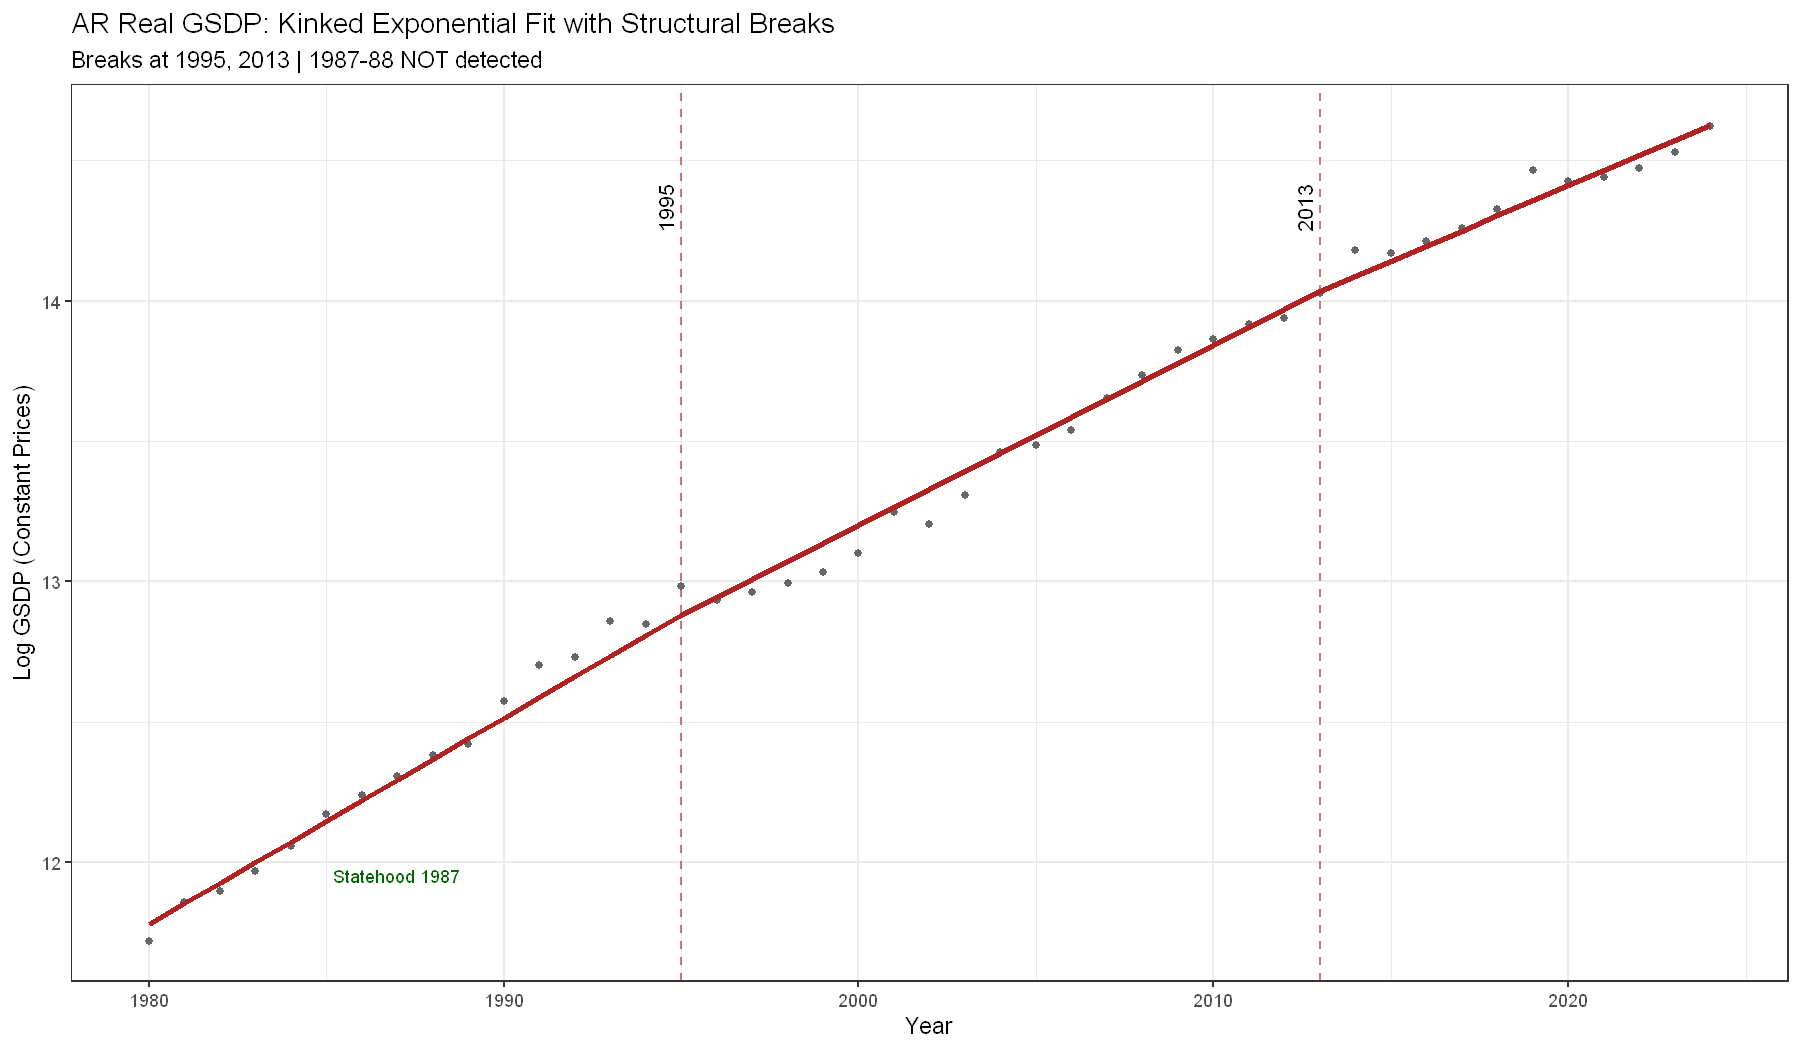

In [50]:
ar_fit <- data.frame(NumYear=ar_gdp$NumYear, log_GSDP=ar_gdp$log_GSDP, fitted=fitted(kinked_ar))

p2 <- ggplot(ar_fit, aes(x=NumYear)) +
  geom_point(aes(y=log_GSDP), color='grey40', size=1.5) +
  geom_line(aes(y=fitted), color='firebrick', linewidth=1.2) +
  geom_vline(xintercept=break_years_ar, linetype='dashed', color='firebrick', alpha=0.6) +
  annotate('text', x=break_years_ar, y=max(ar_fit$log_GSDP)*0.98,
           label=break_years_ar, angle=90, vjust=-0.5, size=3.5) +
  annotate('text', x=1987, y=min(ar_fit$log_GSDP)*1.02, label='Statehood 1987', color='darkgreen', size=3) +
  labs(title='AR Real GSDP: Kinked Exponential Fit with Structural Breaks',
       subtitle=sprintf('Breaks at %s | 1987-88 NOT detected', paste(break_years_ar, collapse=', ')),
       x='Year', y='Log GSDP (Constant Prices)') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig2_ar_gsdp_breaks.png'), p2, width=10, height=6, dpi=300)
cat('Figure 2 saved:', file.exists(file.path(FIG_DIR, 'fig2_ar_gsdp_breaks.png')), '\n')
p2

### Figure 3 - Sectoral Shares in AR GSDP

Figure 3 saved: TRUE 


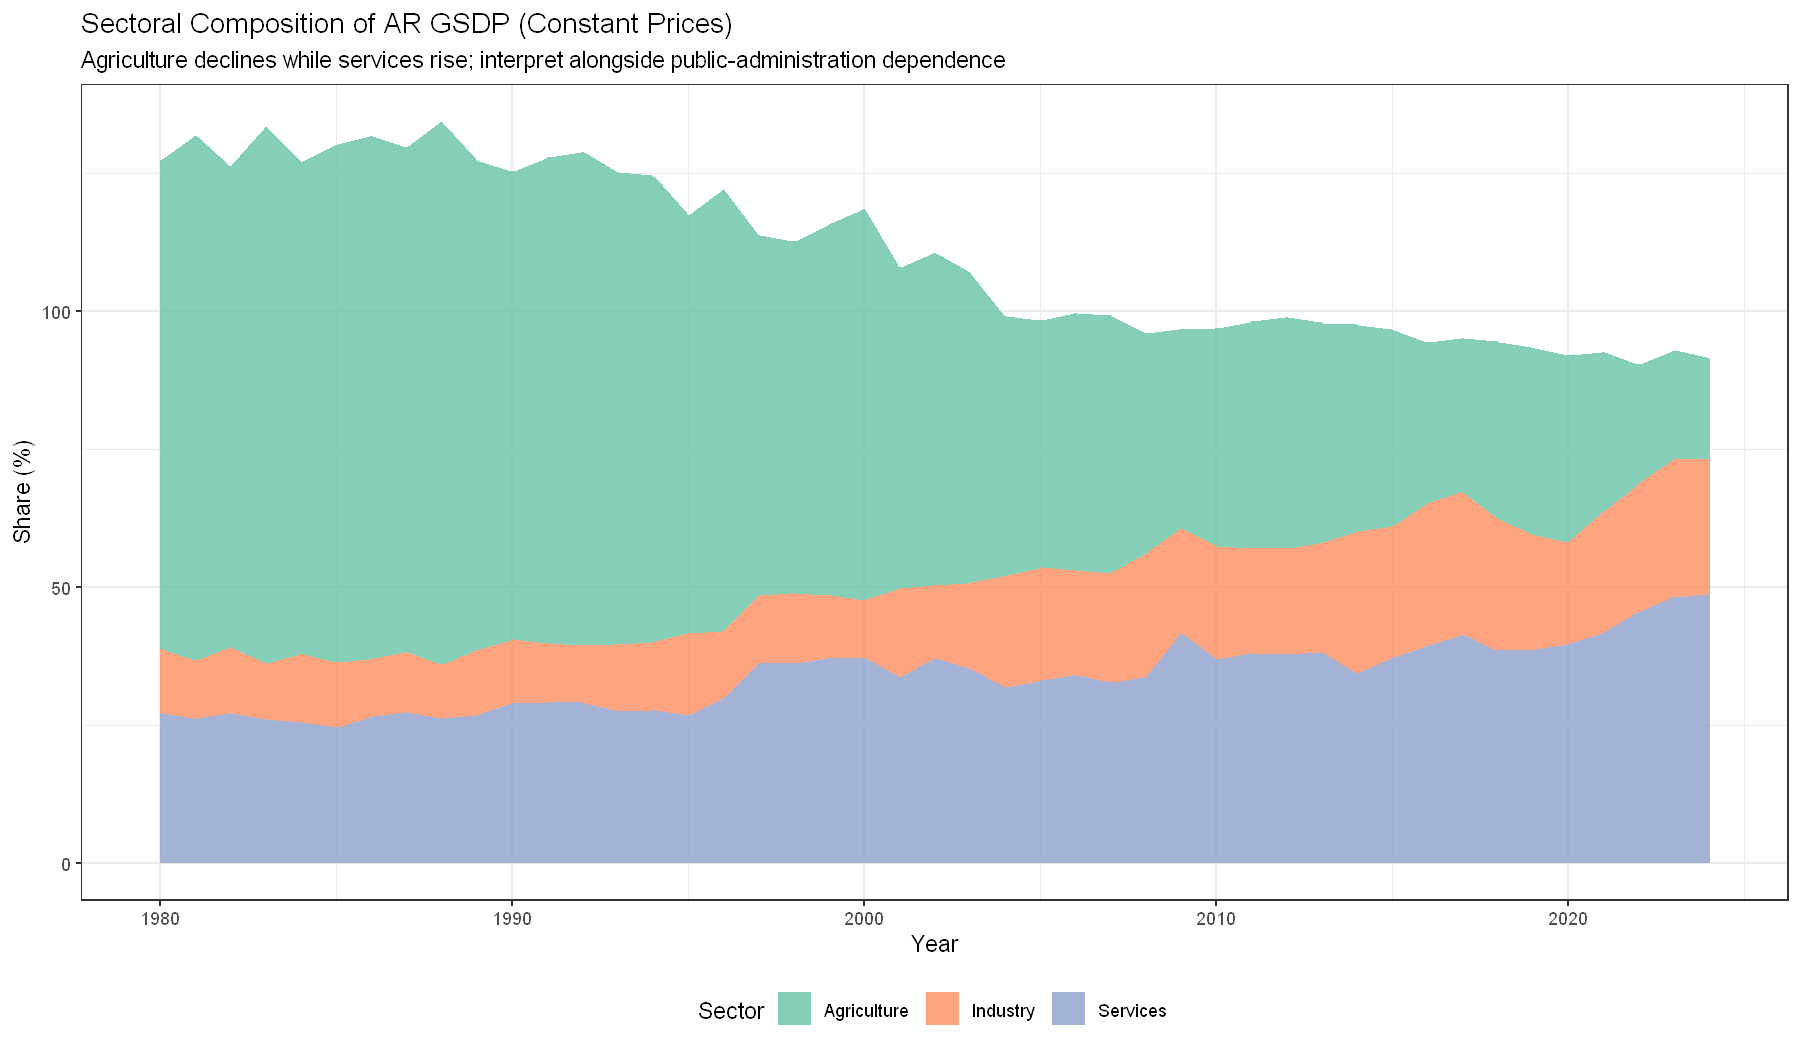

In [51]:
sect_long <- ar_gdp %>% select(NumYear, Agr_share, Ind_share, Srv_share) %>%
  pivot_longer(-NumYear, names_to='Sector', values_to='Share') %>%
  mutate(Sector = recode(Sector, Agr_share='Agriculture', Ind_share='Industry', Srv_share='Services'))

p3 <- ggplot(sect_long, aes(x=NumYear, y=Share, fill=Sector)) +
  geom_area(alpha=0.8) +
  scale_fill_manual(values=c('Agriculture'='#66c2a5','Industry'='#fc8d62','Services'='#8da0cb')) +
  labs(title='Sectoral Composition of AR GSDP (Constant Prices)',
       subtitle='Agriculture declines while services rise; interpret alongside public-administration dependence',
       x='Year', y='Share (%)') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig3_sectoral_shares.png'), p3, width=10, height=6, dpi=300)
cat('Figure 3 saved:', file.exists(file.path(FIG_DIR, 'fig3_sectoral_shares.png')), '\n')
p3

### Figure 4 - AR Piecewise Fitted Growth

Figure 4 saved: TRUE 


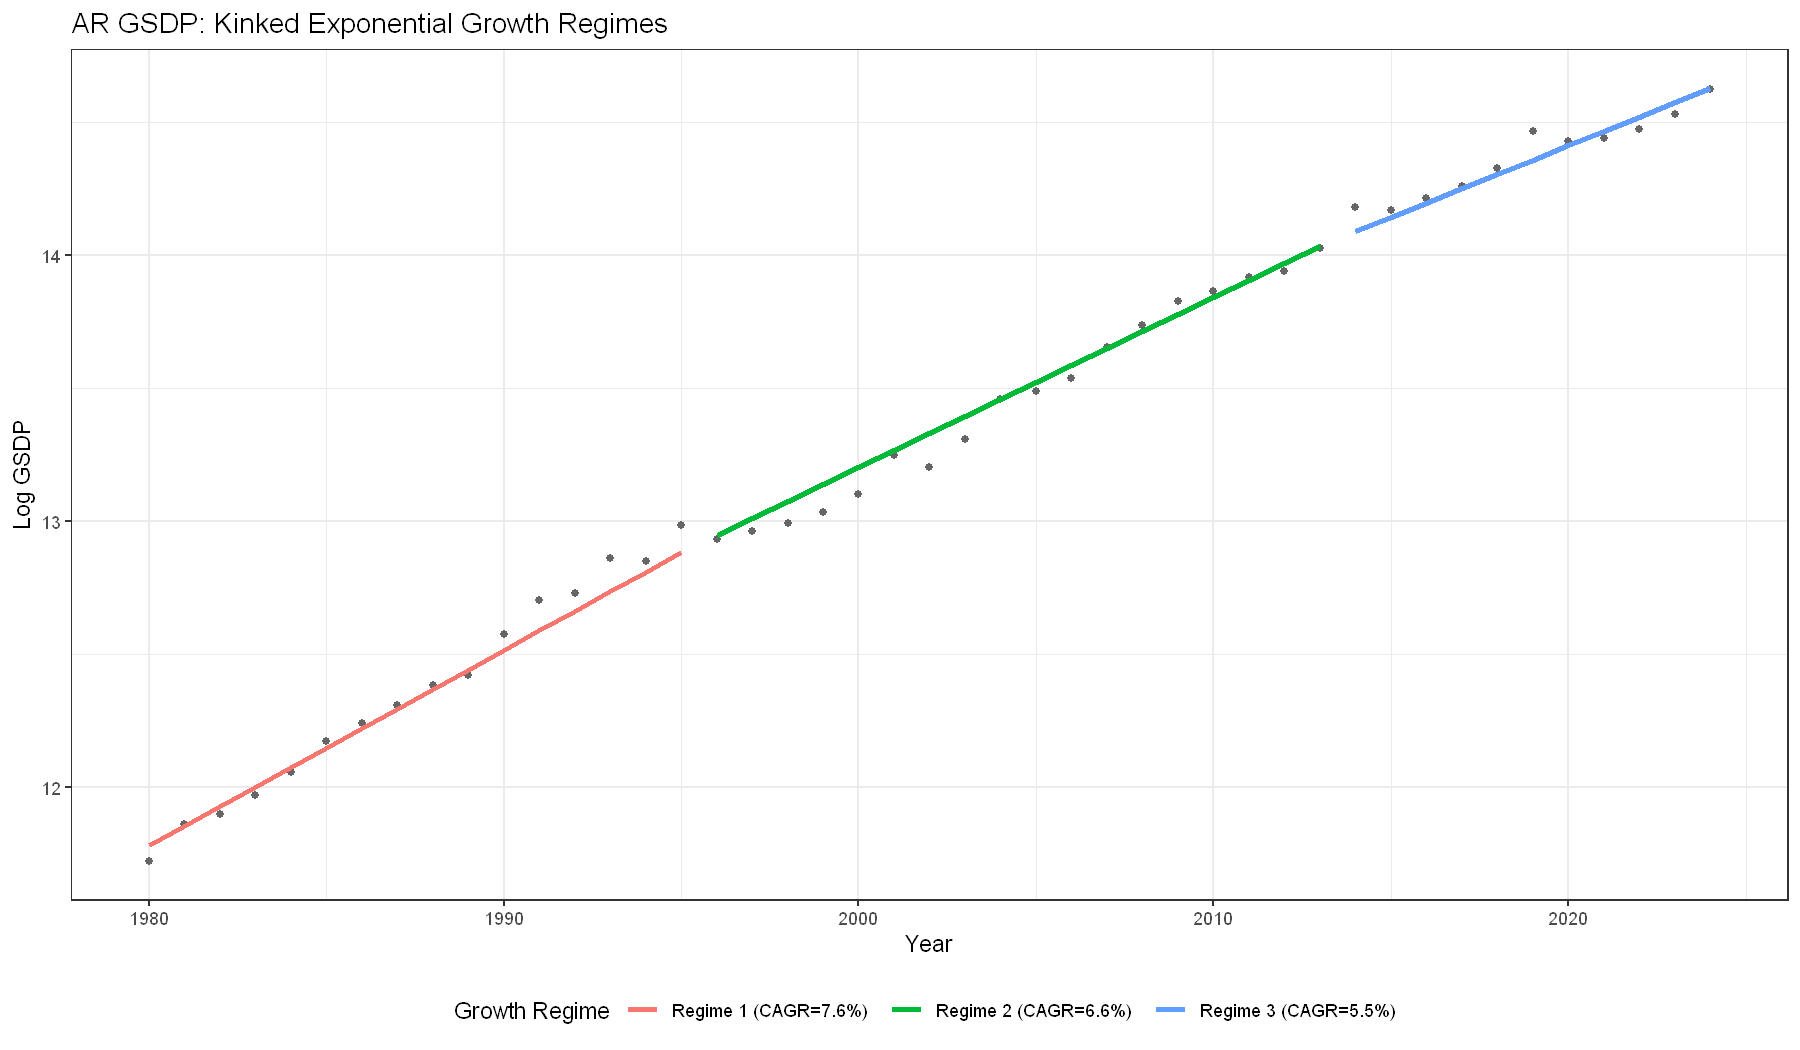

In [52]:
ar_fit$regime <- cut(ar_fit$NumYear,
  breaks=c(-Inf, break_years_ar, Inf),
  labels=paste0('Regime ', 1:(n_breaks_ar+1), ' (CAGR=', round((exp(growth_ar)-1)*100,1), '%)'))

p4 <- ggplot(ar_fit, aes(x=NumYear)) +
  geom_point(aes(y=log_GSDP), color='grey40', size=1.5) +
  geom_line(aes(y=fitted, color=regime), linewidth=1.3) +
  labs(title='AR GSDP: Kinked Exponential Growth Regimes',
       x='Year', y='Log GSDP', color='Growth Regime') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig4_ar_kinked_fit.png'), p4, width=10, height=6, dpi=300)
cat('Figure 4 saved:', file.exists(file.path(FIG_DIR, 'fig4_ar_kinked_fit.png')), '\n')
p4

### Figure 5 - Quarterly CPI Inflation: India vs AR

Figure 5 saved: TRUE 


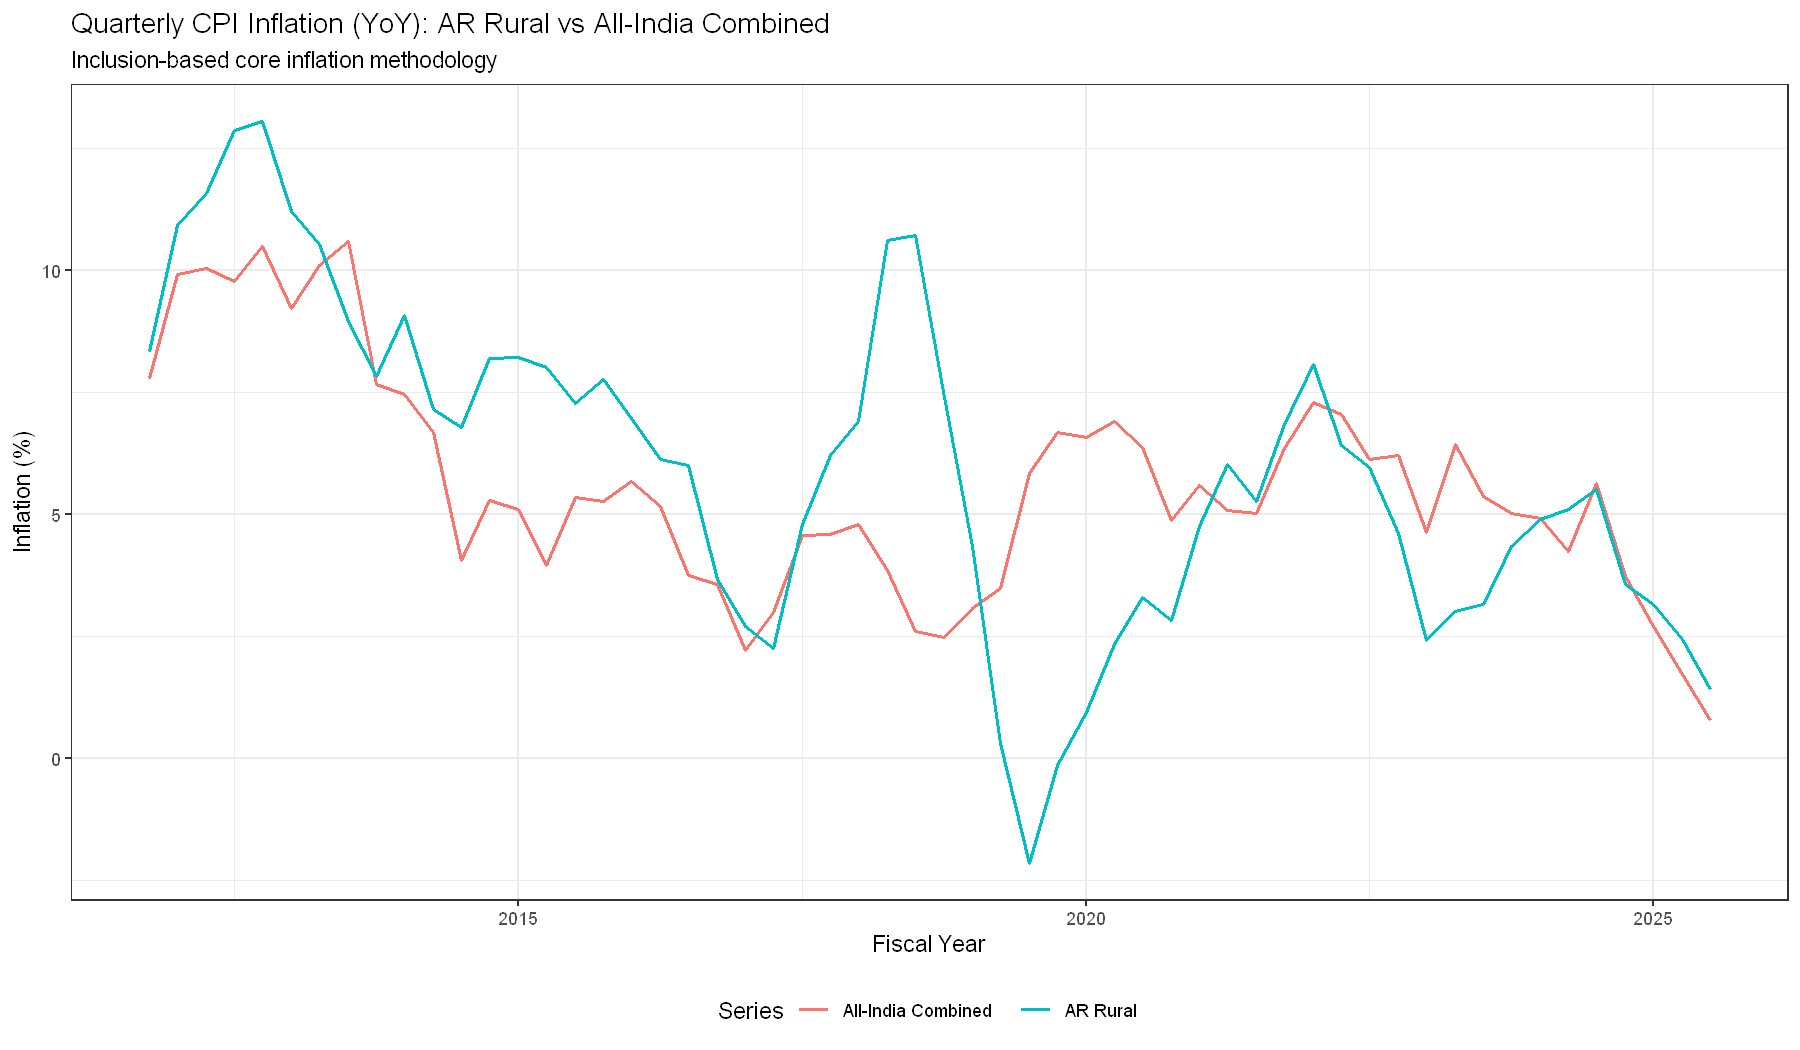

In [53]:
q_merged$time_idx <- q_merged$FY + (q_merged$FQ-1)/4

p5 <- ggplot(q_merged, aes(x=time_idx)) +
  geom_line(aes(y=inflation_combined, color='All-India Combined'), linewidth=0.8) +
  geom_line(aes(y=inflation_rural, color='AR Rural'), linewidth=0.8) +
  labs(title='Quarterly CPI Inflation (YoY): AR Rural vs All-India Combined',
       subtitle='Inclusion-based core inflation methodology',
       x='Fiscal Year', y='Inflation (%)', color='Series') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig5_quarterly_cpi.png'), p5, width=10, height=6, dpi=300)
cat('Figure 5 saved:', file.exists(file.path(FIG_DIR, 'fig5_quarterly_cpi.png')), '\n')
p5

### Figure 6 - Annual Headline vs Core Inflation

Figure 6 saved: TRUE 


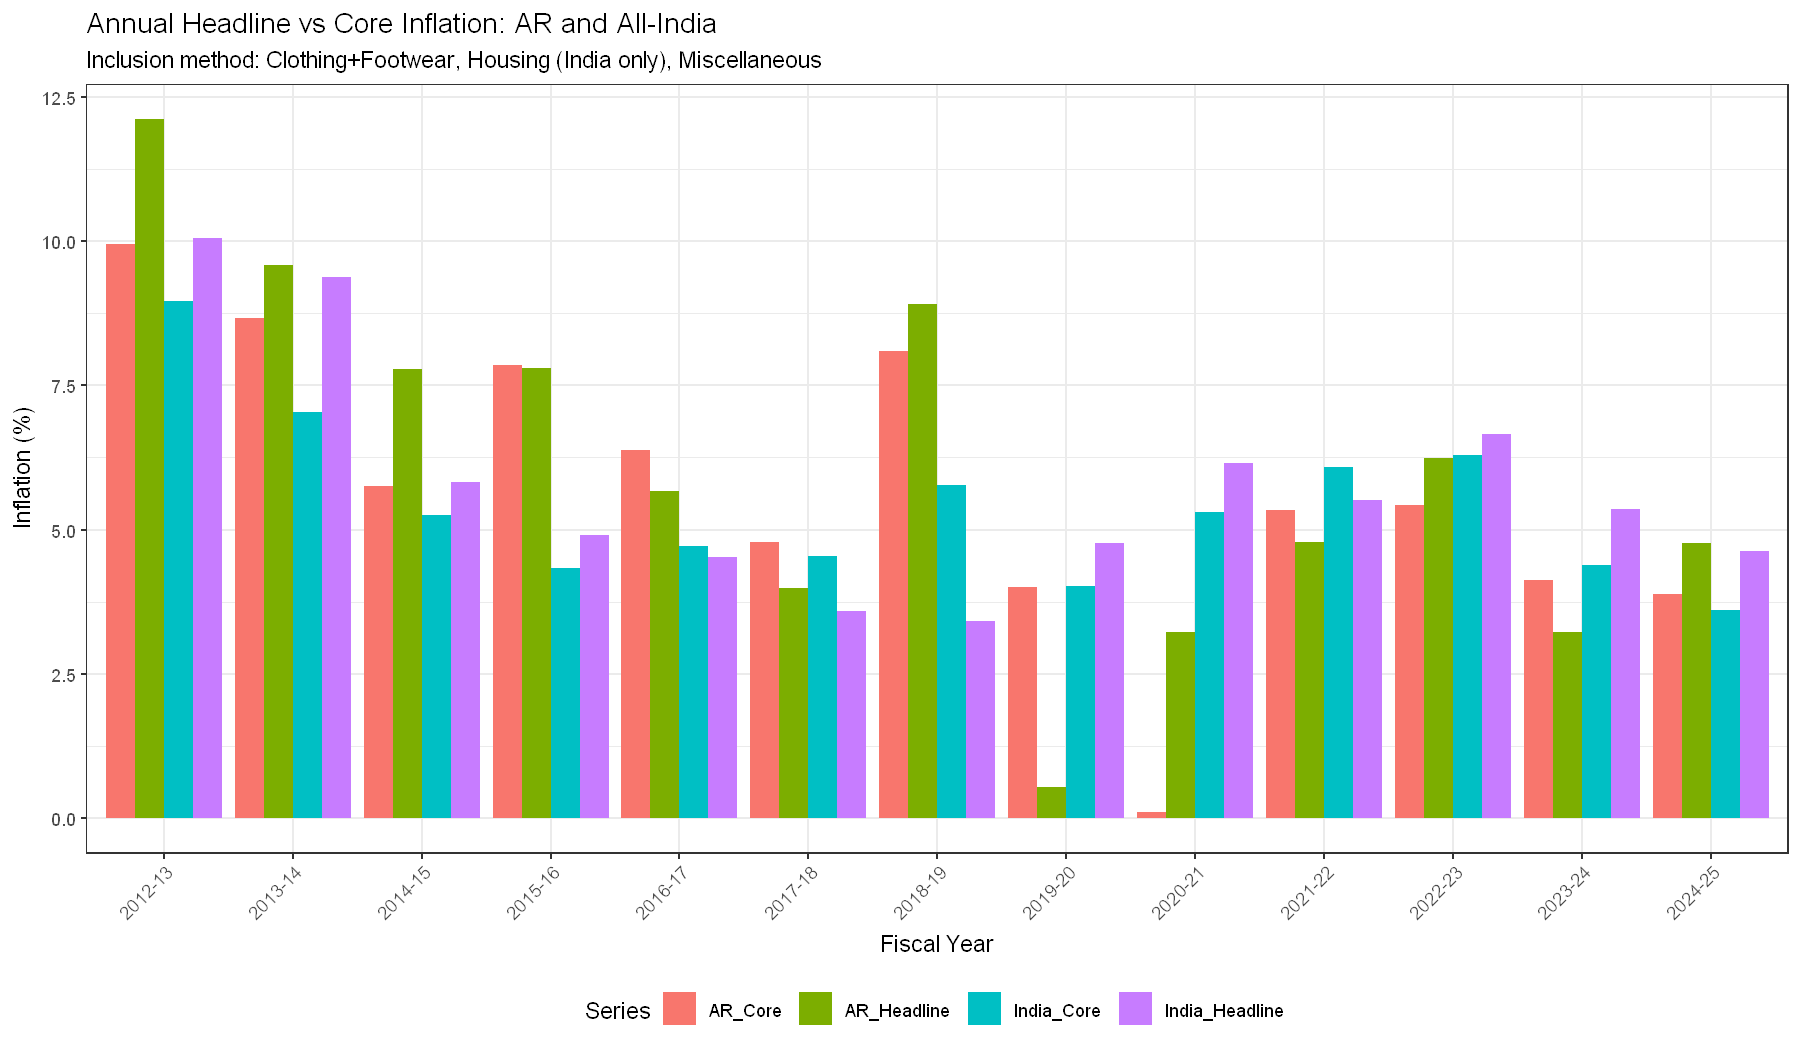

In [54]:
t4_long <- table4 %>% filter(!is.na(AR_Headline), !is.na(AR_Core), !is.na(India_Headline), !is.na(India_Core)) %>%
  pivot_longer(-FY_label, names_to='Series', values_to='Inflation')

p6 <- ggplot(t4_long, aes(x=FY_label, y=Inflation, fill=Series)) +
  geom_bar(stat='identity', position='dodge') +
  labs(title='Annual Headline vs Core Inflation: AR and All-India',
       subtitle='Inclusion method: Clothing+Footwear, Housing (India only), Miscellaneous',
       x='Fiscal Year', y='Inflation (%)') +
  theme_bw() + theme(axis.text.x=element_text(angle=45, hjust=1), legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig6_headline_core.png'), p6, width=10, height=6, dpi=300)
cat('Figure 6 saved:', file.exists(file.path(FIG_DIR, 'fig6_headline_core.png')), '\n')
p6

### Figure 7 - Sigma-Convergence

Figure 7 saved: TRUE 


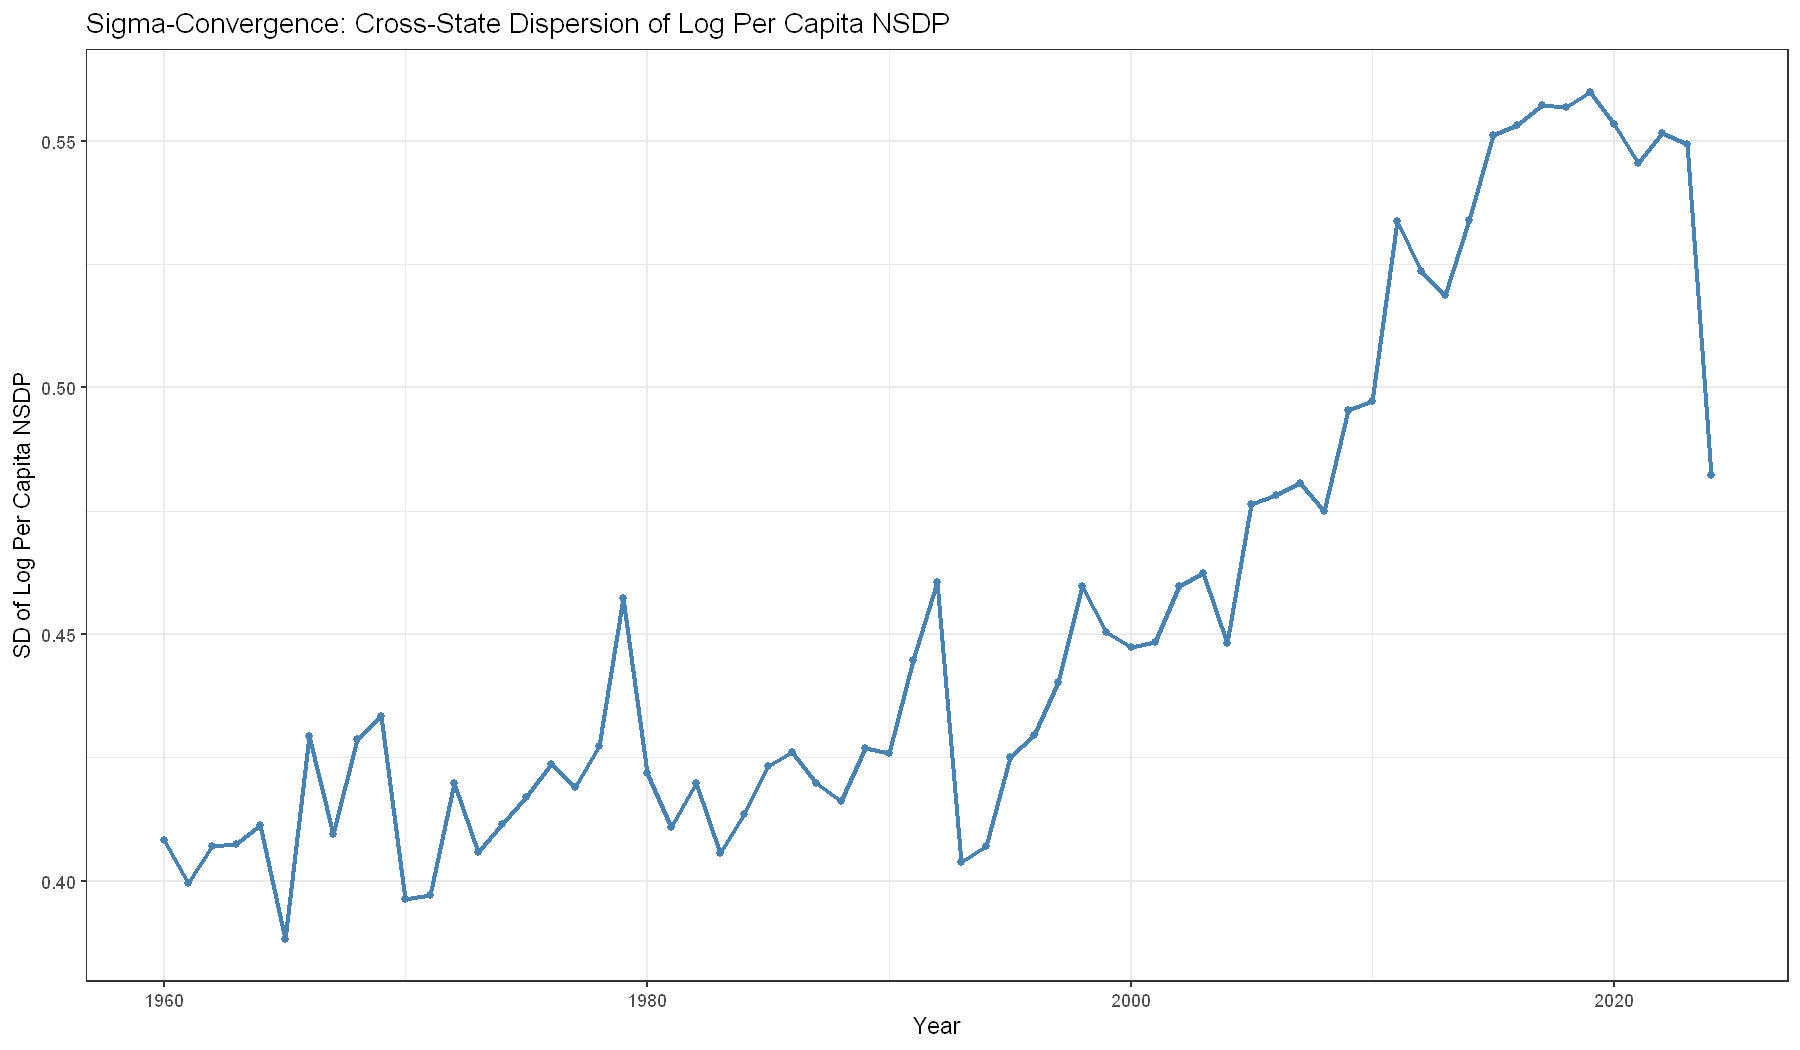

In [55]:
p7 <- ggplot(sigma_df, aes(x=Year, y=SD_log)) +
  geom_line(linewidth=1, color='steelblue') +
  geom_point(size=1.5, color='steelblue') +
  labs(title='Sigma-Convergence: Cross-State Dispersion of Log Per Capita NSDP',
       x='Year', y='SD of Log Per Capita NSDP') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig7_sigma_convergence.png'), p7, width=10, height=6, dpi=300)
cat('Figure 7 saved:', file.exists(file.path(FIG_DIR, 'fig7_sigma_convergence.png')), '\n')
p7

### Figure 8 - Fiscal Dependence Ratio

Figure 8 saved: TRUE 


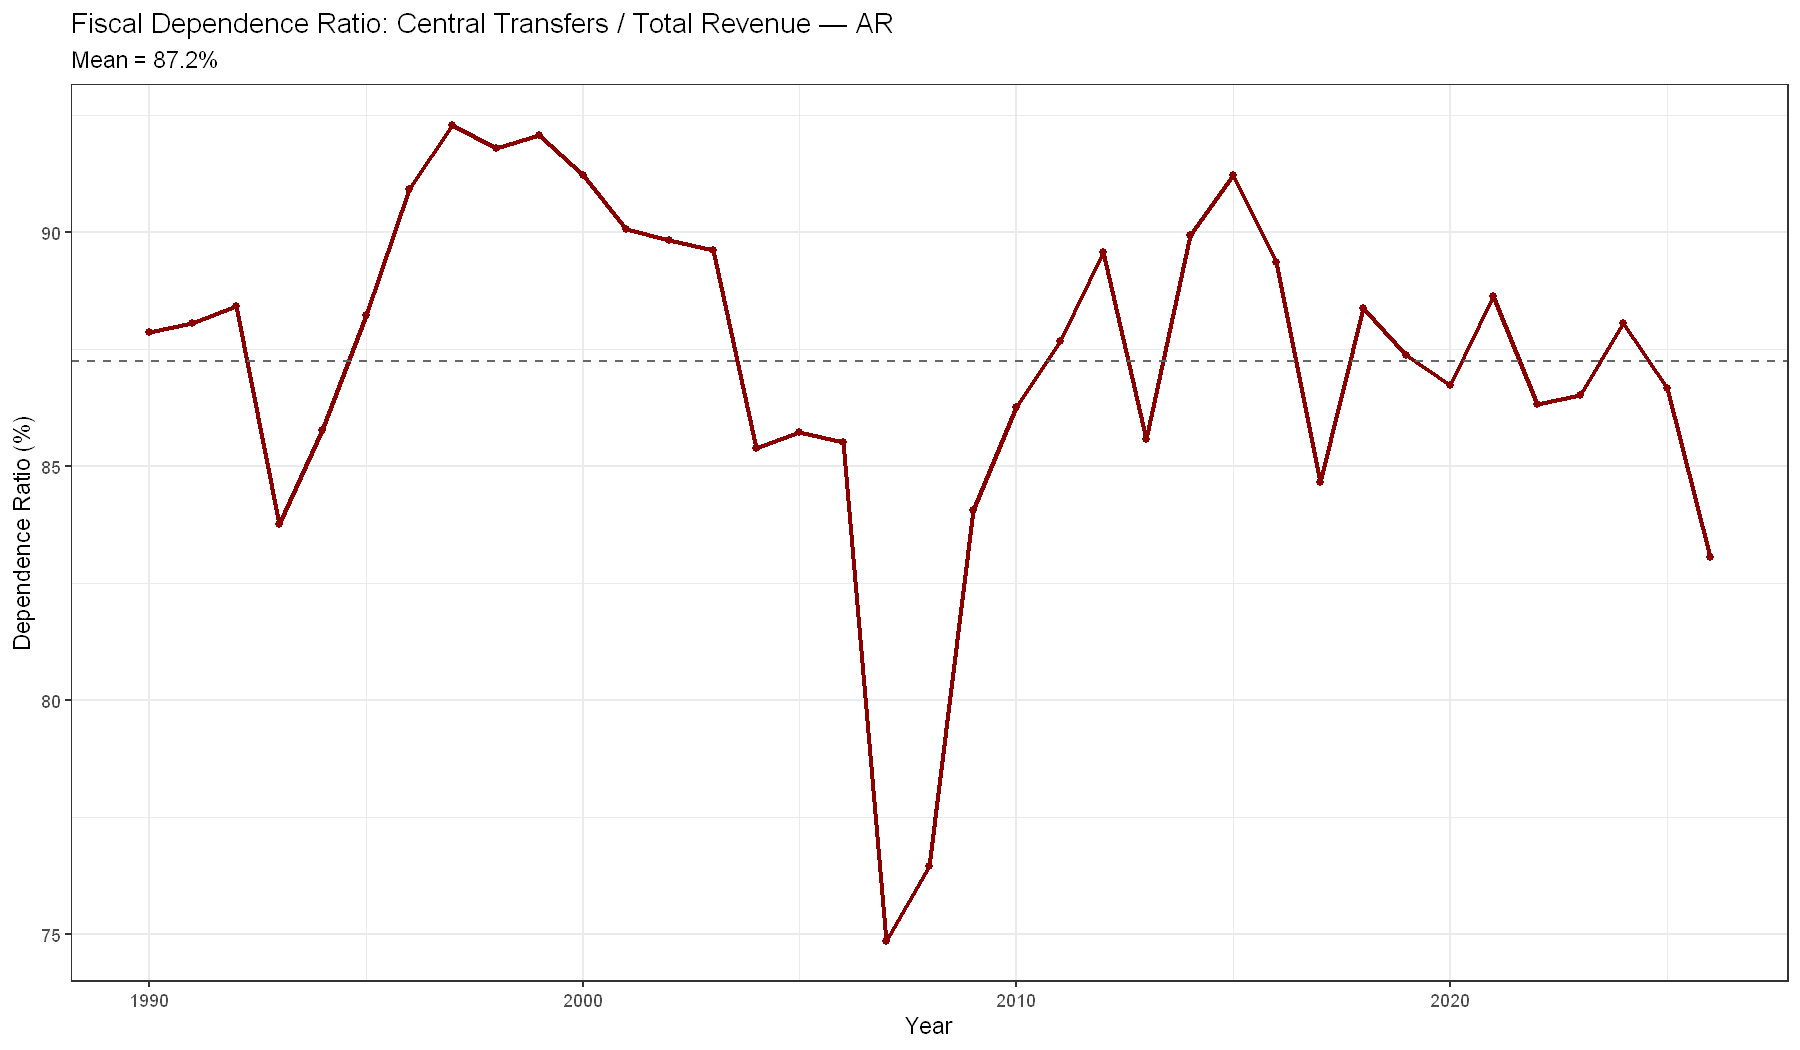

In [56]:
p8 <- ggplot(fisc_dep, aes(x=NumYear, y=DepRatio)) +
  geom_line(linewidth=1, color='darkred') +
  geom_point(size=1.5, color='darkred') +
  geom_hline(yintercept=mean(fisc_dep$DepRatio, na.rm=T), linetype='dashed', color='grey40') +
  labs(title='Fiscal Dependence Ratio: Central Transfers / Total Revenue - AR',
       subtitle=sprintf('Mean = %.1f%%', mean(fisc_dep$DepRatio, na.rm=T)),
       x='Year', y='Dependence Ratio (%)') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig8_fiscal_dependence.png'), p8, width=10, height=6, dpi=300)
cat('Figure 8 saved:', file.exists(file.path(FIG_DIR, 'fig8_fiscal_dependence.png')), '\n')
p8

### Figure 9 - Revenue Surplus, Fiscal & Primary Balance as % GSDP

Figure 9 saved: TRUE 


  NumYear RevBalance_GSDP OfficialFiscalBalance_GSDP
1    2022       17.838699                 -2.0312264
2    2023       17.831169                  0.5422048
3    2024       17.976219                  2.0393940
4    2025       16.922571                 -1.5655419
5    2026        8.887545                 -1.6921581
  OfficialPrimaryBalance_GSDP
1                   0.3059460
2                   2.7670894
3                   3.9233802
4                   0.8297187
5                   0.7706230


[1] 5 4


'data.frame':	5 obs. of  4 variables:
 $ NumYear                    : num  2022 2023 2024 2025 2026
 $ RevBalance_GSDP            : num  17.84 17.83 17.98 16.92 8.89
 $ OfficialFiscalBalance_GSDP : num  -2.031 0.542 2.039 -1.566 -1.692
 $ OfficialPrimaryBalance_GSDP: num  0.306 2.767 3.923 0.83 0.771


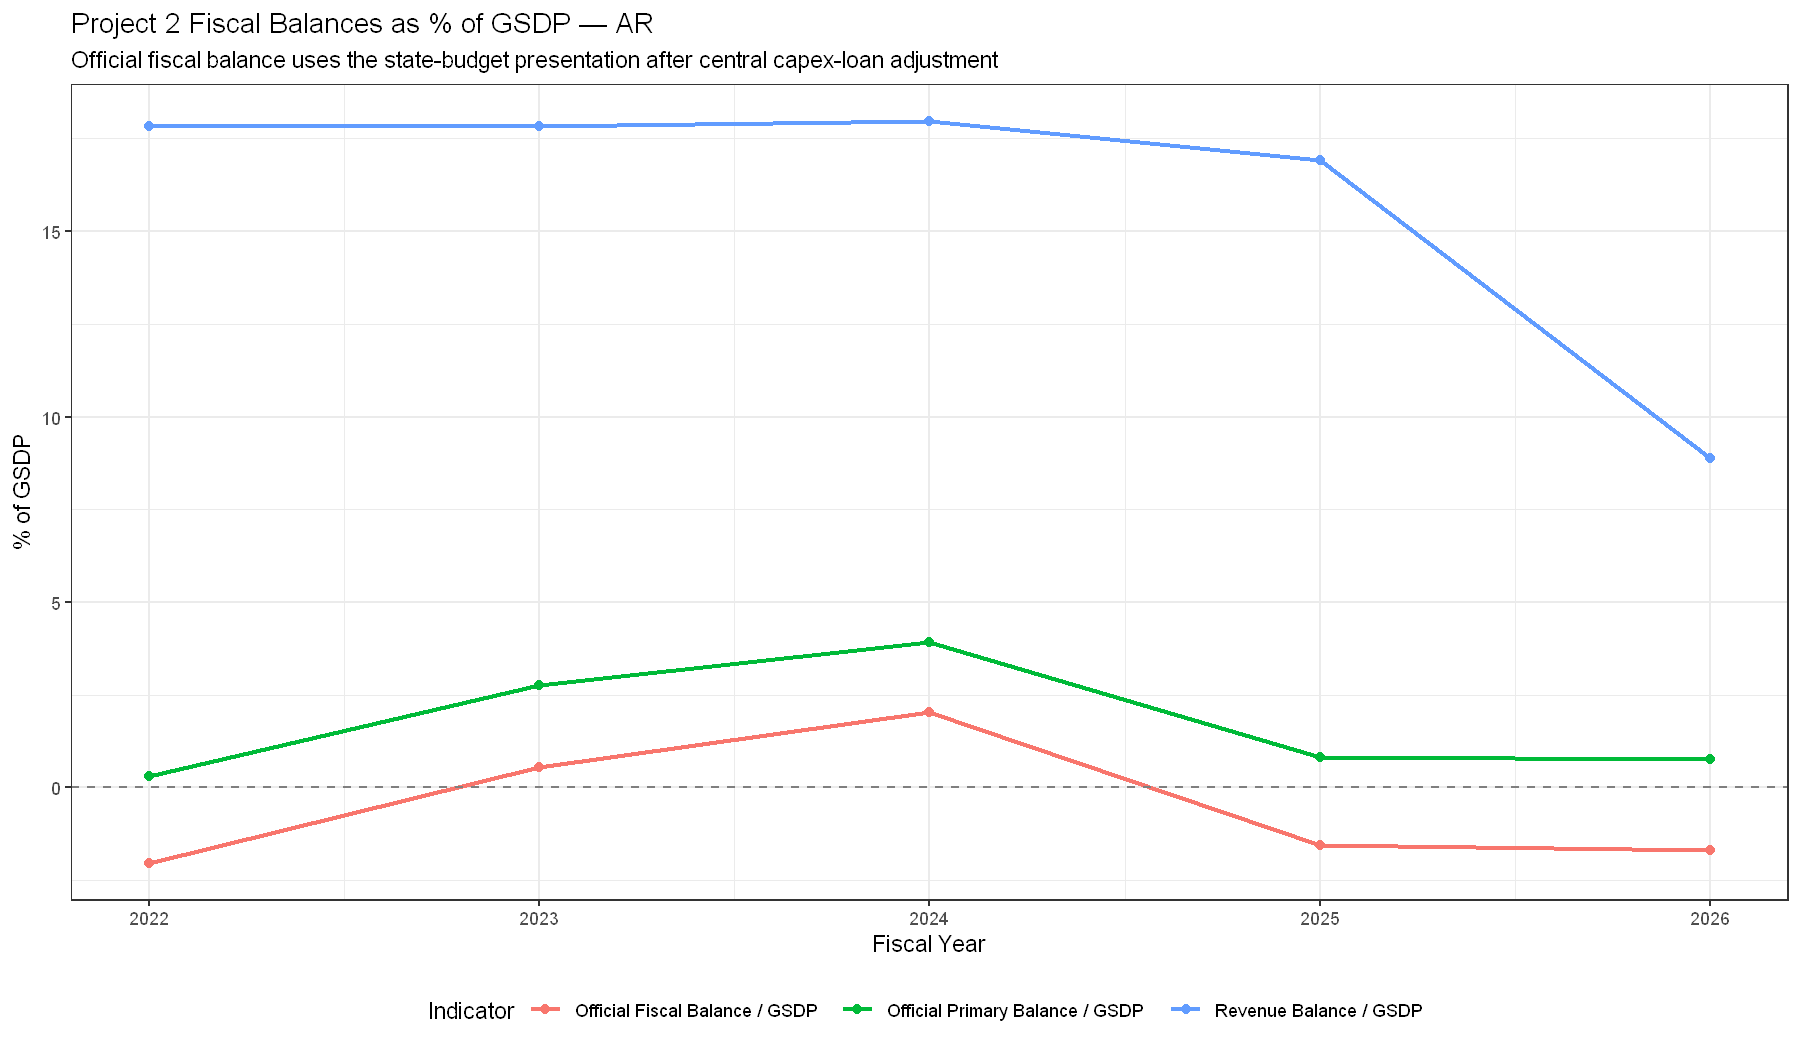

In [57]:
p9 <- ggplot(proj2, aes(x = NumYear)) +
  geom_line(aes(y = RevBalance_GSDP, color = 'Revenue Balance / GSDP'), linewidth = 1) +
  geom_line(aes(y = OfficialFiscalBalance_GSDP, color = 'Official Fiscal Balance / GSDP'), linewidth = 1) +
  geom_line(aes(y = OfficialPrimaryBalance_GSDP, color = 'Official Primary Balance / GSDP'), linewidth = 1) +
  geom_point(aes(y = RevBalance_GSDP, color = 'Revenue Balance / GSDP'), size = 2) +
  geom_point(aes(y = OfficialFiscalBalance_GSDP, color = 'Official Fiscal Balance / GSDP'), size = 2) +
  geom_point(aes(y = OfficialPrimaryBalance_GSDP, color = 'Official Primary Balance / GSDP'), size = 2) +
  geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey50') +
  labs(title = 'Project 2 Fiscal Balances as % of GSDP - AR',
       subtitle = 'Official fiscal balance uses the state-budget presentation after central capex-loan adjustment',
       x = 'Fiscal Year', y = '% of GSDP', color = 'Indicator') +
  theme_bw() + theme(legend.position = 'bottom')

ggsave(file.path(FIG_DIR, 'fig9_fiscal_balances.png'), p9, width = 10, height = 6, dpi = 300)
cat('Figure 9 saved:', file.exists(file.path(FIG_DIR, 'fig9_fiscal_balances.png')), '
')
print(head(proj2[, c('NumYear', 'RevBalance_GSDP', 'OfficialFiscalBalance_GSDP', 'OfficialPrimaryBalance_GSDP')]))
print(dim(proj2[, c('NumYear', 'RevBalance_GSDP', 'OfficialFiscalBalance_GSDP', 'OfficialPrimaryBalance_GSDP')]))
str(proj2[, c('NumYear', 'RevBalance_GSDP', 'OfficialFiscalBalance_GSDP', 'OfficialPrimaryBalance_GSDP')])
p9


### Figure 10 - Capital Outlay vs Interest Payments

Figure 10 saved: TRUE 


  NumYear Interest_RevExp CapOutlay_RevExp
1    1990        6.027737         48.23352
2    1991        7.432268         47.50809
3    1992        6.418134         44.75348
4    1993        6.901825         40.83684
5    1994        7.867754         54.64136
6    1995        8.348611         56.42951


[1] 37  3


'data.frame':	37 obs. of  3 variables:
 $ NumYear         : num  1990 1991 1992 1993 1994 ...
 $ Interest_RevExp : num  6.03 7.43 6.42 6.9 7.87 ...
 $ CapOutlay_RevExp: num  48.2 47.5 44.8 40.8 54.6 ...


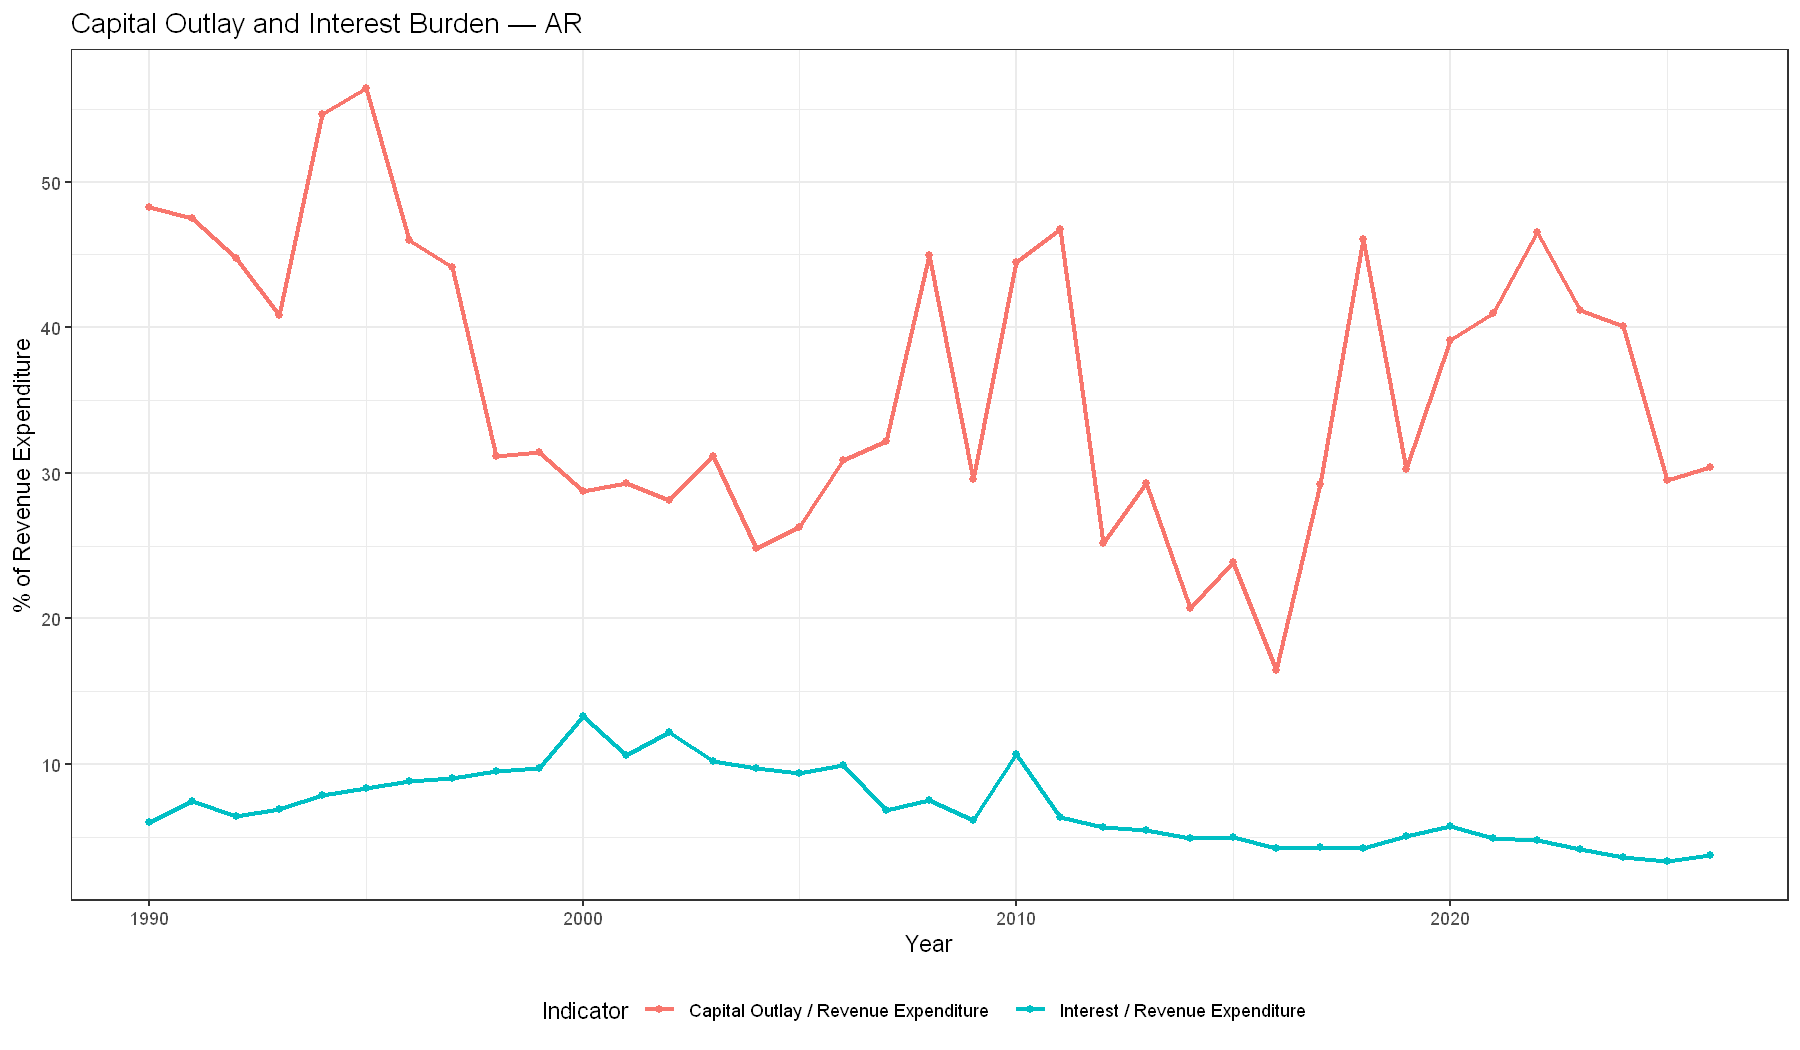

In [58]:
int_ratio <- ext_fiscal %>% select(NumYear, Interest_RevExp, CapOutlay_RevExp) %>% filter(!is.na(Interest_RevExp) & !is.na(CapOutlay_RevExp))

int_long <- int_ratio %>%
  pivot_longer(-NumYear, names_to = 'Indicator', values_to = 'Ratio') %>%
  mutate(Indicator = recode(Indicator,
    Interest_RevExp = 'Interest / Revenue Expenditure',
    CapOutlay_RevExp = 'Capital Outlay / Revenue Expenditure'))

p10 <- ggplot(int_long, aes(x = NumYear, y = Ratio, color = Indicator)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  labs(title = 'Capital Outlay and Interest Burden - AR', x = 'Year', y = '% of Revenue Expenditure', color = 'Indicator') +
  theme_bw() + theme(legend.position = 'bottom')

ggsave(file.path(FIG_DIR, 'fig10_interest_ratio.png'), p10, width = 10, height = 6, dpi = 300)
cat('Figure 10 saved:', file.exists(file.path(FIG_DIR, 'fig10_interest_ratio.png')), '
')
print(head(int_ratio))
print(dim(int_ratio))
str(int_ratio)
p10


### Figure 11 - Own Revenue / Revenue Expenditure

Figure 11 saved: TRUE 


  NumYear OwnRev_RevExp
1    1990      16.84745
2    1991      18.53720
3    1992      17.13757
4    1993      22.26233
5    1994      19.62723
6    1995      17.49561


[1] 37  2


'data.frame':	37 obs. of  2 variables:
 $ NumYear      : num  1990 1991 1992 1993 1994 ...
 $ OwnRev_RevExp: num  16.8 18.5 17.1 22.3 19.6 ...


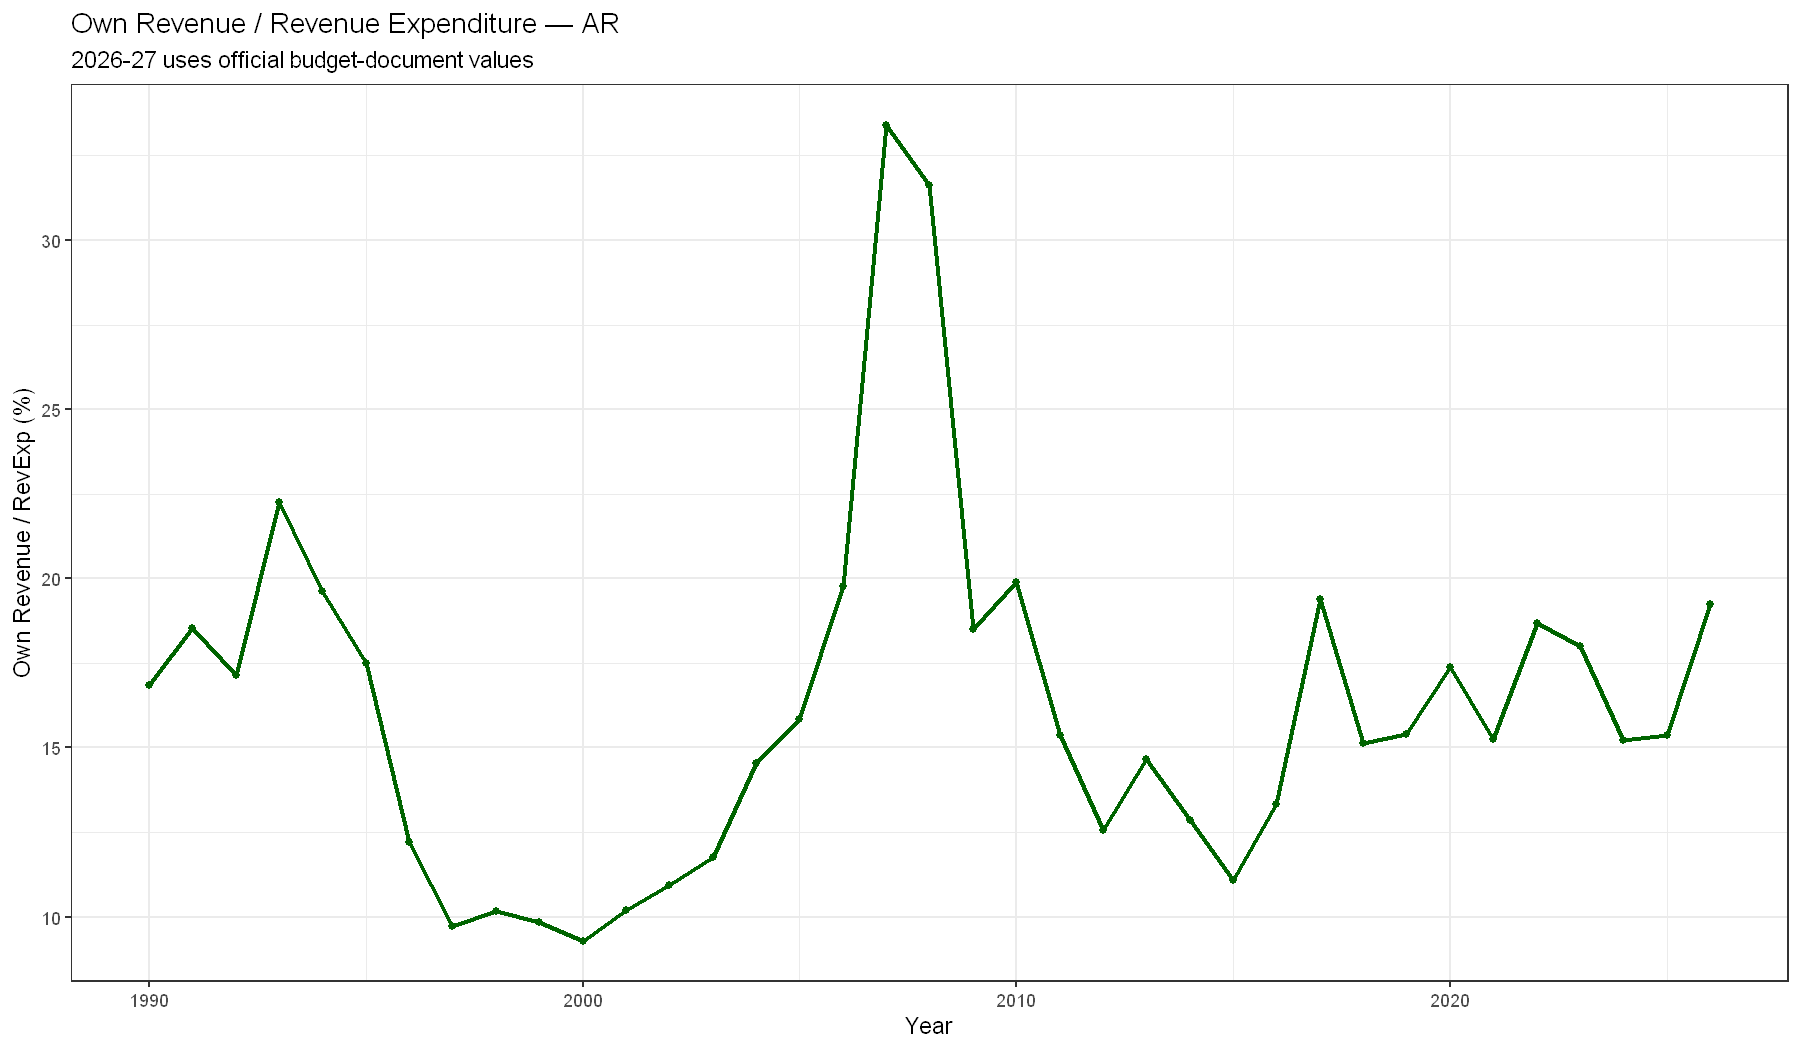

In [59]:
p11 <- ggplot(ext_fiscal, aes(x = NumYear, y = OwnRev_RevExp)) +
  geom_line(linewidth = 1, color = 'darkgreen') +
  geom_point(size = 1.5, color = 'darkgreen') +
  labs(title = 'Own Revenue / Revenue Expenditure - AR', subtitle = '2026-27 uses official budget-document values', x = 'Year', y = 'Own Revenue / RevExp (%)') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig11_own_revenue_ratio.png'), p11, width = 10, height = 6, dpi = 300)
cat('Figure 11 saved:', file.exists(file.path(FIG_DIR, 'fig11_own_revenue_ratio.png')), '
')
print(head(ext_fiscal[, c('NumYear', 'OwnRev_RevExp')]))
print(dim(ext_fiscal[, c('NumYear', 'OwnRev_RevExp')]))
str(ext_fiscal[, c('NumYear', 'OwnRev_RevExp')])
p11


### Figure 12 - Official vs Broad Fiscal Balance Measures


Figure 12 saved: TRUE 


# A tibble: 6 × 3
  NumYear Measure                               Ratio
    <dbl> <chr>                                 <dbl>
1    2022 Official state-budget balance / GSDP -2.03 
2    2022 Broad PRS-style balance / GSDP       -6.41 
3    2023 Official state-budget balance / GSDP  0.542
4    2023 Broad PRS-style balance / GSDP       -5.59 
5    2024 Official state-budget balance / GSDP  2.04 
6    2024 Broad PRS-style balance / GSDP       -3.13 


[1] 10  3


tibble [10 × 3] (S3: tbl_df/tbl/data.frame)
 $ NumYear: num [1:10] 2022 2022 2023 2023 2024 ...
 $ Measure: chr [1:10] "Official state-budget balance / GSDP" "Broad PRS-style balance / GSDP" "Official state-budget balance / GSDP" "Broad PRS-style balance / GSDP" ...
 $ Ratio  : num [1:10] -2.031 -6.411 0.542 -5.586 2.039 ...


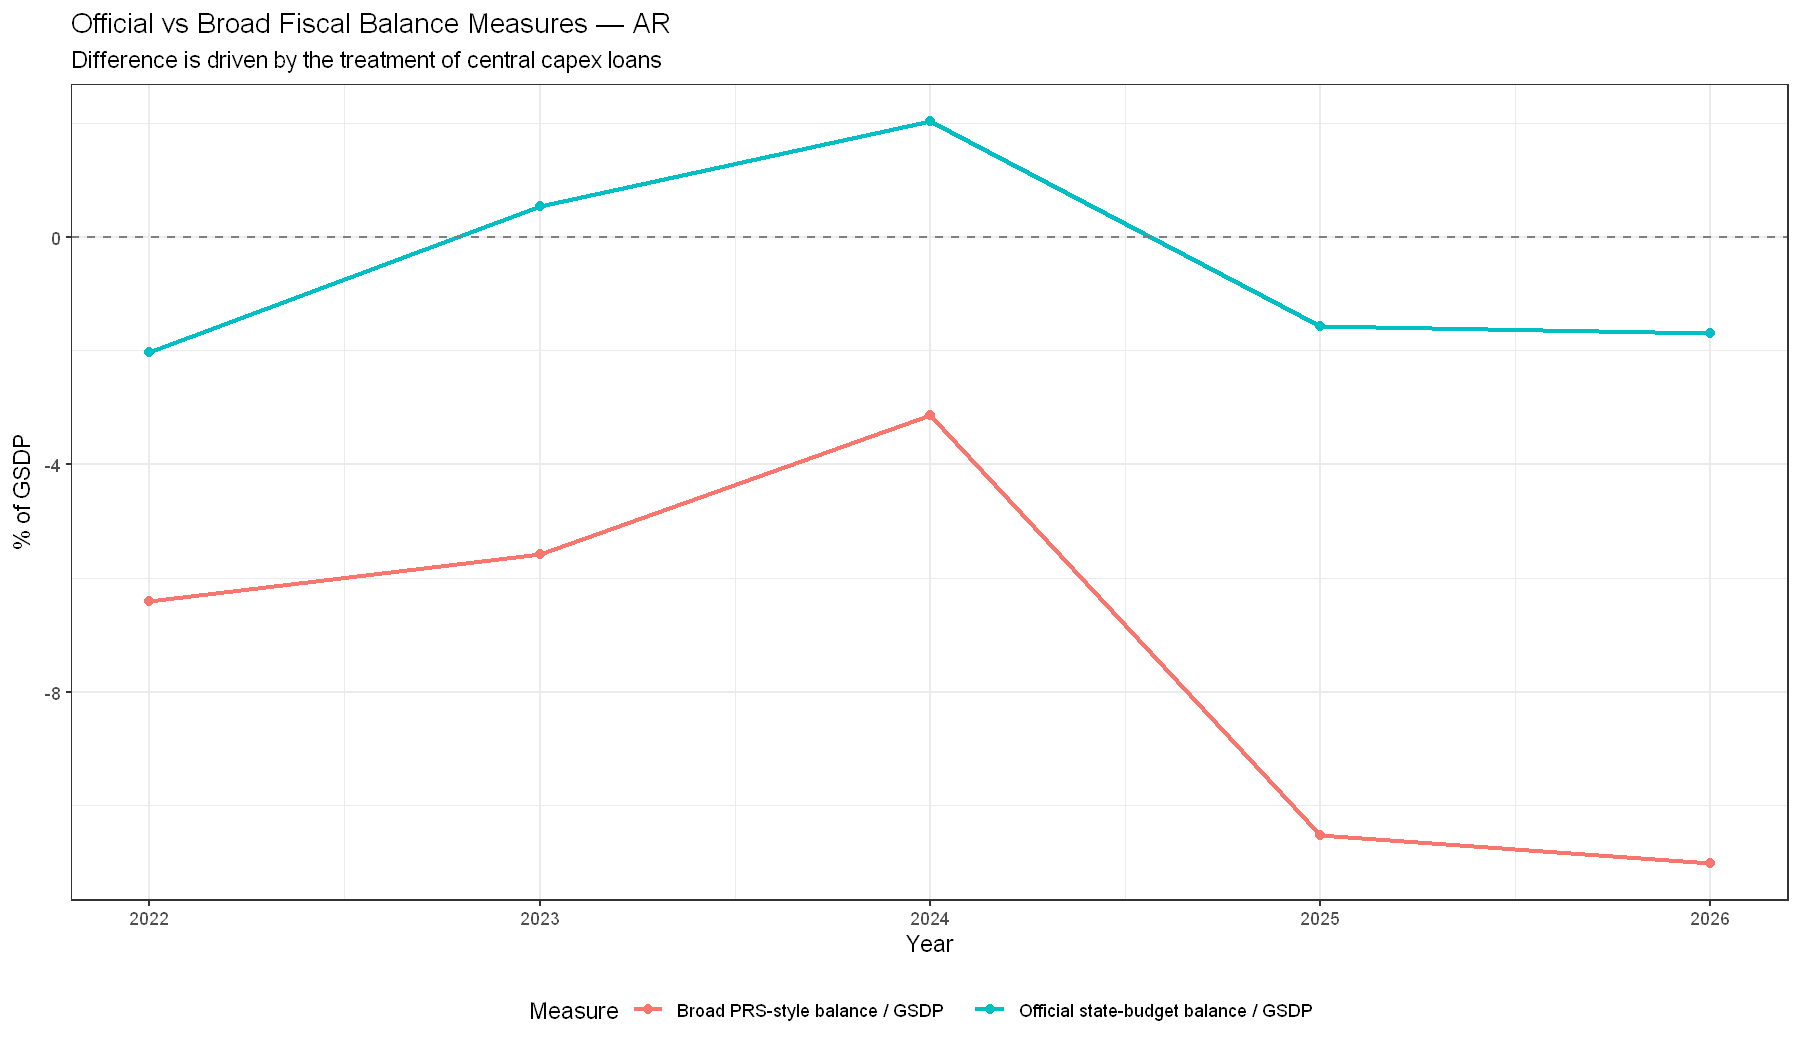

In [60]:
recon_plot_df <- proj2 %>%
  select(NumYear, OfficialFiscalBalance_GSDP, BroadFiscalBalance_GSDP) %>%
  pivot_longer(-NumYear, names_to = 'Measure', values_to = 'Ratio') %>%
  mutate(Measure = recode(Measure,
    OfficialFiscalBalance_GSDP = 'Official state-budget balance / GSDP',
    BroadFiscalBalance_GSDP = 'Broad PRS-style balance / GSDP'))

p12 <- ggplot(recon_plot_df, aes(x = NumYear, y = Ratio, color = Measure)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey50') +
  labs(title = 'Official vs Broad Fiscal Balance Measures - AR', subtitle = 'Difference is driven by the treatment of central capex loans', x = 'Year', y = '% of GSDP', color = 'Measure') +
  theme_bw() + theme(legend.position = 'bottom')

ggsave(file.path(FIG_DIR, 'fig17_project2_deficit_reconciliation.png'), p12, width = 10, height = 6, dpi = 300)
cat('Figure 12 saved:', file.exists(file.path(FIG_DIR, 'fig17_project2_deficit_reconciliation.png')), '
')
print(head(recon_plot_df))
print(dim(recon_plot_df))
str(recon_plot_df)
p12


### Figure 13 - Own Revenue vs Central Transfers (Project 2 Window)


Figure 13 saved: TRUE 


# A tibble: 10 × 3
   NumYear Component          Crore
     <dbl> <chr>              <dbl>
 1    2022 Own revenue        3255.
 2    2022 Central transfers 20533.
 3    2023 Own revenue        3699.
 4    2023 Central transfers 23742.
 5    2024 Own revenue        4007.
 6    2024 Central transfers 29540.
 7    2025 Own revenue        4608.
 8    2025 Central transfers 29936.
 9    2026 Own revenue        5208 
10    2026 Central transfers 25525.


[1] 10  3


tibble [10 × 3] (S3: tbl_df/tbl/data.frame)
 $ NumYear  : num [1:10] 2022 2022 2023 2023 2024 ...
 $ Component: chr [1:10] "Own revenue" "Central transfers" "Own revenue" "Central transfers" ...
 $ Crore    : num [1:10] 3255 20533 3699 23742 4007 ...


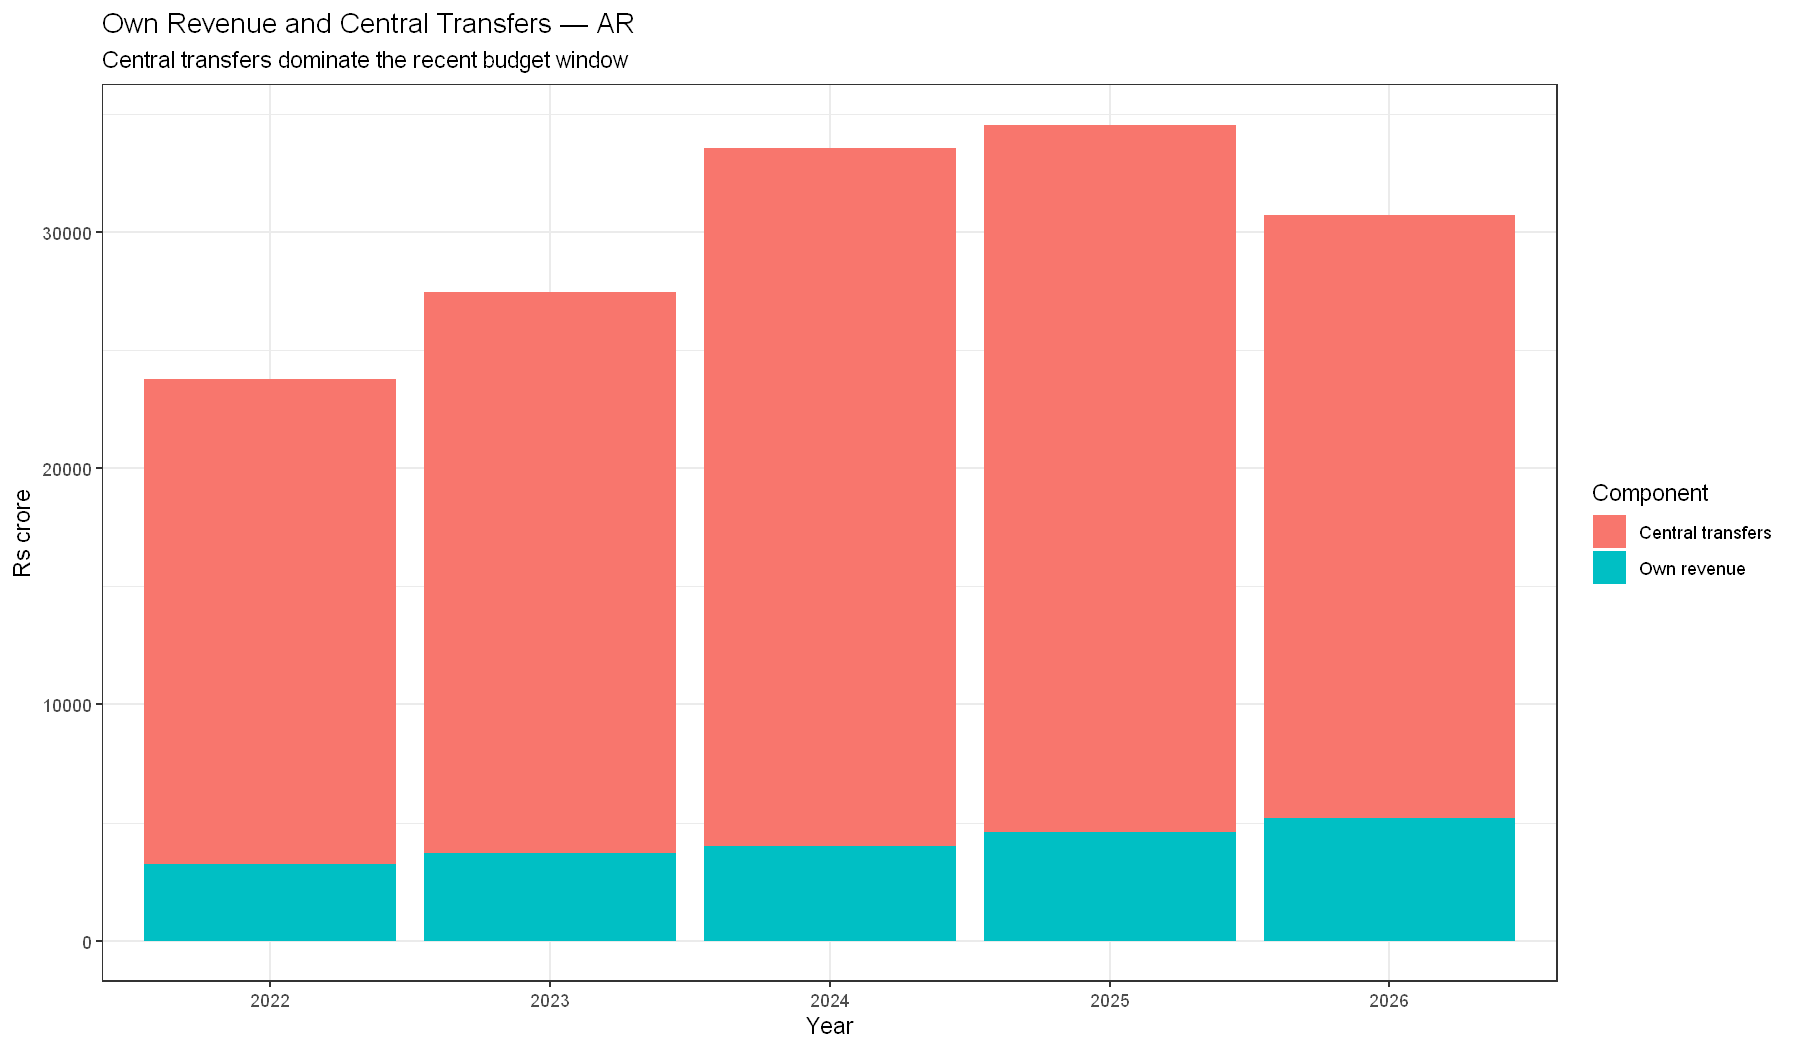

In [61]:
rev_mix_df <- ext_fiscal %>%
  filter(NumYear %in% 2022:2026) %>%
  select(NumYear, OwnRev, CentralTransfers) %>%
  pivot_longer(-NumYear, names_to = 'Component', values_to = 'Crore') %>%
  mutate(Component = recode(Component, OwnRev = 'Own revenue', CentralTransfers = 'Central transfers'))

p13 <- ggplot(rev_mix_df, aes(x = factor(NumYear), y = Crore, fill = Component)) +
  geom_col(position = 'stack') +
  labs(title = 'Own Revenue and Central Transfers - AR', subtitle = 'Central transfers dominate the recent budget window', x = 'Year', y = 'Rs crore', fill = 'Component') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig18_project2_revenue_composition.png'), p13, width = 10, height = 6, dpi = 300)
cat('Figure 13 saved:', file.exists(file.path(FIG_DIR, 'fig18_project2_revenue_composition.png')), '
')
print(rev_mix_df)
print(dim(rev_mix_df))
str(rev_mix_df)
p13


## Step 32A - Project 2 Extension R Port
The following R cells reproduce the extension tables and figures inside the notebook. They keep the notebook as the source of truth for Project 2 computations, diagnostics, tables, and plots.

In [62]:

# Project 2 extension helpers: extraction, HTML tables, robust OLS, and MacKinnon diagnostics.
HEAD_TOTAL_REVENUE <- "Total: TOTAL REVENUE (I+II)"
HEAD_OWN_TAX <- "I.A: State's Own Tax Revenue (1 to 3)"
HEAD_OWN_NONTAX <- "II.C: State's Own Non-Tax Revenue (1 to 6)"
HEAD_CENTRAL_TAXES <- "I.B: Share in Central Taxes (i to ix)"
HEAD_GRANTS <- "II.D: Grants from the Centre (1 to 7)"
HEAD_CSS_GRANTS <- "II.D.3: Centrally Sponsored Schemes"
HEAD_FC_GRANTS <- "II.D.5: Finance Commission Grants"
HEAD_ARTICLE_275_GRANTS <- "II.D.6: Grants under proviso to Article 275(1) of the Constitution"
HEAD_OTHER_GRANTS <- "II.D.7: Other Grants"
HEAD_REV_EXP <- "Total: TOTAL EXPENDITURE (I+II+III)"
HEAD_INTEREST_EXP <- "II.C.2: Interest Payments (i to iv)"
HEAD_CAP_OUTLAY <- "I: Total Capital Outlay (1 + 2)"
HEAD_CAP_NET <- "Total$: TOTAL CAPITAL DISBURSEMENTS (Excluding Public Accounts)"
P2_STATES <- c("Arunachal Pradesh", "Assam", "Sikkim", "Himachal Pradesh", "Tripura", "Meghalaya")
P2_STATE_ABBR <- c("Arunachal Pradesh"="AR", "Assam"="AS", "Sikkim"="SK", "Himachal Pradesh"="HP", "Tripura"="TR", "Meghalaya"="MG")
p2_budget_dir <- file.path(DATA_DIR, "Project2_Budget_Documents")
p2_topup_csv <- file.path(p2_budget_dir, "project2_budget_reference_values.csv")
p2_prs_budget_html <- file.path(p2_budget_dir, "PRS_Arunachal_Budget_Analysis_2026_27.html")
p2_prs_16fc_html <- file.path(p2_budget_dir, "PRS_16th_Finance_Commission_Summary_2026_31.html")
p2_all_states_finance_file <- file.path(DATA_DIR, "ALL STATES FINANCE DATABASE.XLSX")
p2_backseries_file <- file.path(DATA_DIR, "GSDP_NSDP_India_1960_2025_BackSeries.xlsx")
p2_fiscal_start <- function(x) as.integer(substr(as.character(x), 1, 4))
p2_extract_head <- function(df, state_col, head, appendix=NULL, value_col="Account", state=NULL) {
  sub <- df[df[["Budget Head"]] == head, , drop=FALSE]
  if (!is.null(appendix)) sub <- sub[sub$Appendix == appendix, , drop=FALSE]
  if (!is.null(state)) sub <- sub[sub[[state_col]] == state, , drop=FALSE]
  out <- sub[, c(state_col, "Fiscal Year", value_col), drop=FALSE]
  out$NumYear <- p2_fiscal_start(out$`Fiscal Year`)
  names(out)[names(out) == value_col] <- head
  out
}
p2_load_gsdp_current <- function() {
  gsdp <- read_excel(p2_backseries_file, sheet="GSDP Curr (Rs Lakh)")
  names(gsdp)[1] <- "Year"
  gsdp <- gsdp[grepl("^\\d{4}-", as.character(gsdp$Year)), ]
  gsdp$NumYear <- p2_fiscal_start(gsdp$Year)
  gsdp %>% pivot_longer(cols=-c(Year, NumYear), names_to="State", values_to="GSDP_RsLakh") %>%
    mutate(State=trimws(as.character(State)), GSDP_RsLakh=as.numeric(GSDP_RsLakh), GSDP_Cr=GSDP_RsLakh/100) %>%
    filter(!is.na(GSDP_Cr)) %>% select(State, Year, NumYear, GSDP_Cr)
}
p2_ols_hc1 <- function(y, x) {
  X <- cbind(Intercept=1, x=x); beta <- as.numeric(solve(t(X)%*%X, t(X)%*%y)); resid <- as.numeric(y - X%*%beta)
  n <- length(y); k <- ncol(X); xtx_inv <- solve(t(X)%*%X); meat <- t(X)%*%diag(resid^2, nrow=n)%*%X * n/(n-k)
  vcov <- xtx_inv %*% meat %*% xtx_inv; se <- sqrt(diag(vcov)); tstat <- beta/se; pval <- 2*pnorm(abs(tstat), lower.tail=FALSE)
  pval[pval < 1e-16] <- 0
  r2 <- 1 - sum(resid^2)/sum((y-mean(y))^2)
  list(intercept=beta[1], slope=beta[2], intercept_se_hc1=se[1], slope_se_hc1=se[2], intercept_t=tstat[1], slope_t=tstat[2], intercept_p_norm=pval[1], slope_p_norm=pval[2], r2=r2, n=n)
}
p2_num <- function(value) {
  if (length(value)==0 || is.na(value)) return(NA_real_)
  text <- as.character(value); text <- gsub("\u00a0", "", text, fixed=TRUE); text <- gsub(",", "", text, fixed=TRUE); text <- gsub("%", "", text, fixed=TRUE); text <- trimws(text)
  if (text %in% c("", "-", "NA", "nan")) return(NA_real_)
  as.numeric(text)
}
p2_html_tables <- function(path) {
  doc <- xml2::read_html(path); tabs <- xml2::xml_find_all(doc, ".//table")
  lapply(tabs, function(tab) {
    rows <- xml2::xml_find_all(tab, ".//tr")
    row_vals <- lapply(rows, function(r) trimws(xml2::xml_text(xml2::xml_find_all(r, "./th|./td"))))
    maxc <- max(lengths(row_vals), 0)
    mat <- do.call(rbind, lapply(row_vals, function(x) { length(x) <- maxc; x }))
    as.data.frame(mat, stringsAsFactors=FALSE)
  })
}
p2_table_with_header <- function(tbl) { names(tbl) <- as.character(unlist(tbl[1, ])); tbl[-1, , drop=FALSE] }
p2_polyval <- function(coef, x) sum(coef * x^(seq_along(coef)-1))
p2_tau_maxs <- list(n=c(Inf,1.51), c=c(2.74,0.92), ct=c(0.70,0.63))
p2_tau_mins <- list(n=c(-19.04,-19.62), c=c(-18.83,-18.86), ct=c(-16.18,-21.15))
p2_tau_stars <- list(n=c(-1.04,-1.53), c=c(-1.61,-2.62), ct=c(-2.89,-3.19))
p2_tau_smallps <- list(n=rbind(c(0.6344,1.2378,0.032496), c(1.9129,1.3857,0.035322)), c=rbind(c(2.1659,1.4412,0.038269), c(2.9200,1.5012,0.039796)), ct=rbind(c(3.2512,1.6047,0.049588), c(3.6646,1.5419,0.036448)))
p2_tau_largeps <- list(n=rbind(c(0.4797,0.93557,-0.06999,0.033066), c(1.5578,0.8558,-0.2083,-0.033549)), c=rbind(c(1.7339,0.93202,-0.12745,-0.010368), c(2.1945,0.64695,-0.29198,-0.042377)), ct=rbind(c(2.5261,0.61654,-0.37956,-0.060285), c(2.8500,0.5272,-0.36622,-0.051695)))
p2_make_tau <- function(vals, N) {
  mat <- matrix(vals, ncol=4, byrow=TRUE)
  arr <- array(NA_real_, dim=c(N, 3, 4))
  for (i in seq_len(N)) arr[i,,] <- mat[((i-1)*3+1):(i*3), , drop=FALSE]
  arr
}
p2_tau2010 <- list(
  n=p2_make_tau(c(-2.56574,-2.2358,-3.627,0, -1.94100,-0.2686,-3.365,31.223, -1.61682,0.2656,-2.714,25.364), 1),
  c=p2_make_tau(c(-3.43035,-6.5393,-16.786,-79.433, -2.86154,-2.8903,-4.234,-40.040, -2.56677,-1.5384,-2.809,0, -3.89644,-10.9519,-33.527,0, -3.33613,-6.1101,-6.823,0, -3.04445,-4.2412,-2.720,0), 2),
  ct=p2_make_tau(c(-3.95877,-9.0531,-28.428,-134.155, -3.41049,-4.3904,-9.036,-45.374, -3.12705,-2.5856,-3.925,-22.380, -4.32762,-15.4387,-35.679,0, -3.78057,-9.5106,-12.074,0, -3.49631,-7.0815,-7.538,21.892), 2)
)
p2_mackinnonp <- function(teststat, regression="c", N=1) {
  if (teststat > p2_tau_maxs[[regression]][N]) return(1.0)
  if (teststat < p2_tau_mins[[regression]][N]) return(0.0)
  coef <- if (teststat <= p2_tau_stars[[regression]][N]) p2_tau_smallps[[regression]][N, ] else p2_tau_largeps[[regression]][N, ]
  pnorm(p2_polyval(coef, teststat))
}
p2_mackinnoncrit <- function(N=1, regression="c", nobs=Inf) {
  tau <- p2_tau2010[[regression]]
  if (is.infinite(nobs)) return(tau[N,,1])
  apply(tau[N,,,drop=FALSE][1,,,drop=FALSE], 2, function(coef) p2_polyval(coef, 1/nobs))
}
p2_adf_fit_for_lag <- function(y, lag, regression="c") {
  y <- as.numeric(y[!is.na(y)]); n <- length(y); dy <- diff(y); j <- (lag+1):(n-1); response <- dy[j]; y_lag <- y[j]
  X <- matrix(y_lag, ncol=1); colnames(X) <- "y_lag"
  if (lag > 0) { lagged <- sapply(1:lag, function(k) dy[j-k]); if (lag==1) lagged <- matrix(lagged, ncol=1); colnames(lagged) <- paste0("dy_lag", 1:lag); X <- cbind(X, lagged) }
  if (regression=="c") X <- cbind(const=1, X)
  if (regression=="ct") X <- cbind(const=1, trend=seq_along(response), X)
  fit <- lm.fit(X, response); resid <- fit$residuals; nobs <- length(response); k <- ncol(X); rss <- sum(resid^2); sigma2 <- rss/(nobs-k)
  vcov <- sigma2 * solve(t(X)%*%X); beta <- fit$coefficients; se <- sqrt(diag(vcov)); y_idx <- which(colnames(X)=="y_lag")
  aic <- nobs * (log(2*pi) + 1 + log(rss/nobs)) + 2*k
  list(stat=as.numeric(beta[y_idx]/se[y_idx]), aic=aic, nobs=nobs, k=k, lag=lag)
}
p2_adf_fit_for_lag_select <- function(y, lag, maxlag, regression="c") {
  y <- as.numeric(y[!is.na(y)]); n <- length(y); dy <- diff(y); j <- (maxlag+1):(n-1); response <- dy[j]; y_lag <- y[j]
  X <- matrix(y_lag, ncol=1); colnames(X) <- "y_lag"
  if (lag > 0) { lagged <- sapply(1:lag, function(k) dy[j-k]); if (lag==1) lagged <- matrix(lagged, ncol=1); colnames(lagged) <- paste0("dy_lag", 1:lag); X <- cbind(X, lagged) }
  if (regression=="c") X <- cbind(const=1, X)
  if (regression=="ct") X <- cbind(const=1, trend=seq_along(response), X)
  fit <- lm.fit(X, response); resid <- fit$residuals; nobs <- length(response); k <- ncol(X); rss <- sum(resid^2)
  aic <- nobs * (log(2*pi) + 1 + log(rss/nobs)) + 2*k
  list(aic=aic, lag=lag)
}
p2_adf_test <- function(values, regression="c", maxlag=NULL) {
  y <- as.numeric(values[!is.na(values)]); n <- length(y); ntrend <- switch(regression, n=0, c=1, ct=2)
  if (is.null(maxlag)) { maxlag <- ceiling(12 * (n/100)^0.25); maxlag <- min(maxlag, floor(n/2 - ntrend - 1)) }
  select_fits <- lapply(0:maxlag, function(lag) p2_adf_fit_for_lag_select(y, lag, maxlag, regression))
  bestlag <- select_fits[[which.min(sapply(select_fits, `[[`, "aic"))]]$lag
  chosen <- p2_adf_fit_for_lag(y, bestlag, regression)
  crit <- p2_mackinnoncrit(N=1, regression=regression, nobs=chosen$nobs); pval <- p2_mackinnonp(chosen$stat, regression=regression, N=1)
  list(statistic=chosen$stat, p.value=pval, used.lag=chosen$lag, nobs=chosen$nobs, critical=crit, reject5=chosen$stat < crit[2])
}
p2_adf_row <- function(label, values, regression) {
  res <- p2_adf_test(values, regression=regression)
  data.frame(Test="ADF", Series=label, DeterministicTerms=regression, TestStatistic=res$statistic, PValue=res$p.value, UsedLag=res$used.lag, Nobs=res$nobs, Critical_1pct=res$critical[1], Critical_5pct=res$critical[2], Critical_10pct=res$critical[3], RejectAt5Pct=ifelse(res$reject5,"True","False"), Interpretation=ifelse(res$reject5,"Reject unit root at 5%","Do not reject unit root at 5%"), stringsAsFactors=FALSE)
}


In [63]:

# Project 2 extension routes 1-4: buoyancy, transfer shock, cross-state comparison, and long-run indicators.
sf_ar_p2 <- read_excel(file.path(DATA_DIR, "State Finances - Arunachal.XLSX"), sheet="Arunachal")
sf_ar_p2$Account <- as.numeric(sf_ar_p2$Account); sf_ar_p2$Revised <- as.numeric(sf_ar_p2$Revised); sf_ar_p2$Budget <- as.numeric(sf_ar_p2$Budget); sf_ar_p2$NumYear <- p2_fiscal_start(sf_ar_p2$`Fiscal Year`)
all_fin_p2 <- read_excel(p2_all_states_finance_file, sheet="Data")
all_fin_p2$Account <- as.numeric(all_fin_p2$Account); all_fin_p2$Revised <- as.numeric(all_fin_p2$Revised); all_fin_p2$Budget <- as.numeric(all_fin_p2$Budget); all_fin_p2$NumYear <- p2_fiscal_start(all_fin_p2$`Fiscal Year`)
gsdp_current_p2 <- p2_load_gsdp_current()
topup_p2 <- read.csv(p2_topup_csv, stringsAsFactors=FALSE)

own_tax_p2 <- p2_extract_head(sf_ar_p2, "State", HEAD_OWN_TAX, "Appendix-1", "Account", "Arunachal Pradesh") %>% rename(OwnTax_Cr=all_of(HEAD_OWN_TAX))
ar_gsdp_p2 <- gsdp_current_p2 %>% filter(State=="Arunachal Pradesh") %>% select(NumYear, Year, GSDP_Cr)
reg_data_p2 <- own_tax_p2 %>% inner_join(ar_gsdp_p2, by="NumYear") %>% filter(OwnTax_Cr>0, GSDP_Cr>0, NumYear<=2023) %>% mutate(FiscalYear=fy_label(NumYear), LogOwnTax=log(OwnTax_Cr), LogGSDP=log(GSDP_Cr), OwnTax_GSDP=OwnTax_Cr/GSDP_Cr*100)
fit_p2 <- p2_ols_hc1(reg_data_p2$LogOwnTax, reg_data_p2$LogGSDP)
reg_table_p2 <- data.frame(Variable=c("log(GSDP)", "Intercept"), Coefficient=c(fit_p2$slope, fit_p2$intercept), HC1_SE=c(fit_p2$slope_se_hc1, fit_p2$intercept_se_hc1), t_stat=c(fit_p2$slope_t, fit_p2$intercept_t), p_value_norm=c(fit_p2$slope_p_norm, fit_p2$intercept_p_norm), N=fit_p2$n, R2=fit_p2$r2, Sample=paste0(reg_data_p2$FiscalYear[1], " to ", reg_data_p2$FiscalYear[nrow(reg_data_p2)]), stringsAsFactors=FALSE)
reg_data_p2 <- reg_data_p2 %>% select(State, `Fiscal Year`, OwnTax_Cr, NumYear, Year, GSDP_Cr, FiscalYear, LogOwnTax, LogGSDP, OwnTax_GSDP)
p19 <- ggplot(reg_data_p2, aes(x=LogGSDP, y=LogOwnTax)) + geom_point(color="#2f6f73", size=2.3) + geom_abline(intercept=fit_p2$intercept, slope=fit_p2$slope, color="#b3432f", linewidth=0.9) + labs(title="Own-tax buoyancy in Arunachal Pradesh", x="log current-price GSDP", y="log own tax revenue") + theme_minimal(base_size=12) + theme(panel.grid.minor=element_blank())
ggsave(file.path(FIG_DIR, "fig19_project2_tax_buoyancy.png"), p19, width=10, height=6, dpi=300)

base_2026 <- topup_p2[topup_p2$NumYear==2026, ][1,]
central_taxes_after <- 20665.0; share_before <- 1.76; share_after <- 1.35
central_taxes_before <- central_taxes_after * (share_before/share_after); full_loss <- central_taxes_before - central_taxes_after
scenario_df <- data.frame(Scenario=c("No share cut: 15th FC share retained", "Half of share-loss shock", "Full 16th FC share-loss shock", "Stress: 125 percent of share-loss shock"), shock_frac=c(0,0.5,1,1.25), stringsAsFactors=FALSE)
sim_table_p2 <- scenario_df %>% mutate(loss=full_loss*shock_frac, DevolutionSharePct=share_before-(share_before-share_after)*shock_frac, CentralTaxDevolutionCr=central_taxes_before-loss, RevenueReceiptsCr=base_2026$RevenueReceiptsCr+(CentralTaxDevolutionCr-central_taxes_after), RevenueBalanceCr=RevenueReceiptsCr-base_2026$RevenueExpenditureCr, RevenueBalance_GSDP=RevenueBalanceCr/base_2026$OfficialBudgetGSDPCr*100, OfficialFiscalDeficitCr=base_2026$OfficialFiscalDeficitCr+loss-full_loss, OfficialFiscalDeficit_GSDP=OfficialFiscalDeficitCr/base_2026$OfficialBudgetGSDPCr*100, BroadFiscalDeficitCr=base_2026$BroadFiscalDeficitCr+loss-full_loss, BroadFiscalDeficit_GSDP=BroadFiscalDeficitCr/base_2026$OfficialBudgetGSDPCr*100, RevenueLossVsNoCutCr=loss) %>% select(-shock_frac, -loss)
shock_plot_df <- sim_table_p2 %>% filter(Scenario %in% c("No share cut: 15th FC share retained", "Full 16th FC share-loss shock")) %>% mutate(ScenarioLabel=c("15th FC share retained", "16th FC share")) %>% select(ScenarioLabel, RevenueBalance_GSDP, OfficialFiscalDeficit_GSDP) %>% pivot_longer(cols=c(RevenueBalance_GSDP, OfficialFiscalDeficit_GSDP), names_to="Measure", values_to="Value") %>% mutate(Measure=recode(Measure, RevenueBalance_GSDP="Revenue balance / GSDP", OfficialFiscalDeficit_GSDP="Official fiscal deficit / GSDP"))
p20 <- ggplot(shock_plot_df, aes(x=ScenarioLabel, y=Value, fill=Measure)) + geom_col(position=position_dodge(width=0.75), width=0.65) + geom_hline(yintercept=0, color="black", linewidth=0.3) + scale_fill_manual(values=c("Revenue balance / GSDP"="#2f6f73", "Official fiscal deficit / GSDP"="#b3432f")) + labs(title="Fiscal effect of Arunachal Pradesh's devolution-share reduction", x=NULL, y="Percent of GSDP", fill=NULL) + theme_minimal(base_size=12) + theme(panel.grid.minor=element_blank())
ggsave(file.path(FIG_DIR, "fig20_project2_transfer_shock.png"), p20, width=10, height=6, dpi=300)

comp_frames <- list(
 p2_extract_head(all_fin_p2,"State/UT",HEAD_TOTAL_REVENUE,"Appendix-1","Account") %>% rename(State=`State/UT`, TotalRevenueCr=all_of(HEAD_TOTAL_REVENUE)),
 p2_extract_head(all_fin_p2,"State/UT",HEAD_CENTRAL_TAXES,"Appendix-1","Account") %>% rename(State=`State/UT`, CentralTaxesCr=all_of(HEAD_CENTRAL_TAXES)),
 p2_extract_head(all_fin_p2,"State/UT",HEAD_GRANTS,"Appendix-1","Account") %>% rename(State=`State/UT`, GrantsCr=all_of(HEAD_GRANTS)),
 p2_extract_head(all_fin_p2,"State/UT",HEAD_OWN_TAX,"Appendix-1","Account") %>% rename(State=`State/UT`, OwnTaxCr=all_of(HEAD_OWN_TAX)),
 p2_extract_head(all_fin_p2,"State/UT",HEAD_OWN_NONTAX,"Appendix-1","Account") %>% rename(State=`State/UT`, NonTaxCr=all_of(HEAD_OWN_NONTAX)),
 p2_extract_head(all_fin_p2,"State/UT",HEAD_REV_EXP,"Appendix-2","Account") %>% rename(State=`State/UT`, RevenueExpenditureCr=all_of(HEAD_REV_EXP)),
 p2_extract_head(all_fin_p2,"State/UT",HEAD_CAP_OUTLAY,"Appendix-4","Account") %>% rename(State=`State/UT`, CapitalOutlayCr=all_of(HEAD_CAP_OUTLAY)),
 p2_extract_head(all_fin_p2,"State/UT",HEAD_CAP_NET,"Appendix-4","Account") %>% rename(State=`State/UT`, NetCapitalExpenditureCr=all_of(HEAD_CAP_NET))
)
comp_table_p2 <- Reduce(function(x,y) full_join(x,y,by=c("State","Fiscal Year","NumYear")), comp_frames) %>% filter(State %in% P2_STATES, NumYear==2023) %>% mutate(CentralTransfersCr=CentralTaxesCr+GrantsCr, OwnRevenueCr=OwnTaxCr+NonTaxCr, RevenueBalanceCr=TotalRevenueCr-RevenueExpenditureCr, FiscalDependenceRatio=CentralTransfersCr/TotalRevenueCr*100, OwnRevenue_RevExp=OwnRevenueCr/RevenueExpenditureCr*100, CapitalOutlayRatio=CapitalOutlayCr/(RevenueExpenditureCr+NetCapitalExpenditureCr)*100) %>% left_join(gsdp_current_p2 %>% filter(NumYear==2023) %>% select(State,GSDP_Cr), by="State") %>% mutate(RevenueBalance_GSDP=RevenueBalanceCr/GSDP_Cr*100, StateCode=unname(P2_STATE_ABBR[State]), FiscalDependenceRank_desc=as.integer(rank(-FiscalDependenceRatio, ties.method="min"))) %>% arrange(desc(FiscalDependenceRatio))
comp_plot <- comp_table_p2 %>% select(StateCode, FiscalDependenceRatio, OwnRevenue_RevExp) %>% pivot_longer(cols=c(FiscalDependenceRatio, OwnRevenue_RevExp), names_to="Measure", values_to="Value") %>% mutate(Measure=recode(Measure, FiscalDependenceRatio="Central transfers / revenue", OwnRevenue_RevExp="Own revenue / revenue exp."))
p21 <- ggplot(comp_plot, aes(x=factor(StateCode, levels=comp_table_p2$StateCode), y=Value, fill=Measure)) + geom_col(position=position_dodge(width=0.75), width=0.65) + scale_fill_manual(values=c("Central transfers / revenue"="#2f6f73", "Own revenue / revenue exp."="#b3432f")) + labs(title="Fiscal autonomy across comparator states, 2023-24 accounts", x=NULL, y="Percent", fill=NULL) + theme_minimal(base_size=12) + theme(panel.grid.minor=element_blank())
ggsave(file.path(FIG_DIR, "fig21_project2_cross_state_comparison.png"), p21, width=10, height=6, dpi=300)

core_frames <- list(
 p2_extract_head(sf_ar_p2,"State",HEAD_TOTAL_REVENUE,"Appendix-1","Account","Arunachal Pradesh") %>% rename(RevenueReceiptsCr=all_of(HEAD_TOTAL_REVENUE)),
 p2_extract_head(sf_ar_p2,"State",HEAD_REV_EXP,"Appendix-2","Account","Arunachal Pradesh") %>% rename(RevenueExpenditureCr=all_of(HEAD_REV_EXP)),
 p2_extract_head(sf_ar_p2,"State",HEAD_CAP_NET,"Appendix-4","Account","Arunachal Pradesh") %>% rename(NetCapitalExpenditureCr=all_of(HEAD_CAP_NET)),
 p2_extract_head(sf_ar_p2,"State",HEAD_INTEREST_EXP,"Appendix-2","Account","Arunachal Pradesh") %>% rename(InterestPaymentsCr=all_of(HEAD_INTEREST_EXP))
)
longrun_core_p2 <- Reduce(function(x,y) full_join(x,y,by=c("State","Fiscal Year","NumYear")), core_frames) %>% filter(NumYear<=2023) %>% left_join(gsdp_current_p2 %>% filter(State=="Arunachal Pradesh") %>% select(NumYear, Year, GSDP_Cr), by="NumYear") %>% mutate(FY_label=fy_label(NumYear), SourceDoc="RBI State Finances database and current-price GSDP workbook", RevenueBalanceCr=RevenueReceiptsCr-RevenueExpenditureCr, BroadFiscalBalanceCr=RevenueReceiptsCr-(RevenueExpenditureCr+NetCapitalExpenditureCr), BroadPrimaryBalanceCr=BroadFiscalBalanceCr+InterestPaymentsCr)
top_core_p2 <- topup_p2 %>% filter(NumYear>=2024) %>% transmute(`Fiscal Year`=FY_label, NumYear, RevenueReceiptsCr, RevenueExpenditureCr, NetCapitalExpenditureCr, InterestPaymentsCr, GSDP_Cr=OfficialBudgetGSDPCr, FY_label, SourceDoc="Official Arunachal 2026-27 budget packet and PRS reconciliation", RevenueBalanceCr, BroadFiscalBalanceCr=-BroadFiscalDeficitCr, BroadPrimaryBalanceCr=-BroadFiscalDeficitCr+InterestPaymentsCr)
longrun_core_p2 <- bind_rows(longrun_core_p2, top_core_p2) %>% arrange(NumYear) %>% mutate(RevenueBalance_GSDP=RevenueBalanceCr/GSDP_Cr*100, BroadFiscalBalance_GSDP=BroadFiscalBalanceCr/GSDP_Cr*100, BroadPrimaryBalance_GSDP=BroadPrimaryBalanceCr/GSDP_Cr*100, Interest_RevExp=InterestPaymentsCr/RevenueExpenditureCr*100)
longrun_table_p2 <- longrun_core_p2 %>% select(FY_label, NumYear, SourceDoc, GSDP_Cr, RevenueBalance_GSDP, BroadFiscalBalance_GSDP, BroadPrimaryBalance_GSDP, Interest_RevExp, RevenueReceiptsCr, RevenueExpenditureCr, InterestPaymentsCr)
longrun_plot <- longrun_table_p2 %>% select(NumYear, RevenueBalance_GSDP, BroadFiscalBalance_GSDP, BroadPrimaryBalance_GSDP, Interest_RevExp) %>% pivot_longer(cols=-NumYear, names_to="Measure", values_to="Value") %>% mutate(Measure=recode(Measure, RevenueBalance_GSDP="Revenue balance / GSDP", BroadFiscalBalance_GSDP="Broad fiscal balance / GSDP", BroadPrimaryBalance_GSDP="Broad primary balance / GSDP", Interest_RevExp="Interest / revenue expenditure"))
p22 <- ggplot(longrun_plot, aes(x=NumYear, y=Value)) + geom_line(color="#2f6f73", linewidth=0.8) + geom_hline(yintercept=0, color="black", linewidth=0.25, alpha=0.7) + facet_wrap(~Measure, ncol=2, scales="free_y") + labs(title="Long-run fiscal structure of Arunachal Pradesh, 1990-91 to 2026-27", x="Fiscal year start", y="Percent") + theme_minimal(base_size=12) + theme(panel.grid.minor=element_blank())
ggsave(file.path(FIG_DIR, "fig22_project2_longrun_core_indicators.png"), p22, width=12, height=8, dpi=300)


In [64]:

# Project 2 extension routes 5-6: buoyancy diagnostics and committed-expenditure trajectory.
ts_tests_p2 <- bind_rows(
  p2_adf_row("log own tax revenue", reg_data_p2$LogOwnTax, "ct"),
  p2_adf_row("log GSDP", reg_data_p2$LogGSDP, "ct"),
  p2_adf_row("d.log own tax revenue", diff(reg_data_p2$LogOwnTax), "c"),
  p2_adf_row("d.log GSDP", diff(reg_data_p2$LogGSDP), "c")
)
eg_fit <- lm(LogOwnTax ~ LogGSDP, data=reg_data_p2); eg_resid <- residuals(eg_fit); eg_adf <- p2_adf_test(eg_resid, regression="n"); eg_crit <- p2_mackinnoncrit(N=2, regression="c", nobs=nrow(reg_data_p2)-1)
ts_tests_p2 <- bind_rows(ts_tests_p2, p2_adf_row("OLS residual from log own tax on log GSDP", eg_resid, "n"), data.frame(Test="Engle-Granger", Series="log own tax revenue and log GSDP", DeterministicTerms="c", TestStatistic=eg_adf$statistic, PValue=p2_mackinnonp(eg_adf$statistic, regression="c", N=2), UsedLag=NA_real_, Nobs=nrow(reg_data_p2), Critical_1pct=eg_crit[1], Critical_5pct=eg_crit[2], Critical_10pct=eg_crit[3], RejectAt5Pct=ifelse(eg_adf$statistic < eg_crit[2], "True", "False"), Interpretation=ifelse(eg_adf$statistic < eg_crit[2], "Reject no cointegration at 5%", "Do not reject no cointegration at 5%"), stringsAsFactors=FALSE))

prs_budget_tables <- p2_html_tables(p2_prs_budget_html)
committed_raw <- p2_table_with_header(prs_budget_tables[[6]])
receipts_raw <- p2_table_with_header(prs_budget_tables[[8]])
committed_columns <- c("2024-25 Actuals", "2025-26 Budgeted", "2025-26 Revised", "2026-27 Budgeted")
committed_labels <- c("2024-25 A", "2025-26 BE", "2025-26 RE", "2026-27 BE")
committed_rows <- lapply(seq_along(committed_columns), function(i) {
  col <- committed_columns[i]; label <- committed_labels[i]
  values <- setNames(sapply(committed_raw[[col]], p2_num), committed_raw$Items)
  rev_receipts <- p2_num(receipts_raw[receipts_raw$Items == "Revenue Receipts", col][[1]])
  data.frame(Period=label, SourceDoc="PRS Arunachal Pradesh Budget Analysis 2026-27", RevenueReceiptsCr=rev_receipts, SalaryCr=values[["Salaries"]], PensionCr=values[["Pension"]], InterestCr=values[["Interest payment"]], TotalCommittedCr=values[["Total"]], stringsAsFactors=FALSE)
})
committed_table_p2 <- bind_rows(committed_rows) %>% mutate(Salary_RevReceipt=SalaryCr/RevenueReceiptsCr*100, Pension_RevReceipt=PensionCr/RevenueReceiptsCr*100, Interest_RevReceipt=InterestCr/RevenueReceiptsCr*100, TotalCommitted_RevReceipt=TotalCommittedCr/RevenueReceiptsCr*100)
committed_plot <- committed_table_p2 %>% select(Period, Salary_RevReceipt, Pension_RevReceipt, Interest_RevReceipt, TotalCommitted_RevReceipt) %>% pivot_longer(cols=c(Salary_RevReceipt, Pension_RevReceipt, Interest_RevReceipt), names_to="Component", values_to="Value") %>% mutate(Component=recode(Component, Salary_RevReceipt="Salaries", Pension_RevReceipt="Pensions", Interest_RevReceipt="Interest"))
p23 <- ggplot(committed_plot, aes(x=Period, y=Value, fill=Component)) + geom_col(width=0.65) + geom_line(data=committed_table_p2, aes(x=Period, y=TotalCommitted_RevReceipt, group=1), inherit.aes=FALSE, color="black", linewidth=0.6) + geom_point(data=committed_table_p2, aes(x=Period, y=TotalCommitted_RevReceipt), inherit.aes=FALSE, color="black", size=2) + scale_fill_manual(values=c("Salaries"="#2f6f73", "Pensions"="#b3432f", "Interest"="#6b6f8a")) + labs(title="Committed expenditure pressure in Arunachal Pradesh", x=NULL, y="Percent of revenue receipts", fill=NULL) + theme_minimal(base_size=12) + theme(panel.grid.minor=element_blank())
ggsave(file.path(FIG_DIR, "fig23_project2_committed_expenditure_trajectory.png"), p23, width=10, height=6, dpi=300)


In [65]:

# Project 2 extension routes 7-8: transfer breakdown and 16th Finance Commission trajectory.
p2_extract_optional <- function(head, name, appendix="Appendix-1") {
  if (!any(sf_ar_p2$`Budget Head` == head, na.rm=TRUE)) return(data.frame(NumYear=integer()))
  tmp <- p2_extract_head(sf_ar_p2, "State", head, appendix, "Account", "Arunachal Pradesh")
  names(tmp)[names(tmp) == head] <- name
  tmp[, c("NumYear", name), drop=FALSE]
}
transfer_parts <- list(
  p2_extract_optional(HEAD_TOTAL_REVENUE, "TotalRev"), p2_extract_optional(HEAD_CENTRAL_TAXES, "CentralTaxes"), p2_extract_optional(HEAD_GRANTS, "Grants"), p2_extract_optional(HEAD_OWN_TAX, "OwnTax"), p2_extract_optional(HEAD_OWN_NONTAX, "NonTax"), p2_extract_optional(HEAD_REV_EXP, "RevExp", "Appendix-2"), p2_extract_optional(HEAD_CSS_GRANTS, "CSSGrants"), p2_extract_optional(HEAD_FC_GRANTS, "FinanceCommissionGrants"), p2_extract_optional(HEAD_ARTICLE_275_GRANTS, "Article275Grants"), p2_extract_optional(HEAD_OTHER_GRANTS, "OtherGrants")
)
transfer_table_p2 <- Reduce(function(x,y) full_join(x,y,by="NumYear"), transfer_parts) %>% filter(NumYear %in% c(2022, 2023)) %>% mutate(SourceDoc="RBI State Finances database accounts")
official_transfer_rows <- data.frame(NumYear=c(2024,2025,2026), TotalRev=c(30306.8496,34124.88,30733.46), CentralTaxes=c(22610.55,24475.0,20665.0), Grants=c(3828.6108,4971.97,4859.6), OwnTax=c(2820.0,3249.0,3634.0), NonTax=c(1048.0,1429.0,1574.0), RevExp=c(21710.0822,27133.4891,27061.6596), CSSGrants=c(3050.6081,4027.97,4200.0), FinanceCommissionGrants=c(408.5727,644.0,359.6), Article275Grants=c(100.3,0.0,0.0), OtherGrants=c(269.13,300.0,300.0), SourceDoc="Annual Financial Statement 2026-27 and PRS Budget Analysis", stringsAsFactors=FALSE)
transfer_table_p2 <- bind_rows(transfer_table_p2, official_transfer_rows) %>% arrange(NumYear) %>% mutate(Article275Grants=ifelse(is.na(Article275Grants),0,Article275Grants), OtherGrants=ifelse(is.na(OtherGrants),0,OtherGrants), CSSGrants=ifelse(is.na(CSSGrants),0,CSSGrants), FinanceCommissionGrants=ifelse(is.na(FinanceCommissionGrants),0,FinanceCommissionGrants), OwnRev=OwnTax+NonTax, OtherCentralGrants=pmax(Grants-CSSGrants-FinanceCommissionGrants,0), CentralTransfers=CentralTaxes+Grants, FiscalDependenceRatio=CentralTransfers/TotalRev*100, OwnRev_RevReceipt=OwnRev/TotalRev*100, OwnRev_RevExp=OwnRev/RevExp*100, OwnTax_OwnRev=OwnTax/OwnRev*100, FY_label=fy_label(NumYear))
transfer_plot <- transfer_table_p2 %>% select(FY_label, CentralTaxes, CSSGrants, FinanceCommissionGrants, OtherCentralGrants, OwnRev) %>% pivot_longer(cols=-FY_label, names_to="Component", values_to="Value") %>% mutate(Component=recode(Component, CentralTaxes="Tax devolution", CSSGrants="CSS grants", FinanceCommissionGrants="Finance Commission grants", OtherCentralGrants="Other grants", OwnRev="Own revenue"))
p24 <- ggplot(transfer_plot, aes(x=FY_label, y=Value, fill=Component)) + geom_col(width=0.65) + scale_fill_manual(values=c("Tax devolution"="#2f6f73", "CSS grants"="#b3432f", "Finance Commission grants"="#6b6f8a", "Other grants"="#c9a646", "Own revenue"="#7b9e87")) + labs(title="Composition of revenue receipts and central transfers", x=NULL, y="Rs crore", fill=NULL) + theme_minimal(base_size=12) + theme(panel.grid.minor=element_blank(), legend.position="bottom")
ggsave(file.path(FIG_DIR, "fig24_project2_transfer_breakdown.png"), p24, width=11, height=6, dpi=300)

prs_16fc_tables <- p2_html_tables(p2_prs_16fc_html)
shares_p2 <- p2_table_with_header(prs_16fc_tables[[4]])
grants_p2 <- prs_16fc_tables[[6]]; names(grants_p2) <- as.character(unlist(grants_p2[1, ])); grants_p2 <- grants_p2[-c(1,2), , drop=FALSE]
ar_share <- shares_p2[shares_p2$State == "Arunachal Pradesh", ][1,]
ar_grants <- grants_p2[trimws(grants_p2$State) == "Arunachal Pradesh", ][1,]
rural_grants <- sum(sapply(ar_grants[2:4], p2_num), na.rm=TRUE); urban_grants <- sum(sapply(ar_grants[5:7], p2_num), na.rm=TRUE); disaster_grants <- p2_num(ar_grants[[8]])
total_grants_2026_31 <- rural_grants + urban_grants + disaster_grants; annual_fc_grant <- total_grants_2026_31/5
base_non_fc_grants <- 4859.6 - 359.6; base_own_rev <- 3634.0 + 1574.0; base_rev_exp <- base_2026$RevenueExpenditureCr; base_gsdp <- base_2026$OfficialBudgetGSDPCr
fc_path_table_p2 <- bind_rows(lapply(0:4, function(i) {
  year <- 2026+i; central_taxes <- 20665.0*((1+0.08)^i); own_rev <- base_own_rev*((1+0.08)^i); non_fc_grants <- base_non_fc_grants
  revenue_receipts <- own_rev + central_taxes + non_fc_grants + annual_fc_grant; revenue_exp <- base_rev_exp*((1+0.08)^i); gsdp_val <- base_gsdp*((1+0.08)^i)
  data.frame(FY_label=fy_label(year), NumYear=year, Scenario="Illustrative 8 pct nominal devolution and expenditure growth", DevolutionShare_15FC=p2_num(ar_share[["15th FC (2021-26)"]]), DevolutionShare_16FC=p2_num(ar_share[["16th FC (2026-31)"]]), TaxDevolutionCr=central_taxes, AnnualFCGrantCr=annual_fc_grant, NonFCGrantsHeldAt2026Cr=non_fc_grants, OwnRevenueCr=own_rev, RevenueReceiptsCr=revenue_receipts, RevenueExpenditureCr=revenue_exp, RevenueBalanceCr=revenue_receipts-revenue_exp, RevenueBalance_GSDP=(revenue_receipts-revenue_exp)/gsdp_val*100, FCGrantTotal2026_31Cr=total_grants_2026_31, RuralLocalBodyGrant2026_31Cr=rural_grants, UrbanLocalBodyGrant2026_31Cr=urban_grants, DisasterGrant2026_31Cr=disaster_grants, stringsAsFactors=FALSE)
}))
fc_plot <- fc_path_table_p2 %>% select(FY_label, TaxDevolutionCr, AnnualFCGrantCr, RevenueBalanceCr) %>% pivot_longer(cols=c(TaxDevolutionCr, AnnualFCGrantCr), names_to="Component", values_to="Value") %>% mutate(Component=recode(Component, TaxDevolutionCr="Tax devolution", AnnualFCGrantCr="FC local/disaster grants"))
p25 <- ggplot(fc_plot, aes(x=FY_label, y=Value, fill=Component)) + geom_col(position=position_dodge(width=0.75), width=0.65) + geom_line(data=fc_path_table_p2, aes(x=FY_label, y=RevenueBalanceCr, group=1), inherit.aes=FALSE, color="black", linewidth=0.6) + geom_point(data=fc_path_table_p2, aes(x=FY_label, y=RevenueBalanceCr), inherit.aes=FALSE, color="black", size=2) + scale_fill_manual(values=c("Tax devolution"="#2f6f73", "FC local/disaster grants"="#b3432f")) + labs(title="Illustrative 16th Finance Commission transfer path", x=NULL, y="Rs crore", fill=NULL) + theme_minimal(base_size=12) + theme(panel.grid.minor=element_blank())
ggsave(file.path(FIG_DIR, "fig25_project2_16fc_transfer_trajectory.png"), p25, width=10, height=6, dpi=300)


In [66]:

# Project 2 extension diagnostics, CSV writes, and notebook-level reproducibility check.
account_years_ar <- sf_ar_p2 %>% group_by(`Fiscal Year`) %>% summarise(has_account=any(!is.na(Account)), .groups="drop") %>% filter(has_account)
diag_rows <- list(data.frame(Check="Arunachal RBI account coverage", Result=paste0(min(account_years_ar$`Fiscal Year`), " to ", max(account_years_ar$`Fiscal Year`)), Status="PASS", stringsAsFactors=FALSE))
for (head in c(HEAD_TOTAL_REVENUE, HEAD_OWN_TAX, HEAD_CENTRAL_TAXES, HEAD_GRANTS, HEAD_REV_EXP, HEAD_CAP_OUTLAY, HEAD_CAP_NET)) {
  exists_ar <- any(sf_ar_p2$`Budget Head` == head, na.rm=TRUE); exists_all <- any(all_fin_p2$`Budget Head` == head, na.rm=TRUE)
  diag_rows[[length(diag_rows)+1]] <- data.frame(Check=paste0("Budget head available: ", head), Result=paste0("AR=", exists_ar, "; all-state=", exists_all), Status=ifelse(exists_ar && exists_all, "PASS", "FAIL"), stringsAsFactors=FALSE)
}
g2026 <- topup_p2$OfficialBudgetGSDPCr[topup_p2$NumYear == 2026][1]
diag_rows[[length(diag_rows)+1]] <- data.frame(Check="2026-27 GSDP denominator", Result=sprintf("%.0f crore; cross-checked against Budget at a Glance text value 41,314 crore", g2026), Status=ifelse(abs(g2026-41314)<1e-6, "PASS", "REVIEW"), stringsAsFactors=FALSE)
gstates <- unique(gsdp_current_p2$State[gsdp_current_p2$NumYear == 2023]); missing_states <- setdiff(P2_STATES, gstates)
diag_rows[[length(diag_rows)+1]] <- data.frame(Check="Comparator GSDP coverage for 2023-24", Result=ifelse(length(missing_states)==0, "all six states available", paste0("missing=", paste(missing_states, collapse=","))), Status=ifelse(length(missing_states)==0, "PASS", "FAIL"), stringsAsFactors=FALSE)
diag_table_p2 <- bind_rows(diag_rows)

write.csv(reg_table_p2, file.path(TBL_DIR, "table23_project2_tax_buoyancy_regression.csv"), row.names=FALSE, na="")
write.csv(reg_data_p2, file.path(TBL_DIR, "table23a_project2_tax_buoyancy_data.csv"), row.names=FALSE, na="")
write.csv(sim_table_p2, file.path(TBL_DIR, "table24_project2_16fc_simulation.csv"), row.names=FALSE, na="")
write.csv(comp_table_p2, file.path(TBL_DIR, "table25_project2_cross_state_comparison.csv"), row.names=FALSE, na="")
write.csv(diag_table_p2, file.path(TBL_DIR, "table26_project2_extension_diagnostics.csv"), row.names=FALSE, na="")
write.csv(ts_tests_p2, file.path(TBL_DIR, "table27_project2_buoyancy_time_series_tests.csv"), row.names=FALSE, na="")
write.csv(longrun_table_p2, file.path(TBL_DIR, "table28_project2_longrun_core_indicators.csv"), row.names=FALSE, na="")
write.csv(committed_table_p2, file.path(TBL_DIR, "table29_project2_committed_expenditure_trajectory.csv"), row.names=FALSE, na="")
write.csv(transfer_table_p2, file.path(TBL_DIR, "table30_project2_transfer_breakdown.csv"), row.names=FALSE, na="")
write.csv(fc_path_table_p2, file.path(TBL_DIR, "table31_project2_16fc_transfer_trajectory.csv"), row.names=FALSE, na="")

cat("Project 2 extension tables and figures regenerated from R notebook cells.\n")
print(reg_table_p2); print(ts_tests_p2)
print(fc_path_table_p2[, c("FY_label", "TaxDevolutionCr", "AnnualFCGrantCr", "RevenueBalanceCr", "RevenueBalance_GSDP")])
print(transfer_table_p2[, c("FY_label", "FiscalDependenceRatio", "OwnRev_RevExp", "OwnTax_OwnRev", "CSSGrants", "FinanceCommissionGrants", "OtherCentralGrants")])
print(committed_table_p2[, c("Period", "TotalCommitted_RevReceipt", "Salary_RevReceipt", "Pension_RevReceipt", "Interest_RevReceipt")])
print(comp_table_p2[, c("StateCode", "State", "FiscalDependenceRatio", "OwnRevenue_RevExp", "RevenueBalance_GSDP", "CapitalOutlayRatio")])
print(diag_table_p2)

project2_required_tables <- file.path(TBL_DIR, c("table11_project2_fiscal_indicators.csv", "table18_project2_source_manifest.csv", "table19_project2_budget_topup.csv", "table20_project2_deficit_reconciliation.csv", "table21_project2_committed_expenditure_snapshot.csv", "table22_project2_transfer_snapshot.csv", "table23_project2_tax_buoyancy_regression.csv", "table23a_project2_tax_buoyancy_data.csv", "table24_project2_16fc_simulation.csv", "table25_project2_cross_state_comparison.csv", "table26_project2_extension_diagnostics.csv", "table27_project2_buoyancy_time_series_tests.csv", "table28_project2_longrun_core_indicators.csv", "table29_project2_committed_expenditure_trajectory.csv", "table30_project2_transfer_breakdown.csv", "table31_project2_16fc_transfer_trajectory.csv"))
project2_required_figures <- file.path(FIG_DIR, c("fig17_project2_deficit_reconciliation.png", "fig18_project2_revenue_composition.png", "fig19_project2_tax_buoyancy.png", "fig20_project2_transfer_shock.png", "fig21_project2_cross_state_comparison.png", "fig22_project2_longrun_core_indicators.png", "fig23_project2_committed_expenditure_trajectory.png", "fig24_project2_transfer_breakdown.png", "fig25_project2_16fc_transfer_trajectory.png"))
project2_repro_check <- data.frame(artifact=c(basename(project2_required_tables), basename(project2_required_figures)), type=c(rep("table", length(project2_required_tables)), rep("figure", length(project2_required_figures))), exists=file.exists(c(project2_required_tables, project2_required_figures)), stringsAsFactors=FALSE)
print(project2_repro_check)
if (!all(project2_repro_check$exists)) stop("Project 2 notebook reproducibility check failed: missing artifacts: ", paste(project2_repro_check$artifact[!project2_repro_check$exists], collapse=", "))
cat("Project 2 notebook reproducibility check passed: all final tables and figures exist.\n")


Project 2 extension tables and figures regenerated from R notebook cells.


           Variable Coefficient     HC1_SE    t_stat p_value_norm  N        R2
x         log(GSDP)    1.693769 0.03248816  52.13495            0 34 0.9877286
Intercept Intercept  -10.076294 0.28475769 -35.38550            0 34 0.9877286
                      Sample
x         1990-91 to 2023-24
Intercept 1990-91 to 2023-24


           Test                                    Series DeterministicTerms
1           ADF                       log own tax revenue                 ct
2           ADF                                  log GSDP                 ct
3           ADF                     d.log own tax revenue                  c
4           ADF                                d.log GSDP                  c
5           ADF OLS residual from log own tax on log GSDP                  n
6 Engle-Granger          log own tax revenue and log GSDP                  c
  TestStatistic       PValue UsedLag Nobs Critical_1pct Critical_5pct
1     -3.623979 2.787733e-02       0   33     -4.262944     -3.553093
2     -4.583025 1.100685e-03      10   23     -4.417148     -3.622188
3     -6.707676 3.749068e-09       0   32     -3.653520     -2.957219
4     -5.135398 1.189444e-05       0   32     -3.653520     -2.957219
5     -3.054900 2.229724e-03       0   33     -2.636822     -1.951361
6     -3.054900 9.772504e-02      NA   34

  FY_label TaxDevolutionCr AnnualFCGrantCr RevenueBalanceCr RevenueBalance_GSDP
1  2026-27        20665.00           509.6         3820.940            9.248537
2  2027-28        22318.20           509.6         3725.848            8.350339
3  2028-29        24103.66           509.6         3623.147            7.518674
4  2029-30        26031.95           509.6         3512.231            6.748614
5  2030-31        28114.50           509.6         3392.442            6.035596


# A tibble: 5 × 7
  FY_label FiscalDependenceRatio OwnRev_RevExp OwnTax_OwnRev CSSGrants
  <chr>                    <dbl>         <dbl>         <dbl>     <dbl>
1 2022-23                   86.3          18.7          68.7     2848.
2 2023-24                   86.5          18.0          75.6     3371.
3 2024-25                   87.2          17.8          72.9     3051.
4 2025-26                   86.3          17.2          69.5     4028.
5 2026-27                   83.1          19.2          69.8     4200 
# ℹ 2 more variables: FinanceCommissionGrants <dbl>, OtherCentralGrants <dbl>


      Period TotalCommitted_RevReceipt Salary_RevReceipt Pension_RevReceipt
1  2024-25 A                  34.30891          24.19243           7.143564
2 2025-26 BE                  49.13733          38.16871           8.091130
3 2025-26 RE                  45.86667          34.34432           8.621245
4 2026-27 BE                  60.15033          46.38011          10.457814
  Interest_RevReceipt
1            2.972911
2            2.877490
3            2.901099
4            3.309147


# A tibble: 6 × 6
  StateCode State    FiscalDependenceRatio OwnRevenue_RevExp RevenueBalance_GSDP
  <chr>     <chr>                    <dbl>             <dbl>               <dbl>
1 AR        Arunach…                  86.5              18.0              17.8  
2 TR        Tripura                   83.8              18.2               2.76 
3 MG        Meghala…                  79.2              22.6               2.62 
4 SK        Sikkim                    68.6              31.9               0.267
5 AS        Assam                     62.8              36.2              -0.462
6 HP        Himacha…                  62.1              33.2              -2.62 
# ℹ 1 more variable: CapitalOutlayRatio <dbl>


                                                                                    Check
1                                                          Arunachal RBI account coverage
2                                      Budget head available: Total: TOTAL REVENUE (I+II)
3                            Budget head available: I.A: State's Own Tax Revenue (1 to 3)
4                            Budget head available: I.B: Share in Central Taxes (i to ix)
5                            Budget head available: II.D: Grants from the Centre (1 to 7)
6                              Budget head available: Total: TOTAL EXPENDITURE (I+II+III)
7                                  Budget head available: I: Total Capital Outlay (1 + 2)
8  Budget head available: Total$: TOTAL CAPITAL DISBURSEMENTS (Excluding Public Accounts)
9                                                                2026-27 GSDP denominator
10                                                   Comparator GSDP coverage for 2023-24
          

                                                artifact   type exists
1                 table11_project2_fiscal_indicators.csv  table   TRUE
2                   table18_project2_source_manifest.csv  table   TRUE
3                      table19_project2_budget_topup.csv  table   TRUE
4            table20_project2_deficit_reconciliation.csv  table   TRUE
5    table21_project2_committed_expenditure_snapshot.csv  table   TRUE
6                 table22_project2_transfer_snapshot.csv  table   TRUE
7           table23_project2_tax_buoyancy_regression.csv  table   TRUE
8                table23a_project2_tax_buoyancy_data.csv  table   TRUE
9                   table24_project2_16fc_simulation.csv  table   TRUE
10           table25_project2_cross_state_comparison.csv  table   TRUE
11            table26_project2_extension_diagnostics.csv  table   TRUE
12       table27_project2_buoyancy_time_series_tests.csv  table   TRUE
13          table28_project2_longrun_core_indicators.csv  table   TRUE
14 tab

Project 2 notebook reproducibility check passed: all final tables and figures exist.


### Verification - All Figures Saved

In [67]:
fig_files <- list.files(FIG_DIR, pattern='\\.png$', full.names=TRUE)
cat(sprintf('Total figures: %d\n', length(fig_files)))
for (f in fig_files) cat(sprintf('  %s: %s\n', basename(f), file.exists(f)))

Total figures: 27


  fig1_log_gdp_breaks.png: TRUE
  fig10_interest_ratio.png: TRUE
  fig11_own_revenue_ratio.png: TRUE
  fig12_comparator_real_growth_paths.png: TRUE
  fig13_liberalisation_growth_comparison.png: TRUE
  fig14_covid_shock_and_recovery.png: TRUE
  fig15_cross_state_cpi_pressure.png: TRUE
  fig16_fuel_premium_timeseries.png: TRUE
  fig17_project2_deficit_reconciliation.png: TRUE
  fig18_project2_revenue_composition.png: TRUE
  fig19_project2_tax_buoyancy.png: TRUE
  fig1b_india_segmentwise_vs_kinked_fit.png: TRUE
  fig2_ar_gsdp_breaks.png: TRUE
  fig20_project2_transfer_shock.png: TRUE
  fig21_project2_cross_state_comparison.png: TRUE
  fig22_project2_longrun_core_indicators.png: TRUE
  fig23_project2_committed_expenditure_trajectory.png: TRUE
  fig24_project2_transfer_breakdown.png: TRUE
  fig25_project2_16fc_transfer_trajectory.png: TRUE
  fig3_sectoral_shares.png: TRUE
  fig4_ar_kinked_fit.png: TRUE
  fig4b_ar_segmentwise_vs_kinked_fit.png: TRUE
  fig5_quarterly_cpi.png: TRUE
  fig6_head